# **Vaccination Data Analysis and Visualization**

##### **Project Type**    - EDA (Exploratory Data Analysis) + SQL data model + Power BI dashboard
##### **Contribution**    - Individual
##### **Team Member 1 -** *(add your name)*
##### **Team Member 2 -** *(optional)*
##### **Team Member 3 -** *(optional)*
##### **Team Member 4 -** *(optional)*

# **Project Summary -**

This project analyses the WHO / UNICEF global immunization data (five tables, 1940-2023) to understand how vaccination coverage, disease incidence and national vaccination policies relate to each other, and to turn the findings into actions for public-health decision makers. The raw files hold **716,049 rows** across vaccination coverage, disease incidence, reported cases, vaccine introduction and vaccine schedule tables.

**What was done.** (1) The five Excel files were profiled and cleaned: metadata footer rows were removed, years converted to integers, aggregate rows (WHO regions, World-Bank income groups, Gavi status, global) were separated from country rows, two spellings of one incidence denominator were unified, incidence rates were converted to one common scale (per 100,000), coverage values above 100% (up to 32,000% in the raw data) were flagged and capped, and 165,661 coverage rows that carried no information were dropped. Missing case counts were **not** imputed because a missing surveillance report is not the same as zero cases. (2) The cleaned data were organised as a normalised star schema (dimensions for country, year, disease, antigen, vaccine; facts for coverage, disease burden, introduction, schedule) with primary and foreign keys, exported as CSVs and loaded into a SQL database. (3) 30 charts were built following the Univariate - Bivariate - Multivariate structure, each with the reason for the chart, the insight and the business impact. (4) The same model feeds the Power BI dashboard delivered with this project.

**Headline findings.**
- Global DTP3 coverage rose from 20% (1980) to a peak of 86% in 2019 and stood at 84% in 2023; it has **not recovered** to its pre-COVID level. Measles-containing vaccine dose 1 is at 83% and dose 2 at 74%, both below the 95% needed for herd protection.
- Coverage and disease incidence are clearly linked: the median measles incidence falls from about 65 per million in country-years with MCV1 coverage under 50% to about 0.4 per million when coverage is 95% or more (Spearman rho = -0.31).
- The gap is concentrated: low-income countries sit at 68% DTP3 against 94% in high-income (OECD) countries, and the WHO African Region has the lowest MCV2 coverage (62%). About 15.2 million infants are estimated to have missed their first DTP dose in 2023, and the ten largest contributors hold 62% of them.
- Where a national vaccine was introduced, incidence typically fell: the median change in the three years after introduction is -69% for measles (MCV2) and -84% for rubella.
- Coverage is not the whole story: 8 country-years in 2023 combine MCV1 coverage of at least 90% with a measles incidence above 100 per million, pointing to immunity gaps hidden inside national averages.
- Achieving the 95% measles target by 2030 needs about +1.7 points per year, against +0.24 per year before the pandemic.

**Limits.** The data are annual and national. Gender (only HPV), education, urban/rural, population density, monthly seasonality and delivery strategy (door-to-door vs clinic) are not in the dataset, so those questions are answered with the closest available proxy or explicitly marked as not answerable (Section 5). Findings are associations, not proof of causation.

**Recommendations** are collected in Section 5: prioritise the highest-burden zero-dose countries, close the MCV2 and new-vaccine gaps in Africa, investigate the high-coverage / high-incidence pockets, and strengthen surveillance reporting.

# **GitHub Link -**

Add your repository link here, for example: `https://github.com/<your-username>/vaccination-analysis`

# **Problem Statement**

**Global vaccination programmes are large and expensive, yet coverage is uneven across regions and income groups, and disease outbreaks still occur. Decision makers need to know where coverage is low, whether vaccination is actually reducing disease, and which gaps to close first.**

Using five WHO / UNICEF tables (coverage, incidence rate, reported cases, vaccine introduction, vaccine schedule) the task is to clean the data, store it in a normalised SQL model, explore it, and publish interactive Power BI dashboards that support public-health strategy, disease prevention, resource allocation and global health policy.

#### **Define Your Business Objective?**

1. **Find where coverage is low** (by antigen, WHO region, income group and country) so scarce resources go to the places with the most unvaccinated children.
2. **Measure whether vaccination works**: relate coverage and vaccine introduction to disease incidence, and identify the diseases that fell the most.
3. **Spot risks**: countries with high incidence *despite* high reported coverage, high drop-off between doses, and slow adoption of new vaccines.
4. **Support planning**: track progress toward global targets (90% for essential vaccines, 95% for measles) and estimate future vaccine demand.

# **General Guidelines** : -

1. The notebook is written to run top-to-bottom in one go. Put the five `.xlsx` files next to the notebook (or in a `data/` folder, or set the `VACCINE_DATA_DIR` environment variable).
2. Every chart is followed by: *why this chart*, *insight found*, and *business impact (positive and negative)*.
3. Charts follow the **UBM rule**: **U**nivariate -> **B**ivariate -> **M**ultivariate.
4. Every number quoted in the write-ups is computed by the code above it.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

try:                                    # 'display' exists automatically inside Jupyter; fall back to print elsewhere
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 11})

# consistent colours for the six WHO regions
REGION_ORDER = ["AFRO", "AMRO", "EMRO", "EURO", "SEARO", "WPRO"]
REGION_COLORS = {"AFRO": "#e76f51", "AMRO": "#2a9d8f", "EMRO": "#e9c46a", "EURO": "#264653", "SEARO": "#8ab17d", "WPRO": "#6a4c93"}
print("Libraries loaded")

Libraries loaded


### Dataset Loading

In [2]:
# Dataset Loading
# The five WHO files are located automatically so the notebook works on any machine.
FILES = {"cov": "coverage-data.xlsx", "inc": "incidence-rate-data.xlsx", "cas": "reported-cases-data.xlsx",
         "intro": "vaccine-introduction-data.xlsx", "sched": "vaccine-schedule-data.xlsx"}
CANDIDATE_DIRS = [os.environ.get("VACCINE_DATA_DIR", ""), ".", "data", "../data", "/mnt/user-data/uploads"]


def find_data_dir():
    """Return the first folder that contains all five files."""
    for d in CANDIDATE_DIRS:
        if d and all(os.path.exists(os.path.join(d, f)) for f in FILES.values()):
            return d
    raise FileNotFoundError("Place the five .xlsx files next to the notebook, in ./data, or set VACCINE_DATA_DIR.")


DATA_DIR = find_data_dir()
OUTPUT_DIR = os.environ.get("VACCINE_OUTPUT_DIR", "cleaned_data")     # cleaned CSVs (star schema) are written here
os.makedirs(OUTPUT_DIR, exist_ok=True)

raw = {}
for key, fname in FILES.items():
    # each workbook has a 'Data' sheet (the table) plus 'Reference' sheets (metadata notes) -> read only 'Data'
    raw[key] = pd.read_excel(os.path.join(DATA_DIR, fname), sheet_name="Data")
    print(f"{fname:32s} {raw[key].shape[0]:>9,} rows x {raw[key].shape[1]:>2} columns")

coverage-data.xlsx                 399,859 rows x 11 columns
incidence-rate-data.xlsx            84,946 rows x  8 columns
reported-cases-data.xlsx            84,870 rows x  7 columns
vaccine-introduction-data.xlsx     138,321 rows x  6 columns
vaccine-schedule-data.xlsx           8,053 rows x 12 columns


### Dataset First View

In [3]:
# Dataset First Look
for key, df in raw.items():
    print(f"\n=== {key.upper()} ===")
    print(df.head(3).to_string())


=== COV ===
       GROUP CODE   NAME    YEAR  ANTIGEN                                    ANTIGEN_DESCRIPTION COVERAGE_CATEGORY COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER  DOSES  COVERAGE
0  COUNTRIES  ABW  Aruba  2023.0      BCG                                                    BCG             ADMIN       Administrative coverage            NaN    NaN       NaN
1  COUNTRIES  ABW  Aruba  2023.0      BCG                                                    BCG          OFFICIAL             Official coverage            NaN    NaN       NaN
2  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4  Diphtheria-containing vaccine, 4th dose (1st booster)             ADMIN       Administrative coverage         1044.0  945.0     90.52

=== INC ===
       GROUP CODE   NAME    YEAR          DISEASE             DISEASE_DESCRIPTION                     DENOMINATOR  INCIDENCE_RATE
0  COUNTRIES  ABW  Aruba  2023.0              CRS     Congenital rubella syndrome          per 10,000 live births             0.0
1  COU

### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
shape_tbl = pd.DataFrame({k: {"rows": d.shape[0], "columns": d.shape[1]} for k, d in raw.items()}).T
n_raw_rows = int(shape_tbl.rows.sum())
cov_rows = len(raw["cov"])
shape_tbl

,rows,columns
cov,399859,11
inc,84946,8
cas,84870,7
intro,138321,6
sched,8053,12


### Dataset Information

In [5]:
# Dataset Info
for key, df in raw.items():
    print(f"\n=== {key.upper()} ===")
    df.info()


=== COV ===
<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 33.6 MB

=== INC ===
<class 'pandas.DataFrame'>
Range

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
dup_tbl = pd.DataFrame({k: {"full-row duplicates": int(d.duplicated().sum()),
                            "duplicates on natural key": int(d.duplicated([c for c in d.columns if c in
                                ("CODE", "ISO_3_CODE", "YEAR", "ANTIGEN", "COVERAGE_CATEGORY", "DISEASE", "DESCRIPTION", "VACCINECODE", "SCHEDULEROUNDS", "TARGETPOP", "GEOAREA", "AGEADMINISTERED")]).sum())}
                       for k, d in raw.items()}).T
dup_tbl

,full-row duplicates,duplicates on natural key
cov,0,0
inc,0,0
cas,0,0
intro,0,0
sched,0,0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
miss_rows = []
for k, d in raw.items():
    for col in d.columns:
        miss_rows.append((k, col, int(d[col].isna().sum()), d[col].isna().mean() * 100))
missing_df = pd.DataFrame(miss_rows, columns=["table", "column", "missing", "missing_pct"])
missing_df[missing_df.missing > 5].sort_values("missing_pct", ascending=False).round(1).reset_index(drop=True)

,table,column,missing,missing_pct
0,cov,TARGET_NUMBER,320829,80.2
1,cov,DOSES,320532,80.2
2,sched,TARGETPOP,4258,52.9
3,cov,COVERAGE,169382,42.4
4,sched,SOURCECOMMENT,2914,36.2
5,inc,INCIDENCE_RATE,23362,27.5
6,cas,CASES,19400,22.9
7,sched,AGEADMINISTERED,1046,13.0
8,sched,GEOAREA,31,0.4
9,cov,NAME,1275,0.3


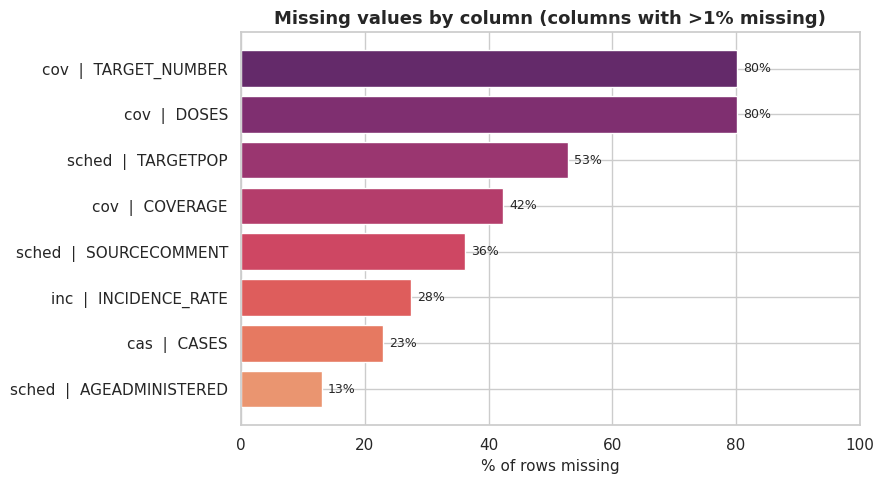

In [8]:
# Visualizing the missing values
m = missing_df[missing_df.missing_pct > 1].sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(m.table + "  |  " + m.column, m.missing_pct, color=sns.color_palette("flare", len(m)))
for b, v in zip(bars, m.missing_pct):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.0f}%", va="center", fontsize=9)
ax.set(xlim=(0, 100), xlabel="% of rows missing", title="Missing values by column (columns with >1% missing)")
plt.tight_layout(); plt.show()
miss_target = missing_df.query("table=='cov' and column=='TARGET_NUMBER'").missing_pct.iloc[0]
miss_cov = missing_df.query("table=='cov' and column=='COVERAGE'").missing_pct.iloc[0]
miss_cases = missing_df.query("table=='cas' and column=='CASES'").missing_pct.iloc[0]
miss_inc = missing_df.query("table=='inc' and column=='INCIDENCE_RATE'").missing_pct.iloc[0]

### What did you know about your dataset?

- **Five tables, 716,049 rows in total.** Coverage is by far the largest (399,859 rows); it mixes *countries* with aggregate rows (WHO regions, World-Bank income groups, UNICEF regions, Gavi status, development status and a global total) - these must be separated before any country-level statistics are computed.
- **Every workbook ends with a metadata row** ("Created: 2025-02-01 ...") stored inside the data columns - a hidden trap that turns numeric columns into text and adds a fake record.
- **Missingness is high in coverage:** `TARGET_NUMBER` is missing in 80% of rows and `COVERAGE` in 42%. This is structural: the WUENIC estimates (the most complete series) contain coverage only, while administrative/official rows contain doses and targets.
- **Surveillance data are incomplete:** 23% of `CASES` and 28% of `INCIDENCE_RATE` values are missing - in surveillance a missing report is *unknown*, not zero.
- **Units differ:** incidence is expressed per 1,000,000 population, per 1,000,000 children under 15, per 10,000 live births or per 1,000 live births depending on the disease (one denominator is even spelled two ways).
- **Impossible values:** coverage above 100% exists (up to 32,000%) because of denominator or reporting problems.
- **No full-row duplicates** were found; the natural keys (country, year, antigen/disease, category) are unique.
- The **introduction** table records a status for every country-year since 1940, while the **schedule** table only covers 2019-2023.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
for k, d in raw.items():
    print(f"{k.upper():6s}", list(d.columns))

COV    ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
INC    ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
CAS    ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
INTRO  ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
SCHED  ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [10]:
# Dataset Describe
pd.concat({k: d.describe().T.round(2) for k, d in raw.items()})

count          mean           std          min       25%        50%        75%           max
cov   YEAR            399858.0  2.009210e+03  1.172000e+01       1980.0   2002.00    2012.00     2019.0  2.023000e+03
      TARGET_NUMBER    79030.0  2.780192e+08  5.415244e+10          0.0  32814.00  317871.50  2493048.0  1.170000e+13
      DOSES            79327.0  3.467241e+06  1.125676e+07 -222288203.0  14469.00  152212.00   971018.5  1.266052e+08
      COVERAGE        230477.0  7.803000e+01  7.489000e+01          0.0     69.32      88.79       96.0  3.200000e+04
inc   YEAR             84945.0  2.004100e+03  1.260000e+01       1980.0   1994.00    2005.00     2015.0  2.023000e+03
      INCIDENCE_RATE   61584.0  1.094500e+02  9.922800e+02          0.0      0.00       0.00        4.6  6.910130e+04
cas   YEAR             84869.0  2.004110e+03  1.259000e+01       1980.0   1994.00    2005.00     2015.0  2.023000e+03
      CASES            65470.0  4.472410e+03  6.114455e+04          0.0      0.00       1.00       63.0  4.583555e+06
intro YEAR            138320.0  2.001270e+03  1.768000e+01       1940.0   1992.00    2006.00     2015.0  2.023000e+03
sched YEAR              8052.0  2.022940e+03  4.400000e-01       2019.0   2023.00    2023.00     2023.0  2.023000e+03
      SCHEDULEROUNDS    8052.0  2.050000e+00  1.320000e+00          1.0      1.00       2.00        3.0  7.000000e+00

### Variables Description

| Table | Variable | Meaning |
|---|---|---|
| **coverage** | GROUP | Type of entity: `COUNTRIES`, `WHO_REGIONS`, `WB_LONG` / `WB_SHORT` (World-Bank income groups), `UNICEF_REGIONS`, `GAVI_PHASE5`, `DEVELOPMENT_STATUS`, `GLOBAL` |
| | CODE / NAME | ISO-3 country code (or group code) and name |
| | YEAR | Year of the record (1980-2023) |
| | ANTIGEN / ANTIGEN_DESCRIPTION | Vaccine & dose code (e.g. `DTPCV3` = DTP-containing vaccine, 3rd dose) and its description |
| | COVERAGE_CATEGORY | Source of the figure: `WUENIC` (WHO/UNICEF best estimate), `OFFICIAL` (government-reported), `ADMIN` (administrative, from doses/target), `HPV`, `PAB` (protection at birth against tetanus) |
| | TARGET_NUMBER | People targeted for vaccination |
| | DOSES | Doses administered (called "Dodge" in the project brief - a typo) |
| | COVERAGE | Percentage of the target population vaccinated |
| **incidence** | DISEASE / DISEASE_DESCRIPTION | Disease code and name (13 diseases) |
| | DENOMINATOR | Population base of the rate (per 1,000,000 population, per 10,000 live births, ...) |
| | INCIDENCE_RATE | New cases per denominator |
| **cases** | CASES | Number of reported (confirmed) cases |
| **introduction** | ISO_3_CODE, COUNTRYNAME, WHO_REGION, YEAR | Country identity and WHO region |
| | DESCRIPTION | Vaccine (21 types) |
| | INTRO | Introduction status: `Yes`, `No`, `ND` (no data), `Yes (R/P/A/O/D)` (partial/limited introduction) and `High risk area` |
| **schedule** | VACCINECODE / VACCINE_DESCRIPTION | Vaccine product in the national schedule |
| | SCHEDULEROUNDS | Dose number in the schedule (1 to 7) |
| | TARGETPOP / TARGETPOP_DESCRIPTION | Who receives it: routine, risk groups, adults, pregnant women, health workers, travellers ... |
| | GEOAREA, AGEADMINISTERED, SOURCECOMMENT | National/subnational, age at administration (e.g. `M2` = 2 months, `W6` = 6 weeks, `Y6` = 6 years, `B` = birth, `+M1` = one month after the previous dose) and free-text comments |

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
uniq = pd.concat({k: d.nunique().rename("unique_values") for k, d in raw.items()}).reset_index()
uniq.columns = ["table", "variable", "unique_values"]
uniq.pivot(index="variable", columns="table", values="unique_values").fillna("").astype(str).replace("nan", "")

table,cas,cov,inc,intro,sched
variable,,,,,
AGEADMINISTERED,,,,,425.0
ANTIGEN,,69.0,,,
ANTIGEN_DESCRIPTION,,69.0,,,
CASES,6634.0,,,,
CODE,221.0,245.0,221.0,,
COUNTRYNAME,,,,194.0,213.0
COVERAGE,,7602.0,,,
COVERAGE_CATEGORY,,5.0,,,
COVERAGE_CATEGORY_DESCRIPTION,,5.0,,,


## 3. ***Data Wrangling***

The wrangling follows the four requirements of the project brief: **handle missing data**, **normalise units**, **make dates consistent**, and **build a normalised relational model** with keys that Power BI and SQL can use.

### Data Wrangling Code

**Step 1 - Structural clean-up (all five tables):** remove the metadata footer row, convert `YEAR` to integer, trim whitespace.

In [12]:
# Step 1 - structural clean-up
cleaning_log = []                       # every cleaning decision is logged so it can be audited


def log(table, step, n):
    cleaning_log.append({"table": table, "step": step, "rows_affected": int(n)})


def drop_footer(df, first_col, name):
    """Each WHO export ends with a 'Created: <timestamp>' row stored inside the data columns."""
    mask = df[first_col].astype(str).str.startswith("Created:")
    log(name, "Removed metadata footer row", mask.sum())
    return df[~mask].copy()


cov = drop_footer(raw["cov"], "GROUP", "coverage")
inc = drop_footer(raw["inc"], "GROUP", "incidence")
cas = drop_footer(raw["cas"], "GROUP", "cases")
intro = drop_footer(raw["intro"], "ISO_3_CODE", "introduction")
sched = drop_footer(raw["sched"], "ISO_3_CODE", "schedule")

for d in (cov, inc, cas, intro, sched):
    d["YEAR"] = pd.to_numeric(d["YEAR"], errors="coerce").astype("Int64")               # date consistency: integer years everywhere
    for col in d.select_dtypes(include=["object", "string"]).columns:
        d[col] = d[col].astype("string").str.strip()                                    # trim stray whitespace
print("Structural clean-up done:", {k: len(v) for k, v in dict(coverage=cov, incidence=inc, cases=cas, introduction=intro, schedule=sched).items()})

Structural clean-up done: {'coverage': 399858, 'incidence': 84945, 'cases': 84869, 'introduction': 138320, 'schedule': 8052}


**Step 2 - Dimension tables** (country, year, disease, antigen, coverage category, group, vaccine, status, target population).

In [13]:
# Step 2a - dim_country (WHO region comes from the introduction/schedule tables) and dim_year
reg = pd.concat([intro[["ISO_3_CODE", "WHO_REGION"]], sched[["ISO_3_CODE", "WHO_REGION"]]]).drop_duplicates()
reg.columns = ["country_code", "who_region"]
REGION_NAMES = {"AFRO": "Africa", "AMRO": "Americas", "EMRO": "Eastern Mediterranean", "EURO": "Europe", "SEARO": "South-East Asia", "WPRO": "Western Pacific"}

names = pd.concat([
    cov.loc[cov.GROUP == "COUNTRIES", ["CODE", "NAME"]].set_axis(["country_code", "country_name"], axis=1),
    inc.loc[inc.GROUP == "COUNTRIES", ["CODE", "NAME"]].set_axis(["country_code", "country_name"], axis=1),
    intro[["ISO_3_CODE", "COUNTRYNAME"]].set_axis(["country_code", "country_name"], axis=1)]).dropna().drop_duplicates("country_code")
dim_country = names.merge(reg, on="country_code", how="left")
n_missing_region = int(dim_country.who_region.isna().sum())
dim_country.loc[dim_country.country_code == "ASM", "who_region"] = "WPRO"       # American Samoa is only present in coverage/incidence; WHO Western Pacific
log("dim_country", "Filled missing WHO region (ASM -> WPRO)", n_missing_region)
dim_country["who_region_name"] = dim_country.who_region.map(REGION_NAMES)
dim_country = dim_country.sort_values("country_code").reset_index(drop=True)

LATEST_YEAR = int(cov.YEAR.max())
dim_year = pd.DataFrame({"year": range(int(intro.YEAR.min()), LATEST_YEAR + 1)})
dim_year["decade"] = (dim_year.year // 10 * 10).astype(str) + "s"
dim_year["is_covid_period"] = dim_year.year.isin([2020, 2021]).astype(int)
dim_country.who_region.value_counts()

who_region
EURO     54
AFRO     47
AMRO     44
WPRO     36
EMRO     22
SEARO    11
Name: count, dtype: Int64

In [14]:
# Step 2b - dim_disease : unify denominators and convert every rate to "per 100,000 of its base"
inc["DENOMINATOR"] = inc.DENOMINATOR.str.replace("per 1000 live births", "per 1,000 live births", regex=False)   # same unit, two spellings
log("incidence", "Unified NTETANUS denominator spelling", (raw["inc"].DENOMINATOR == "per 1000 live births").sum())

dim_disease = (inc.dropna(subset=["DISEASE"]).groupby("DISEASE")
               .agg(disease_name=("DISEASE_DESCRIPTION", "first"), incidence_denominator=("DENOMINATOR", "first")).reset_index()
               .rename(columns={"DISEASE": "disease_code"}))
BASE = {"per 1,000,000 total population": (1e6, "Total population"), "per 1,000,000 <15 population": (1e6, "Population under 15"),
        "per 10,000 live births": (1e4, "Live births"), "per 1,000 live births": (1e3, "Live births")}
dim_disease["denominator_base"] = dim_disease.incidence_denominator.map(lambda x: BASE[x][1])
dim_disease["to_per_100k_factor"] = dim_disease.incidence_denominator.map(lambda x: 1e5 / BASE[x][0])
dim_disease["disease_group"] = dim_disease.disease_code.map({
    "MEASLES": "Measles-Rubella-Mumps", "RUBELLA": "Measles-Rubella-Mumps", "MUMPS": "Measles-Rubella-Mumps", "CRS": "Measles-Rubella-Mumps",
    "DIPHTHERIA": "Diphtheria-Tetanus-Pertussis", "PERTUSSIS": "Diphtheria-Tetanus-Pertussis", "TTETANUS": "Diphtheria-Tetanus-Pertussis",
    "NTETANUS": "Diphtheria-Tetanus-Pertussis", "POLIO": "Polio", "YFEVER": "Vector-borne", "JAPENC": "Vector-borne",
    "INVASIVE_MENING": "Meningitis", "TYPHOID": "Enteric"})
dim_disease[["disease_code", "disease_name", "incidence_denominator", "denominator_base", "to_per_100k_factor", "disease_group"]]

,disease_code,disease_name,incidence_denominator,denominator_base,to_per_100k_factor,disease_group
0,CRS,Congenital rubella syndrome,"per 10,000 live births",Live births,10.0,Measles-Rubella-Mumps
1,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",Total population,0.1,Diphtheria-Tetanus-Pertussis
2,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",Total population,0.1,Meningitis
3,JAPENC,Japanese encephalitis,"per 1,000,000 total population",Total population,0.1,Vector-borne
4,MEASLES,Measles,"per 1,000,000 total population",Total population,0.1,Measles-Rubella-Mumps
5,MUMPS,Mumps,"per 1,000,000 total population",Total population,0.1,Measles-Rubella-Mumps
6,NTETANUS,Neonatal tetanus,"per 1,000 live births",Live births,100.0,Diphtheria-Tetanus-Pertussis
7,PERTUSSIS,Pertussis,"per 1,000,000 total population",Total population,0.1,Diphtheria-Tetanus-Pertussis
8,POLIO,Poliomyelitis,"per 1,000,000 <15 population",Population under 15,0.1,Polio
9,RUBELLA,Rubella,"per 1,000,000 total population",Total population,0.1,Measles-Rubella-Mumps


In [15]:
# Step 2c - dim_antigen (+ antigen -> disease bridge), dim_coverage_category
dim_antigen = (cov.dropna(subset=["ANTIGEN"]).groupby("ANTIGEN").ANTIGEN_DESCRIPTION.first().reset_index()
               .set_axis(["antigen_code", "antigen_description"], axis=1))


def antigen_family(a):
    """Group the 69 antigen codes into readable vaccine families."""
    if "HPV" in a: return "HPV"
    rules = [("FLU", "Influenza"), ("MCV", "Measles"), ("RCV", "Rubella"), ("DTP", "DTP"), ("DIPH", "DTP"), ("PER", "DTP"),
             ("TT", "Tetanus"), ("PAB", "Tetanus"), ("POL", "Polio"), ("IPV", "Polio"), ("HEPB", "Hepatitis B"), ("HIB", "Hib"),
             ("PCV", "Pneumococcal"), ("ROTA", "Rotavirus"), ("BCG", "BCG (TB)"), ("JAPENC", "Japanese encephalitis"),
             ("MEN", "Meningococcal"), ("YFV", "Yellow fever"), ("MALARIA", "Malaria"), ("TYPHOID", "Typhoid"), ("VAD", "Vitamin A")]
    return next((fam for p, fam in rules if a.startswith(p)), "Other")


dim_antigen["antigen_family"] = dim_antigen.antigen_code.map(antigen_family)
dim_antigen["is_booster_or_later_dose"] = dim_antigen.antigen_code.isin(
    ["DIPHCV4", "DIPHCV5", "DIPHCV6", "TTCV4", "TTCV5", "TTCV6", "PERCV4", "MCV2", "MCV2X2", "MALARIA4"]).astype(int)

# Which vaccine protects against which disease (used to join coverage with incidence). One antigen can protect against several diseases.
bridge_antigen_disease = pd.DataFrame([
    ("MCV1", "MEASLES"), ("MCV2", "MEASLES"), ("MCV2X2", "MEASLES"), ("RCV1", "RUBELLA"), ("RCV1", "CRS"),
    ("DTPCV1", "DIPHTHERIA"), ("DTPCV3", "DIPHTHERIA"), ("DTPCV1", "PERTUSSIS"), ("DTPCV3", "PERTUSSIS"), ("DTPCV3", "TTETANUS"),
    ("DIPHCV4", "DIPHTHERIA"), ("PERCV4", "PERTUSSIS"), ("TTCV4", "TTETANUS"), ("PAB", "NTETANUS"), ("TT2PLUS", "NTETANUS"),
    ("POL3", "POLIO"), ("IPV1", "POLIO"), ("IPV2", "POLIO"), ("YFV", "YFEVER"), ("JAPENC", "JAPENC"), ("JAPENC_1", "JAPENC"),
    ("JAPENC_C", "JAPENC"), ("MENA_C", "INVASIVE_MENING"), ("MENACYW_C", "INVASIVE_MENING"), ("MEN_A_CONJ", "INVASIVE_MENING"),
    ("MEN_ACYW_CONJ", "INVASIVE_MENING"), ("MEN_B", "INVASIVE_MENING"), ("MENB_C", "INVASIVE_MENING"),
    ("TYPHOID", "TYPHOID"), ("TYPHOID_CONJ", "TYPHOID")], columns=["antigen_code", "disease_code"])

dim_coverage_category = (cov.dropna(subset=["COVERAGE_CATEGORY"]).groupby("COVERAGE_CATEGORY").COVERAGE_CATEGORY_DESCRIPTION.first().reset_index()
                         .set_axis(["category_code", "category_description"], axis=1))
# WUENIC is the WHO/UNICEF best estimate (complete + adjusted) -> preferred; then government-official; then administrative
dim_coverage_category["priority_rank"] = dim_coverage_category.category_code.map({"WUENIC": 1, "OFFICIAL": 2, "ADMIN": 3, "HPV": 4, "PAB": 5})
dim_antigen.antigen_family.value_counts().to_frame("antigen codes").T

antigen_family,Influenza,HPV,DTP,Meningococcal,Polio,Tetanus,Hepatitis B,Japanese encephalitis,Malaria,Measles,Pneumococcal,Rotavirus,Typhoid,BCG (TB),Hib,Rubella,Vitamin A,Yellow fever
antigen codes,12,10,7,6,5,5,3,3,3,3,3,2,2,1,1,1,1,1


In [16]:
# Step 2d - vaccine introduction / schedule dimensions
# link each introduction vaccine to the coverage antigen and disease it corresponds to (None when there is no counterpart)
INTRO_LINKS = {
    "Measles-containing vaccine 2nd dose": ("MCV2", "MEASLES"), "Rubella vaccine": ("RCV1", "RUBELLA"), "Mumps vaccine": (None, "MUMPS"),
    "IPV (Inactivated polio vaccine)": ("IPV1", "POLIO"), "IPV (Inactivated polio vaccine) 2nd dose": ("IPV2", "POLIO"),
    "YF (Yellow fever) vaccine": ("YFV", "YFEVER"), "Japanese Encephalitis": ("JAPENC", "JAPENC"), "Hepatitis B vaccine": ("HEPB3", None),
    "HepB birth dose": ("HEPB_BD", None), "Hib (Haemophilus influenzae type B) vaccine": ("HIB3", None),
    "PCV (Pneumococcal conjugate vaccine)": ("PCV3", None), "Rotavirus vaccine": ("ROTAC", None),
    "HPV (Human Papilloma Virus) vaccine": ("HPV_FEM", None), "Meningococcal meningitis vaccines (all strains)": ("MENA_C", "INVASIVE_MENING"),
    "Typhoid": ("TYPHOID", "TYPHOID"), "aP (acellular pertussis) vaccine": (None, "PERTUSSIS"), "Malaria vaccine": ("MALARIA1", None),
    "Seasonal Influenza vaccine": ("FLU_ALL", None)}
_iv = intro.dropna(subset=["DESCRIPTION"]).DESCRIPTION.drop_duplicates().sort_values().reset_index(drop=True)
dim_intro_vaccine = pd.DataFrame({"intro_vaccine_id": range(1, len(_iv) + 1), "vaccine_description": _iv})
dim_intro_vaccine["linked_antigen_code"] = dim_intro_vaccine.vaccine_description.map(lambda x: INTRO_LINKS.get(x, (None, None))[0])
dim_intro_vaccine["linked_disease_code"] = dim_intro_vaccine.vaccine_description.map(lambda x: INTRO_LINKS.get(x, (None, None))[1])

# introduction status: raw code -> readable label + flags
STATUS = {"Yes": ("Introduced - nationwide", 1, 1), "No": ("Not introduced", 0, 0), "ND": ("No data", 0, 0),
          "Yes (R)": ("Introduced - partial (R)", 1, 0), "Yes (P)": ("Introduced - partial (P)", 1, 0), "Yes (A)": ("Introduced - partial (A)", 1, 0),
          "Yes (O)": ("Introduced - partial (O)", 1, 0), "Yes (D)": ("Introduced - partial (D)", 1, 0), "High risk area": ("Introduced - high-risk areas only", 1, 0)}
dim_intro_status = pd.DataFrame([(k, *v) for k, v in STATUS.items()], columns=["status_code", "status_label", "is_introduced", "is_nationwide"])


def schedule_family(c):
    """Group the 86 schedule vaccine codes into vaccine families."""
    rules = [("DT", "DTP-containing"), ("TD", "DTP-containing"), ("DIP", "DTP-containing"), ("D_S", "DTP-containing"), ("AP", "DTP-containing"),
             ("TT", "Tetanus"), ("HEPA", "Hepatitis A"), ("HEPB", "Hepatitis B"), ("HPV", "HPV"), ("HIB", "Hib"), ("INFLUENZA", "Influenza"),
             ("IPV", "Polio"), ("OPV", "Polio"), ("JE_", "Japanese encephalitis"), ("MEN", "Meningococcal"), ("MMR", "Measles-Mumps-Rubella"),
             ("MR", "Measles-Mumps-Rubella"), ("MM", "Measles-Mumps-Rubella"), ("MEASLES", "Measles-Mumps-Rubella"), ("MUMPS", "Measles-Mumps-Rubella"),
             ("RUBELLA", "Measles-Mumps-Rubella"), ("PCV", "Pneumococcal"), ("PPV", "Pneumococcal"), ("ROTA", "Rotavirus"), ("BCG", "BCG (TB)"),
             ("YF", "Yellow fever"), ("TYPHOID", "Typhoid"), ("VARICELLA", "Varicella"), ("RABIES", "Rabies"), ("VITAMINA", "Vitamin A"),
             ("TBE", "Tick-borne encephalitis"), ("CHOLERA", "Cholera"), ("MPOX", "Mpox"), ("RTS_S", "Malaria"), ("ZOSTER", "Zoster")]
    return next((fam for p, fam in rules if c.startswith(p)), "Other")


dim_schedule_vaccine = (sched.dropna(subset=["VACCINECODE"]).groupby("VACCINECODE").VACCINE_DESCRIPTION.first().reset_index()
                        .set_axis(["vaccine_code", "vaccine_description"], axis=1))
dim_schedule_vaccine["vaccine_family"] = dim_schedule_vaccine.vaccine_code.map(schedule_family)

# TARGETPOP is blank for routine (general population) entries -> give it an explicit code so it can be a foreign key
dim_target_pop = (sched.groupby(sched.TARGETPOP.fillna("ROUTINE")).TARGETPOP_DESCRIPTION.first().reset_index()
                  .set_axis(["target_pop_code", "target_pop_description"], axis=1))
print(len(dim_intro_vaccine), "intro vaccines |", len(dim_schedule_vaccine), "schedule vaccines |", len(dim_target_pop), "target populations")

21 intro vaccines | 86 schedule vaccines | 16 target populations


**Step 3 - Fact tables.** Coverage: recompute where possible, flag and cap impossible values, drop rows with no information. Disease burden: merge incidence and cases (same grain), convert incidence to a common scale, keep unreported values as NULL. Introduction and schedule: standardise codes and parse ages.

In [17]:
# Step 3a - fact_coverage (+ fact_coverage_group for regions / income groups / global)
c = cov.dropna(subset=["ANTIGEN"]).copy()
c.columns = [x.lower() for x in c.columns]
c = c.rename(columns={"group": "group_type", "code": "entity_code", "name": "entity_name", "antigen": "antigen_code",
                      "coverage_category": "category_code", "coverage": "coverage_raw"})

# (i) rows with no coverage, no doses and no target carry no information -> drop (keeping them would only add empty rows to Power BI)
empty = c.coverage_raw.isna() & c.doses.isna() & c.target_number.isna()
log("coverage", "Dropped rows with no coverage, doses or target", empty.sum())
n_cov_dropped = int(empty.sum())
c = c[~empty].copy()

# (ii) coverage missing but doses and target present -> recompute  coverage = doses / target * 100  (safe, exact arithmetic)
recompute = c.coverage_raw.isna() & c.doses.notna() & (c.target_number > 0)
c["coverage_raw"] = c.coverage_raw.where(~recompute, c.doses / c.target_number * 100)
c["coverage_was_recomputed"] = recompute.astype(int)
log("coverage", "Recomputed missing coverage from doses / target", recompute.sum())

# (iii) coverage above 100% is impossible for a share of a population (over-reporting / wrong denominator; raw maximum = 32,000%)
#       keep the original (coverage_raw), flag it, and cap the analysis column (coverage_pct) at 100
c["coverage_gt100_flag"] = (c.coverage_raw > 100).astype(int)
c["coverage_pct"] = c.coverage_raw.clip(lower=0, upper=100)
log("coverage", "Coverage above 100% flagged and capped at 100", c.coverage_gt100_flag.sum())
log("coverage", "Rows kept with doses/target but no coverage (coverage stays NULL)", c.coverage_pct.isna().sum())

c["year"] = c.year.astype(int)
c = c.drop(columns=["antigen_description", "coverage_category_description"]).drop_duplicates(["group_type", "entity_code", "year", "antigen_code", "category_code"])
fact_coverage = c[c.group_type == "COUNTRIES"].drop(columns=["group_type", "entity_name"]).rename(columns={"entity_code": "country_code"}).reset_index(drop=True)
fact_coverage_group = c[c.group_type != "COUNTRIES"].rename(columns={"entity_code": "group_code", "entity_name": "group_name"}).reset_index(drop=True)
fact_coverage_group["group_name"] = fact_coverage_group.group_name.fillna("Not classified")
print("fact_coverage:", fact_coverage.shape, "| fact_coverage_group:", fact_coverage_group.shape)

fact_coverage: (215380, 10) | fact_coverage_group: (18817, 12)


In [18]:
# Step 3b - fact_disease_burden (incidence + cases share the same grain: entity x year x disease)
i2 = inc.dropna(subset=["DISEASE"]).rename(columns={"GROUP": "group_type", "CODE": "entity_code", "NAME": "entity_name", "YEAR": "year",
                                                    "DISEASE": "disease_code", "INCIDENCE_RATE": "incidence_reported"})
k2 = cas.dropna(subset=["DISEASE"]).rename(columns={"GROUP": "group_type", "CODE": "entity_code", "YEAR": "year", "DISEASE": "disease_code", "CASES": "cases"})
burden_all = i2[["group_type", "entity_code", "entity_name", "year", "disease_code", "incidence_reported"]].merge(
    k2[["group_type", "entity_code", "year", "disease_code", "cases"]], on=["group_type", "entity_code", "year", "disease_code"], how="outer", validate="1:1")
log("incidence+cases", "Merged incidence and cases tables (1:1 on entity-year-disease)", len(burden_all))

# unit normalisation: everything on one scale, "per 100,000 of the disease's base population"
burden_all = burden_all.merge(dim_disease[["disease_code", "to_per_100k_factor"]], on="disease_code", how="left")
burden_all["incidence_per_100k"] = (burden_all.incidence_reported * burden_all.to_per_100k_factor).round(6)   # round away float noise (2.3800000000000003)
burden_all = burden_all.drop(columns="to_per_100k_factor")

# missing != zero: unreported values stay NULL; rows with neither cases nor incidence carry no information
empty_b = burden_all.cases.isna() & burden_all.incidence_reported.isna()
log("incidence+cases", "Dropped rows with neither cases nor incidence", empty_b.sum())
burden_all = burden_all[~empty_b].copy()
burden_all["year"] = burden_all.year.astype(int)

fact_disease_burden = (burden_all[burden_all.group_type == "COUNTRIES"].drop(columns=["group_type", "entity_name"])
                       .rename(columns={"entity_code": "country_code"}).reset_index(drop=True))
fact_disease_burden_group = (burden_all[burden_all.group_type != "COUNTRIES"]
                             .rename(columns={"entity_code": "group_code", "entity_name": "group_name"}).reset_index(drop=True))
print("fact_disease_burden:", fact_disease_burden.shape, "| fact_disease_burden_group:", fact_disease_burden_group.shape)

fact_disease_burden: (62655, 6) | fact_disease_burden_group: (2815, 8)


In [19]:
# Step 3c - fact_vaccine_intro and fact_vaccine_schedule
v = intro.dropna(subset=["DESCRIPTION"]).merge(dim_intro_vaccine[["intro_vaccine_id", "vaccine_description"]], left_on="DESCRIPTION", right_on="vaccine_description")
v["INTRO"] = v.INTRO.fillna("ND")
fact_vaccine_intro = (v.rename(columns={"ISO_3_CODE": "country_code", "YEAR": "year", "INTRO": "status_code"})
                      [["country_code", "year", "intro_vaccine_id", "status_code"]].astype({"year": int}))

s = sched.dropna(subset=["VACCINECODE"]).copy()
log("schedule", "Blank TARGETPOP set to ROUTINE (general/routine)", s.TARGETPOP.isna().sum())
s["TARGETPOP"] = s.TARGETPOP.fillna("ROUTINE")
s["AGEADMINISTERED"] = s.AGEADMINISTERED.fillna("Unknown")
s["GEOAREA"] = s.GEOAREA.fillna("NATIONAL")


def parse_age(a):
    """Convert schedule ages into months. Returns (months, kind); kind = absolute | interval (after previous dose) | contact | other | unknown."""
    if a == "Unknown": return (np.nan, "unknown")
    if a == "B": return (0.0, "absolute")
    if a.lower().startswith("1st contact"): return (np.nan, "contact")
    m = re.fullmatch(r"(\+|>|<)?([WMY])(\d+)", a)
    if not m: return (np.nan, "other")
    pre, unit, val = m.group(1), m.group(2), float(m.group(3))
    return (val * {"W": 7 / 30.4375, "M": 1, "Y": 12}[unit], "interval" if pre == "+" else "absolute")


_p = s.AGEADMINISTERED.map(parse_age)
s["age_months"] = _p.map(lambda t: t[0]); s["age_kind"] = _p.map(lambda t: t[1])
s = s.reset_index(drop=True); s.insert(0, "schedule_id", np.arange(1, len(s) + 1))
fact_vaccine_schedule = (s.rename(columns={"ISO_3_CODE": "country_code", "YEAR": "year", "VACCINECODE": "vaccine_code", "SCHEDULEROUNDS": "schedule_round",
                                           "TARGETPOP": "target_pop_code", "GEOAREA": "geo_area", "AGEADMINISTERED": "age_administered", "SOURCECOMMENT": "source_comment"})
                         [["schedule_id", "country_code", "year", "vaccine_code", "schedule_round", "target_pop_code", "geo_area", "age_administered", "age_months", "age_kind", "source_comment"]]
                         .astype({"year": int, "schedule_round": int}))

# dim_group : the aggregate entities (WHO regions, income groups, Gavi, global ...)
dim_group = (pd.concat([fact_coverage_group[["group_type", "group_code", "group_name"]], fact_disease_burden_group[["group_type", "group_code", "group_name"]]])
             .drop_duplicates(["group_type", "group_code"]).sort_values(["group_type", "group_code"]).reset_index(drop=True))
dim_group["group_name"] = dim_group.group_name.fillna("Not classified")
# WHO-region aggregates use short codes (AFR...) while country rows use AFRO...; keep the link so Power BI can relate them
dim_group["who_region"] = dim_group.group_code.map({"AFR": "AFRO", "AMR": "AMRO", "EMR": "EMRO", "EUR": "EURO", "SEAR": "SEARO", "WPR": "WPRO"})
print("fact_vaccine_intro:", fact_vaccine_intro.shape, "| fact_vaccine_schedule:", fact_vaccine_schedule.shape, "| dim_group:", dim_group.shape)

fact_vaccine_intro: (138320, 4) | fact_vaccine_schedule: (8052, 11) | dim_group: (31, 4)


**Step 4 - Validation:** primary keys must be unique, and every foreign key must exist in its dimension (referential integrity).

In [20]:
# Step 4 - integrity checks (primary keys unique, no orphan foreign keys)
TABLES = dict(dim_country=dim_country, dim_year=dim_year, dim_disease=dim_disease, dim_antigen=dim_antigen,
              bridge_antigen_disease=bridge_antigen_disease, dim_coverage_category=dim_coverage_category, dim_group=dim_group,
              dim_intro_vaccine=dim_intro_vaccine, dim_intro_status=dim_intro_status, dim_schedule_vaccine=dim_schedule_vaccine,
              dim_target_pop=dim_target_pop, fact_coverage=fact_coverage, fact_coverage_group=fact_coverage_group,
              fact_disease_burden=fact_disease_burden, fact_disease_burden_group=fact_disease_burden_group,
              fact_vaccine_intro=fact_vaccine_intro, fact_vaccine_schedule=fact_vaccine_schedule)

PK = {"dim_country": ["country_code"], "dim_year": ["year"], "dim_disease": ["disease_code"], "dim_antigen": ["antigen_code"],
      "bridge_antigen_disease": ["antigen_code", "disease_code"], "dim_coverage_category": ["category_code"], "dim_group": ["group_type", "group_code"],
      "dim_intro_vaccine": ["intro_vaccine_id"], "dim_intro_status": ["status_code"], "dim_schedule_vaccine": ["vaccine_code"], "dim_target_pop": ["target_pop_code"],
      "fact_coverage": ["country_code", "year", "antigen_code", "category_code"], "fact_coverage_group": ["group_type", "group_code", "year", "antigen_code", "category_code"],
      "fact_disease_burden": ["country_code", "year", "disease_code"], "fact_disease_burden_group": ["group_type", "group_code", "year", "disease_code"],
      "fact_vaccine_intro": ["country_code", "year", "intro_vaccine_id"], "fact_vaccine_schedule": ["schedule_id"]}
FK = [("fact_coverage", "country_code", "dim_country", "country_code"), ("fact_coverage", "antigen_code", "dim_antigen", "antigen_code"),
      ("fact_coverage", "category_code", "dim_coverage_category", "category_code"), ("fact_coverage", "year", "dim_year", "year"),
      ("fact_coverage_group", "antigen_code", "dim_antigen", "antigen_code"), ("fact_coverage_group", "year", "dim_year", "year"),
      ("fact_disease_burden", "country_code", "dim_country", "country_code"), ("fact_disease_burden", "disease_code", "dim_disease", "disease_code"),
      ("fact_disease_burden", "year", "dim_year", "year"), ("fact_disease_burden_group", "disease_code", "dim_disease", "disease_code"),
      ("fact_vaccine_intro", "country_code", "dim_country", "country_code"), ("fact_vaccine_intro", "intro_vaccine_id", "dim_intro_vaccine", "intro_vaccine_id"),
      ("fact_vaccine_intro", "status_code", "dim_intro_status", "status_code"), ("fact_vaccine_schedule", "country_code", "dim_country", "country_code"),
      ("fact_vaccine_schedule", "vaccine_code", "dim_schedule_vaccine", "vaccine_code"), ("fact_vaccine_schedule", "target_pop_code", "dim_target_pop", "target_pop_code"),
      ("bridge_antigen_disease", "antigen_code", "dim_antigen", "antigen_code"), ("bridge_antigen_disease", "disease_code", "dim_disease", "disease_code")]

checks = []
for t, cols in PK.items():
    checks.append((f"PK unique: {t}({', '.join(cols)})", int(TABLES[t].duplicated(cols).sum())))
for t, col, rt, rcol in FK:
    checks.append((f"FK orphans: {t}.{col} -> {rt}.{rcol}", int((~TABLES[t][col].isin(TABLES[rt][rcol])).sum())))
integrity = pd.DataFrame(checks, columns=["check", "violations"])
integrity["status"] = np.where(integrity.violations == 0, "PASS", "FAIL")
assert (integrity.violations == 0).all(), "Integrity check failed"
print(f"All {len(integrity)} integrity checks passed")
integrity.head(8)

All 35 integrity checks passed


,check,violations,status
0,PK unique: dim_country(country_code),0,PASS
1,PK unique: dim_year(year),0,PASS
2,PK unique: dim_disease(disease_code),0,PASS
3,PK unique: dim_antigen(antigen_code),0,PASS
4,PK unique: bridge_antigen_disease(antigen_code...,0,PASS
5,PK unique: dim_coverage_category(category_code),0,PASS
6,"PK unique: dim_group(group_type, group_code)",0,PASS
7,PK unique: dim_intro_vaccine(intro_vaccine_id),0,PASS


In [21]:
# Cleaning log - every decision, with the number of rows it touched
pd.DataFrame(cleaning_log)

,table,step,rows_affected
0,coverage,Removed metadata footer row,1
1,incidence,Removed metadata footer row,1
2,cases,Removed metadata footer row,1
3,introduction,Removed metadata footer row,1
4,schedule,Removed metadata footer row,1
5,dim_country,Filled missing WHO region (ASM -> WPRO),1
6,incidence,Unified NTETANUS denominator spelling,308
7,coverage,"Dropped rows with no coverage, doses or target",165661
8,coverage,Recomputed missing coverage from doses / target,292
9,coverage,Coverage above 100% flagged and capped at 100,5153


**Step 5 - Analysis-ready views** used by the charts and by Power BI: the *best available* coverage value per country-year-antigen, the coverage-vs-incidence pairs, and the first year each vaccine was introduced.

In [22]:
# Step 5 - analysis-ready views
# (a) best coverage per country-year-antigen: WUENIC > OFFICIAL > ADMIN (avoids double counting the same figure from three sources)
_rank = dim_coverage_category.set_index("category_code").priority_rank
_c = fact_coverage.dropna(subset=["coverage_pct"]).assign(rank=lambda d: d.category_code.map(_rank))
_best = _c.sort_values("rank").drop_duplicates(["country_code", "year", "antigen_code"])
_tgt = fact_coverage.groupby(["country_code", "year", "antigen_code"]).target_number.max().rename("target_any").reset_index()   # WUENIC rows have no target -> borrow it from ADMIN/OFFICIAL
cov_best = (_best.merge(_tgt, on=["country_code", "year", "antigen_code"], how="left")
            .merge(dim_country[["country_code", "country_name", "who_region"]], on="country_code")
            [["country_code", "country_name", "who_region", "year", "antigen_code", "category_code", "coverage_pct", "target_any"]]
            .rename(columns={"category_code": "source_category"}).reset_index(drop=True))

# (b) disease burden with country attributes
burden = (fact_disease_burden.merge(dim_country[["country_code", "country_name", "who_region"]], on="country_code")
          .merge(dim_disease[["disease_code", "disease_name", "denominator_base"]], on="disease_code"))

# (c) coverage <-> incidence pairs (only vaccine/disease combinations that make biological sense, via the bridge table)
pairs = (bridge_antigen_disease.merge(cov_best[["country_code", "country_name", "who_region", "year", "antigen_code", "coverage_pct"]], on="antigen_code")
         .merge(fact_disease_burden[["country_code", "year", "disease_code", "incidence_reported", "incidence_per_100k", "cases"]], on=["country_code", "year", "disease_code"]))

# (d) first year each country introduced each vaccine (any 'Yes' variant)
_intro = fact_vaccine_intro.merge(dim_intro_status, on="status_code").merge(dim_intro_vaccine, on="intro_vaccine_id")
intro_first = (_intro[_intro.is_introduced == 1].groupby(["country_code", "vaccine_description"]).year.min().rename("first_year").reset_index()
               .merge(dim_country[["country_code", "country_name", "who_region"]], on="country_code"))

# small helpers used by several charts
def latest(df, year=None):
    return df[df.year == (year or LATEST_YEAR)]

def gl(antigen):                        # global WUENIC coverage series for one antigen
    return (fact_coverage_group.query("group_type=='GLOBAL' and category_code=='WUENIC' and antigen_code==@antigen")
            .set_index("year").coverage_pct.sort_index())

def gcases(disease):                    # global reported cases series for one disease
    return (fact_disease_burden_group.query("group_type=='GLOBAL' and disease_code==@disease").set_index("year").cases.sort_index())

print({"cov_best": cov_best.shape, "burden": burden.shape, "pairs": pairs.shape, "intro_first": intro_first.shape})

{'cov_best': (94535, 8), 'burden': (62655, 10), 'pairs': (72552, 10), 'intro_first': (2331, 5)}


**Step 6 - Export** the clean star schema (CSV) for the SQL database and for Power BI.

In [23]:
# Step 6 - export cleaned tables + analysis-ready views
EXPORT = dict(TABLES)
# group names live in dim_group -> drop the repeated name column from the group fact tables (3rd normal form)
EXPORT["fact_coverage_group"] = fact_coverage_group.drop(columns="group_name")
EXPORT["fact_disease_burden_group"] = fact_disease_burden_group.drop(columns="group_name")
EXPORT["mart_coverage_best"] = cov_best
EXPORT["mart_coverage_vs_incidence"] = pairs
EXPORT["mart_first_introduction"] = intro_first
for name, df in EXPORT.items():
    df.to_csv(os.path.join(OUTPUT_DIR, f"{name}.csv"), index=False)
pd.DataFrame({"rows": {k: len(v) for k, v in EXPORT.items()}, "columns": {k: v.shape[1] for k, v in EXPORT.items()}})

,rows,columns
dim_country,214,4
dim_year,84,3
dim_disease,13,6
dim_antigen,69,4
bridge_antigen_disease,30,2
dim_coverage_category,5,3
dim_group,31,4
dim_intro_vaccine,21,4
dim_intro_status,9,4
dim_schedule_vaccine,86,3


In [24]:
# figures quoted in the wrangling summary below
_cl = pd.DataFrame(cleaning_log).set_index("step").rows_affected
n_group_rows, n_group_burden = len(fact_coverage_group), len(fact_disease_burden_group)
n_recomputed = int(_cl["Recomputed missing coverage from doses / target"])
n_gt100 = int(_cl["Coverage above 100% flagged and capped at 100"])
n_denom_fix = int(_cl["Unified NTETANUS denominator spelling"])
n_burden_rows = len(burden_all)
n_sched = len(fact_vaccine_schedule)
n_cov_best = len(cov_best)
n_checks = len(integrity)
n_wuenic = int((fact_coverage.category_code == "WUENIC").sum() - fact_coverage[fact_coverage.category_code == "WUENIC"].coverage_pct.isna().sum())
pct_gt100 = n_gt100 / fact_coverage.coverage_pct.notna().sum() * 100
cov_rows = len(raw["cov"])

### What all manipulations have you done and insights you found?

| # | Manipulation | Why | Rows affected |
|---|---|---|---|
| 1 | Removed the *Created: ...* footer row in all 5 tables | It sat inside the data columns and turned numeric columns into text | 5 |
| 2 | `YEAR` converted from decimal to integer, whitespace trimmed | Consistent join keys and clean labels in SQL / Power BI | all |
| 3 | Aggregate rows (WHO regions, income groups, Gavi, global ...) split from country rows | Otherwise averages double count countries | 18,817 coverage + 2,815 disease rows moved to `*_group` tables |
| 4 | Dropped coverage rows with no coverage, doses **and** target | Nothing to analyse; keeps the model light | 165,661 |
| 5 | Recomputed coverage = doses / target where it was missing | Exact arithmetic, no guessing | 292 |
| 6 | Coverage > 100% flagged (`coverage_gt100_flag`) and capped at 100 in `coverage_pct` | Impossible for a share; the original stays in `coverage_raw` | 5,153 |
| 7 | Two spellings of the tetanus denominator unified; **all incidence rates converted to per 100,000** of their base | Unit normalisation as required by the brief | 308 |
| 8 | Incidence and cases tables merged into one fact table | Same grain, avoids a duplicated key | 65,470 |
| 9 | Missing cases / incidence **left as NULL, not imputed** | A missing surveillance report is unknown, not zero; imputing would fabricate outbreaks or fake eradication | - |
| 10 | Blank target population -> `ROUTINE`; ages parsed to months (`M2`, `W6`, `Y6`, `B`) | Usable foreign key and a numeric age for schedule analysis | 8,052 schedule rows |
| 11 | Best coverage source per country-year-antigen (WUENIC > OFFICIAL > ADMIN) | The same figure is reported by up to three sources | 94,535 best values |
| 12 | Star schema with primary / foreign keys, 35 integrity checks | Required SQL quality and Power BI relationships | all pass |

**Insights found while wrangling**
- The **WUENIC** series is the most complete (61,438 usable values) but carries no target population; the target was therefore borrowed from administrative/official rows for the size-based analyses.
- Reported coverage > 100% affects 2.4% of usable coverage values, mostly from administrative reporting, a reminder that administrative coverage is less reliable than WUENIC estimates.
- Incidence values are published with one decimal, so very small rates (e.g. neonatal tetanus per 1,000 live births) are rounded to 0.0; whenever totals matter, the analysis uses **cases** rather than rates.
- Global totals depend on **how many countries report**: for some diseases (typhoid, invasive meningococcal disease, Japanese encephalitis, CRS, mumps) reporting only started or expanded recently, so their global trend reflects surveillance growth and not disease growth. Long-run trend analysis is therefore restricted to diseases reported by almost every country since 1980.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Charts follow the **UBM** rule: Univariate (1-5), Bivariate (6-17), Multivariate (18-24), then scenario-based analysis (25-30).

### **U - Univariate analysis**

#### Chart - 1 : Distribution of DTP3 coverage across countries

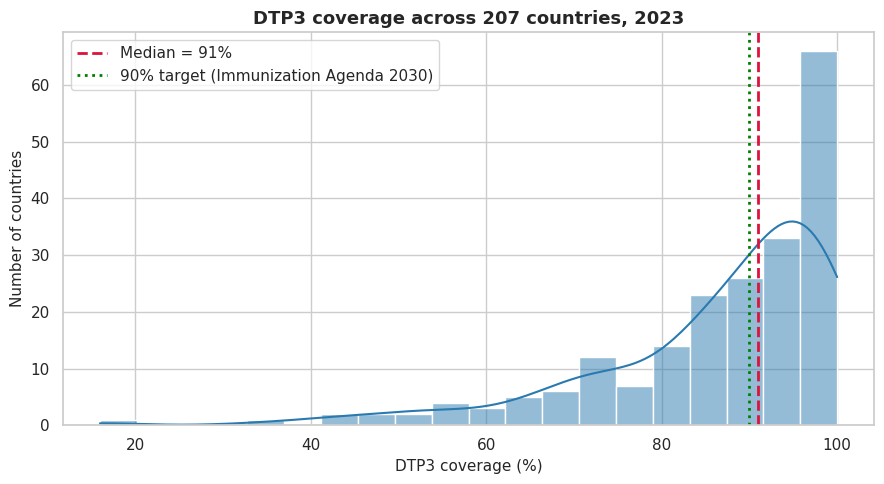

In [25]:
# Chart - 1 : Distribution of DTP3 coverage across countries
d1 = latest(cov_best).query("antigen_code == 'DTPCV3'")
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(d1.coverage_pct, bins=20, kde=True, color="#2a7ab0", ax=ax)
ax.axvline(d1.coverage_pct.median(), color="crimson", ls="--", lw=2, label=f"Median = {d1.coverage_pct.median():.0f}%")
ax.axvline(90, color="green", ls=":", lw=2, label="90% target (Immunization Agenda 2030)")
ax.set(title=f"DTP3 coverage across {len(d1)} countries, {LATEST_YEAR}", xlabel="DTP3 coverage (%)", ylabel="Number of countries")
ax.legend(); plt.tight_layout(); plt.show()
c1_n, c1_med, c1_mean, c1_skew = len(d1), d1.coverage_pct.median(), d1.coverage_pct.mean(), d1.coverage_pct.skew()
c1_below90, c1_below70 = int((d1.coverage_pct < 90).sum()), int((d1.coverage_pct < 70).sum())

##### 1. Why did you pick the specific chart?

A histogram with a density curve is the natural first look at one numeric variable: it shows the shape (skew, clusters, tail) that a single average would hide. DTP3 is the standard indicator of how well a country's routine immunization system works.

##### 2. What is/are the insight(s) found from the chart?

The distribution is strongly **left-skewed** (skewness -1.8): most countries cluster at 90-99% but a long tail reaches far below. The median is 91% while the mean is only 86%. **91 of 207 countries (44%) miss the 90% goal and 23 are below 70%.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the problem is concentrated in a tail of weak-performing countries, so resources can be targeted instead of spread thinly. **Negative:** the global average hides this tail; reporting only the average would understate the risk for the 23 countries where a third or more of infants lack full DTP protection, and outbreaks of diphtheria, pertussis and tetanus remain likely there.

#### Chart - 2 : Global reported measles cases over time

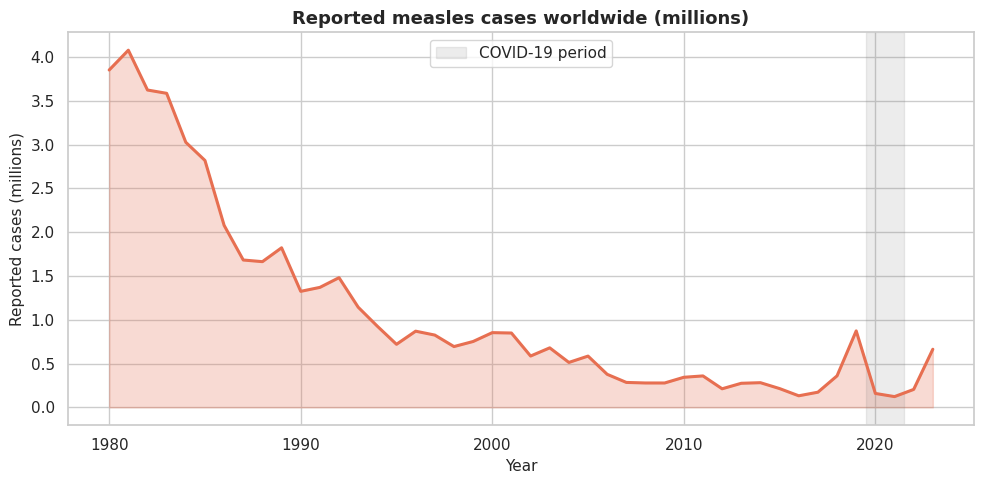

In [26]:
# Chart - 2 : Global reported measles cases over time
g2 = fact_disease_burden_group.query("group_type == 'GLOBAL' and disease_code == 'MEASLES'").sort_values("year").set_index("year")
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(g2.index, g2.cases / 1e6, color="#e76f51", alpha=.25)
ax.plot(g2.index, g2.cases / 1e6, color="#e76f51", lw=2.2)
ax.axvspan(2019.5, 2021.5, color="grey", alpha=.15, label="COVID-19 period")
ax.set(title="Reported measles cases worldwide (millions)", xlabel="Year", ylabel="Reported cases (millions)")
ax.legend(); plt.tight_layout(); plt.show()
c2_1980, c2_2019, c2_2021, c2_last = g2.cases.loc[1980], g2.cases.loc[2019], g2.cases.loc[2021], g2.cases.loc[LATEST_YEAR]

##### 1. Why did you pick the specific chart?

A line/area chart is the right choice for one quantity over time: it shows the long-term decline, the spikes and the pandemic dip in one picture.

##### 2. What is/are the insight(s) found from the chart?

Reported measles cases fell from **3.85 million in 1980 to 0.66 million in 2023**, but the fall is not steady: cases spiked to 0.87 million in 2019, collapsed to 0.12 million in 2021 (lockdowns, less testing and surveillance), then rebounded sharply. These are *reported* cases, so surveillance quality also shapes the curve.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a long-run decline of about 83% shows vaccination works. **Negative:** the 5.4-fold rebound from 2021 to 2023 shows that immunity gaps built up during the pandemic are now producing outbreaks; ignoring this would risk a return to the 2019 level.

#### Chart - 3 : Distribution of measles incidence across country-years

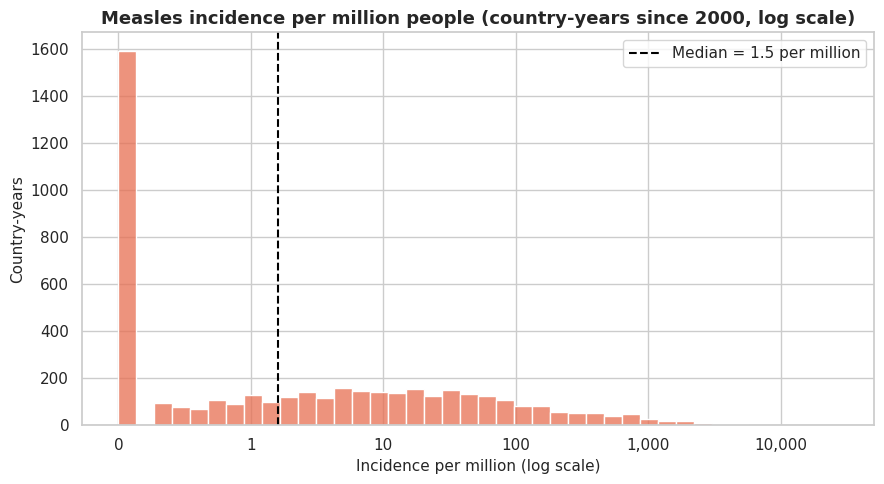

In [27]:
# Chart - 3 : Distribution of measles incidence across country-years
m3 = burden.query("disease_code == 'MEASLES' and year >= 2000").incidence_reported.dropna()
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(np.log10(m3 + 0.1), bins=40, color="#e76f51", ax=ax)
ticks = [-1, 0, 1, 2, 3, 4]
ax.set_xticks(ticks); ax.set_xticklabels(["0", "1", "10", "100", "1,000", "10,000"])
ax.axvline(np.log10(m3.median() + 0.1), color="black", ls="--", label=f"Median = {m3.median():.1f} per million")
ax.set(title="Measles incidence per million people (country-years since 2000, log scale)", xlabel="Incidence per million (log scale)", ylabel="Country-years")
ax.legend(); plt.tight_layout(); plt.show()
c3_n, c3_med, c3_mean, c3_zero, c3_gt100 = len(m3), m3.median(), m3.mean(), (m3 == 0).mean(), (m3 > 100).mean()

##### 1. Why did you pick the specific chart?

Incidence is extremely right-skewed (a few outbreaks are thousands of times larger than typical values), so a histogram on a **log scale** is needed to see the whole distribution.

##### 2. What is/are the insight(s) found from the chart?

Across 4,525 country-years since 2000, the median incidence is only 1.5 per million but the mean is 92: a small share of very large outbreaks dominates totals. 35% of country-years report zero measles and 11% exceed 100 per million.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** most country-years are near elimination, so elimination is realistic. **Negative:** because averages are driven by rare extreme outbreaks, dashboards must use medians, log scales and outbreak alerts; monitoring the mean would trigger false alarms or hide localized crises.

#### Chart - 4 : Vaccines introduced nationwide in each country

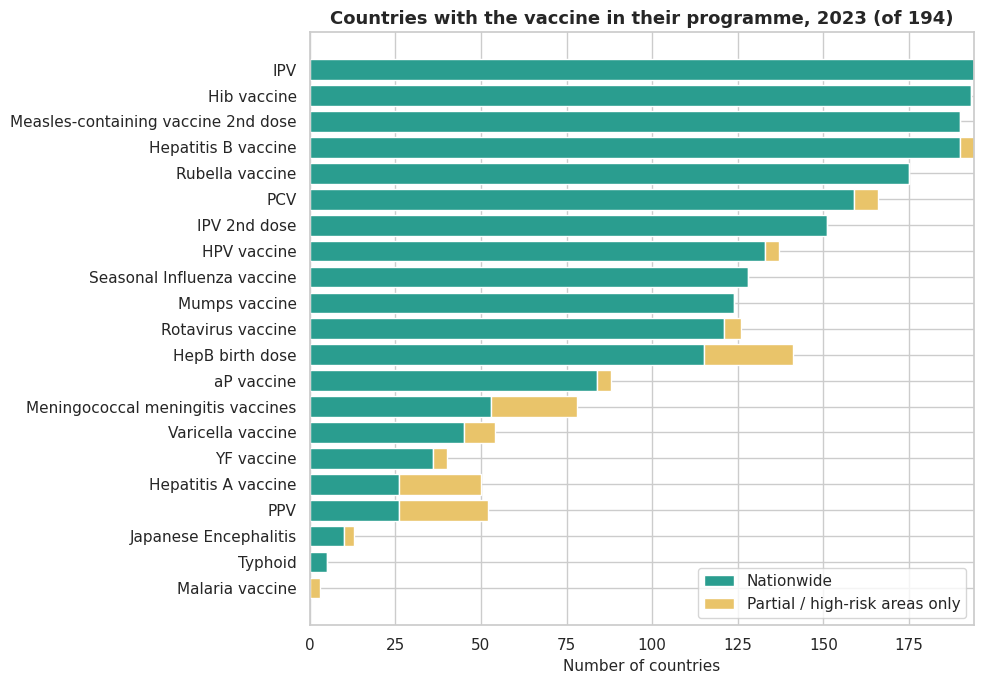

In [28]:
# Chart - 4 : Vaccines introduced nationwide in each country
i4 = _intro[_intro.year == LATEST_YEAR]
d4 = i4.groupby("vaccine_description").agg(nationwide=("is_nationwide", "sum"), any_intro=("is_introduced", "sum"))
d4["partial / limited"] = d4.any_intro - d4.nationwide
d4 = d4.sort_values("nationwide")
n_intro_countries = i4.country_code.nunique()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(d4.index.str.replace(r" \(.*?\)", "", regex=True), d4.nationwide, color="#2a9d8f", label="Nationwide")
ax.barh(d4.index.str.replace(r" \(.*?\)", "", regex=True), d4["partial / limited"], left=d4.nationwide, color="#e9c46a", label="Partial / high-risk areas only")
ax.set(title=f"Countries with the vaccine in their programme, {LATEST_YEAR} (of {n_intro_countries})", xlabel="Number of countries")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
c4_hpv, c4_rota, c4_pcv = d4.loc["HPV (Human Papilloma Virus) vaccine", "nationwide"], d4.loc["Rotavirus vaccine", "nationwide"], d4.loc["PCV (Pneumococcal conjugate vaccine)", "nationwide"]
c4_mal, c4_je, c4_hepb, c4_mcv2 = d4.loc["Malaria vaccine", "any_intro"], d4.loc["Japanese Encephalitis", "nationwide"], d4.loc["Hepatitis B vaccine", "nationwide"], d4.loc["Measles-containing vaccine 2nd dose", "nationwide"]

##### 1. Why did you pick the specific chart?

A sorted horizontal bar chart compares categories with long labels cleanly, and stacking shows how many countries have only a limited (partial or high-risk-area) introduction.

##### 2. What is/are the insight(s) found from the chart?

The oldest vaccines are almost universal (Hepatitis B in 190 of 194 countries, measles 2nd dose in 190). Newer or targeted vaccines are far from universal: **PCV in 159, rotavirus in 121, HPV in 133**, and the new malaria vaccine in only 3 (partial introductions). Japanese encephalitis is used by 10 countries because it is needed only where the disease is endemic.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the core childhood schedule is nearly universal, so future gains come from *quality of delivery*, not from adding vaccines. **Negative:** 61 countries still have no nationwide HPV programme and 73 lack rotavirus vaccine - a preventable burden of cervical cancer and child diarrhoea deaths. These are candidates for introduction support.

#### Chart - 5 : Vaccine schedule entries by target population

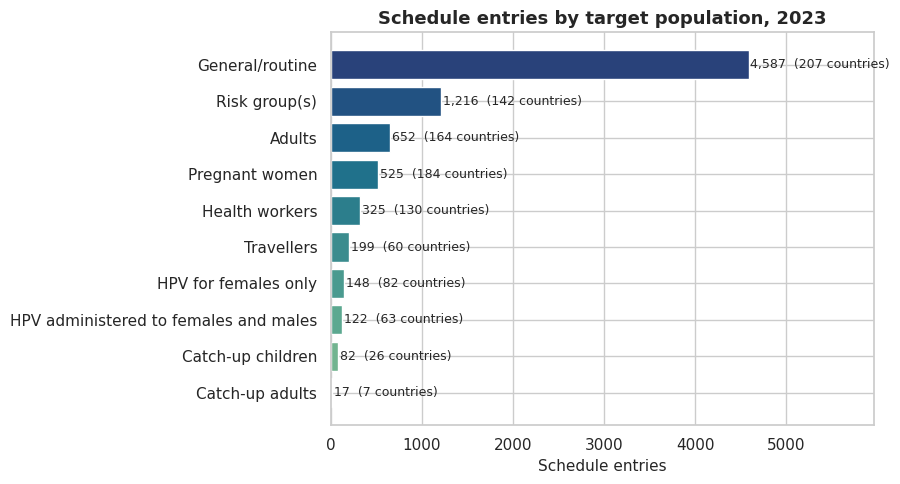

In [29]:
# Chart - 5 : Vaccine schedule entries by target population
d5 = fact_vaccine_schedule.query("year == @LATEST_YEAR").merge(dim_target_pop, on="target_pop_code")
t5 = d5.groupby("target_pop_description").agg(entries=("schedule_id", "size"), countries=("country_code", "nunique")).sort_values("entries")
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(t5.index, t5.entries, color=sns.color_palette("crest", len(t5)))
for b, (e, c_) in zip(bars, zip(t5.entries, t5.countries)):
    ax.text(e + 20, b.get_y() + b.get_height() / 2, f"{e:,}  ({c_} countries)", va="center", fontsize=9)
ax.set(title=f"Schedule entries by target population, {LATEST_YEAR}", xlabel="Schedule entries", xlim=(0, t5.entries.max() * 1.3))
plt.tight_layout(); plt.show()
c5_n = d5.country_code.nunique()
c5_routine = t5.loc["General/routine", "entries"] / t5.entries.sum()
c5_risk_c, c5_pw_c, c5_hw_c, c5_ad_c = t5.loc["Risk group(s)", "countries"], t5.loc["Pregnant women", "countries"], t5.loc["Health workers", "countries"], t5.loc["Adults", "countries"]

##### 1. Why did you pick the specific chart?

The schedule table describes *who* is meant to receive each dose. A bar chart of entries per target group shows how much of national policy is aimed at routine childhood immunization versus special populations.

##### 2. What is/are the insight(s) found from the chart?

General/routine childhood entries make up 58% of all schedule entries. Special groups are covered far less broadly (of 207 countries with schedule data): risk groups appear in 142, adults in 164, pregnant women in 184 and health workers in 130.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the routine child schedule is well defined everywhere, a solid base for coverage tracking. **Negative:** targeted entries for adults, pregnant women and health workers exist in only 164, 184 and 130 of 207 countries, which limits protection for the people most at risk in an influenza or pertussis outbreak. Agencies allocating vaccines to high-risk groups should first check whether a policy and schedule even exist.

### **B - Bivariate analysis**

#### Chart - 6 : Global coverage trends by vaccine (1980 - latest)

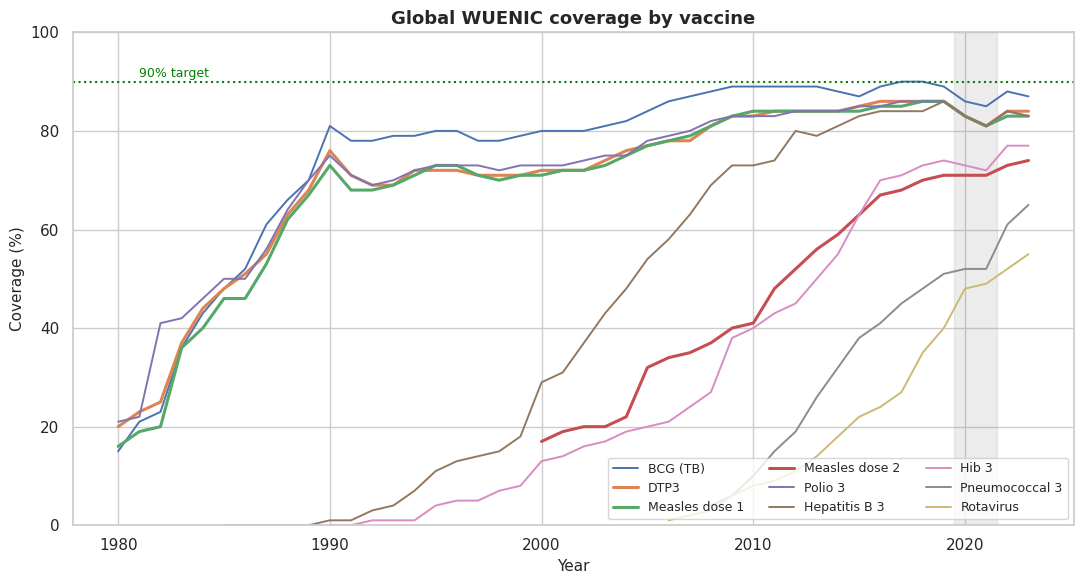

In [30]:
# Chart - 6 : Global coverage trends by vaccine (1980 - latest)
ANT6 = {"BCG": "BCG (TB)", "DTPCV3": "DTP3", "MCV1": "Measles dose 1", "MCV2": "Measles dose 2", "POL3": "Polio 3",
        "HEPB3": "Hepatitis B 3", "HIB3": "Hib 3", "PCV3": "Pneumococcal 3", "ROTAC": "Rotavirus"}
fig, ax = plt.subplots(figsize=(11, 6))
for a, lab in ANT6.items():
    s6 = gl(a).dropna()
    ax.plot(s6.index, s6.values, lw=2.2 if a in ("DTPCV3", "MCV1", "MCV2") else 1.4, label=lab)
ax.axvspan(2019.5, 2021.5, color="grey", alpha=.15)
ax.axhline(90, color="green", ls=":", lw=1.5); ax.text(1981, 91, "90% target", color="green", fontsize=9)
ax.set(title="Global WUENIC coverage by vaccine", xlabel="Year", ylabel="Coverage (%)", ylim=(0, 100))
ax.legend(ncol=3, fontsize=9, loc="lower right"); plt.tight_layout(); plt.show()
d6 = gl("DTPCV3")
pre6 = d6.loc[:2019]                                           # pre-pandemic peak
dtp3_peak, dtp3_peak_year = pre6.max(), int(pre6[pre6 == pre6.max()].index.max())
dtp3_last, dtp3_1980 = d6.loc[LATEST_YEAR], d6.loc[1980]
mcv1_last, mcv2_last, pcv3_last, rota_last = gl("MCV1").loc[LATEST_YEAR], gl("MCV2").loc[LATEST_YEAR], gl("PCV3").loc[LATEST_YEAR], gl("ROTAC").loc[LATEST_YEAR]
hib_2010, hib_last = gl("HIB3").loc[2010], gl("HIB3").loc[LATEST_YEAR]

##### 1. Why did you pick the specific chart?

A multi-line chart with one line per vaccine lets us compare the speed of roll-out, the plateau and the pandemic dip across vaccines on a common 0-100% axis.

##### 2. What is/are the insight(s) found from the chart?

Older vaccines climbed steeply from the 1980s: **DTP3 from 20% (1980) to 86% by 2019**. Every vaccine dipped in 2020-21 and DTP3 was still only **84% in 2023** - it has not returned to its pre-pandemic level. Newer vaccines are still growing (pneumococcal 65%, rotavirus 55%) but are well below the older ones; measles dose 2 (74%) and dose 1 (83%) are below the 95% target.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** newer vaccines such as Hib (40% in 2010 to 77%) and pneumococcal show that fast uptake is possible when funding and supply are in place. **Negative:** the flat, sub-target lines for DTP3 and measles mean roughly one child in six is still missing routine doses; the post-2019 stagnation signals a systemic recovery problem that needs catch-up campaigns, not business as usual.

#### Chart - 7 : Coverage by WHO region and vaccine (heatmap)

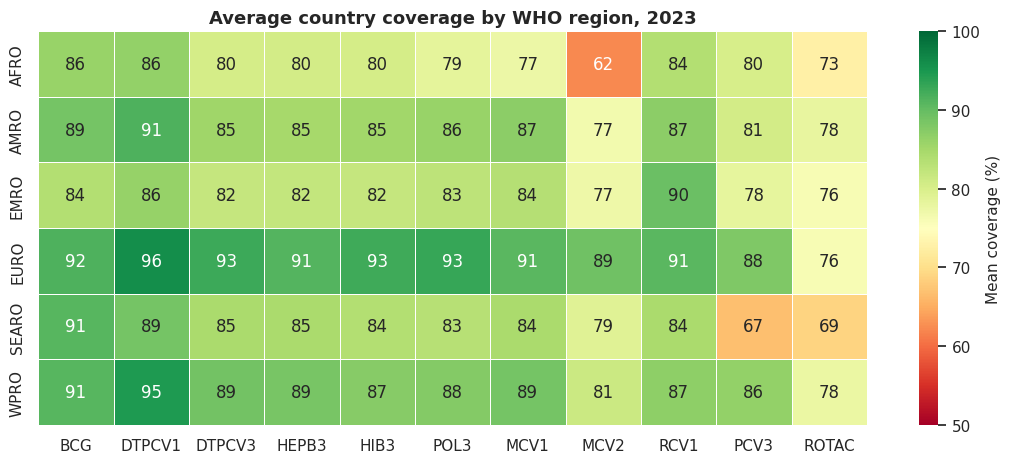

In [31]:
# Chart - 7 : Coverage by WHO region and vaccine (heatmap)
A7 = ["BCG", "DTPCV1", "DTPCV3", "HEPB3", "HIB3", "POL3", "MCV1", "MCV2", "RCV1", "PCV3", "ROTAC"]
l7 = latest(cov_best)
h7 = l7[l7.antigen_code.isin(A7)].pivot_table(index="who_region", columns="antigen_code", values="coverage_pct").reindex(REGION_ORDER)[A7]
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(h7, annot=True, fmt=".0f", cmap="RdYlGn", vmin=50, vmax=100, linewidths=.5, cbar_kws={"label": "Mean coverage (%)"}, ax=ax)
ax.set(title=f"Average country coverage by WHO region, {LATEST_YEAR}", xlabel="", ylabel="")
plt.tight_layout(); plt.show()
afro_mcv2, euro_mcv2 = h7.loc["AFRO", "MCV2"], h7.loc["EURO", "MCV2"]
c7_reg, c7_ant = h7.stack().idxmin(); c7_val = h7.stack().min()
sear_pcv3, afro_mcv1, euro_mcv1 = h7.loc["SEARO", "PCV3"], h7.loc["AFRO", "MCV1"], h7.loc["EURO", "MCV1"]
c7_rota_min, c7_rota_max = h7["ROTAC"].min(), h7["ROTAC"].max()

##### 1. Why did you pick the specific chart?

A heatmap of region x vaccine puts 66 numbers in one glance and makes the weakest cells stand out through colour, which a grouped bar chart of 11 vaccines x 6 regions would make unreadable.

##### 2. What is/are the insight(s) found from the chart?

Europe is consistently strongest, while the **African Region is weakest for measles**: MCV1 77% vs 91% in Europe, and MCV2 only 62% vs 89%. The single lowest cell is MCV2 in AFRO (62%). South-East Asia lags on pneumococcal vaccine (67%), and rotavirus is low everywhere (69-78%). (Values are unweighted country averages.)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the map tells planners exactly which region-vaccine cells to fix first (African measles, South-East Asian pneumococcal, rotavirus everywhere). **Negative:** the 62% MCV2 in Africa leaves a large population unprotected against measles outbreaks and, because measles spreads across borders, weakens protection in neighbouring regions too.

#### Chart - 8 : Measles vaccine coverage vs measles incidence

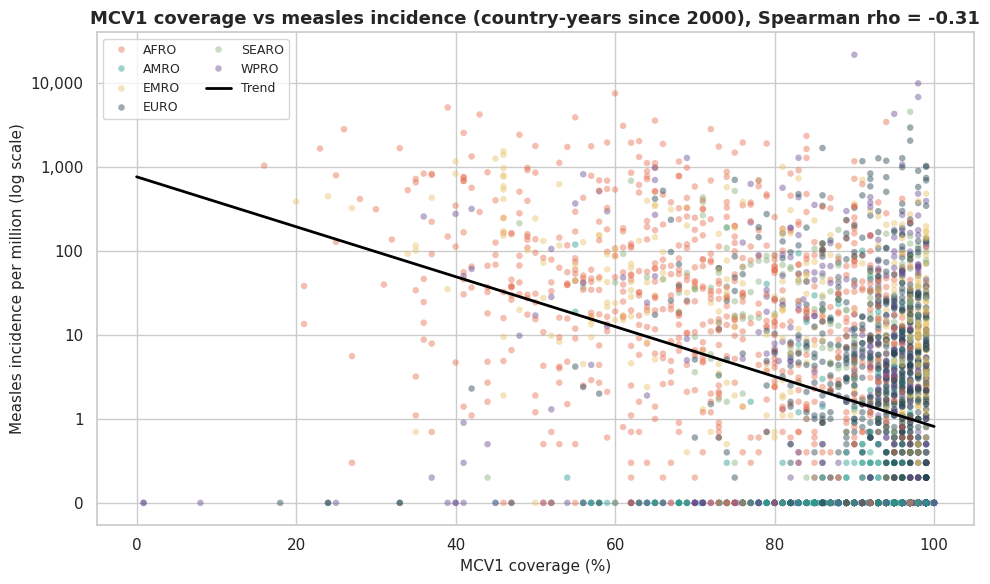

In [32]:
# Chart - 8 : Measles vaccine coverage vs measles incidence
d8 = (pairs.query("antigen_code == 'MCV1' and disease_code == 'MEASLES' and year >= 2000").dropna(subset=["incidence_reported"])
      .assign(y=lambda d: np.log10(d.incidence_reported + 0.1)))
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=d8.sample(min(len(d8), 3500), random_state=1), x="coverage_pct", y="y", hue="who_region", hue_order=REGION_ORDER,
                palette=REGION_COLORS, alpha=.45, s=22, edgecolor="none", ax=ax)
slope8, icpt8 = np.polyfit(d8.coverage_pct, d8.y, 1)
xs = np.linspace(0, 100, 50)
ax.plot(xs, slope8 * xs + icpt8, color="black", lw=2, label="Trend")
ax.set_yticks([-1, 0, 1, 2, 3, 4]); ax.set_yticklabels(["0", "1", "10", "100", "1,000", "10,000"])
rho_mcv1, p_mcv1 = stats.spearmanr(d8.coverage_pct, d8.incidence_reported)
ax.set(title=f"MCV1 coverage vs measles incidence (country-years since 2000), Spearman rho = {rho_mcv1:.2f}",
       xlabel="MCV1 coverage (%)", ylabel="Measles incidence per million (log scale)")
ax.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()
c8_n = len(d8); c8_fold10 = 10 ** (-slope8 * 10)

##### 1. Why did you pick the specific chart?

A scatter plot is the standard tool for a numeric-vs-numeric relationship; colouring by WHO region checks whether the pattern holds everywhere, and a log axis is needed because incidence spans five orders of magnitude.

##### 2. What is/are the insight(s) found from the chart?

Higher coverage goes with lower incidence: **Spearman rho = -0.31** over 4,491 country-years. On the fitted line every extra 10 points of MCV1 coverage is associated with about **2.0 times lower** incidence. The cloud is wide at any coverage level, so coverage alone does not fully explain outbreaks (see Chart 20).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this is the core evidence that immunization investment pays off - a data-driven argument for policy makers and donors. **Negative:** the wide scatter warns that hitting a national average is not enough; countries at 80-90% still see outbreaks, so programmes must also monitor who is missed. (An association, not proof of causation: other factors such as surveillance quality and population mixing also matter.)

#### Chart - 9 : Measles incidence by MCV1 coverage band

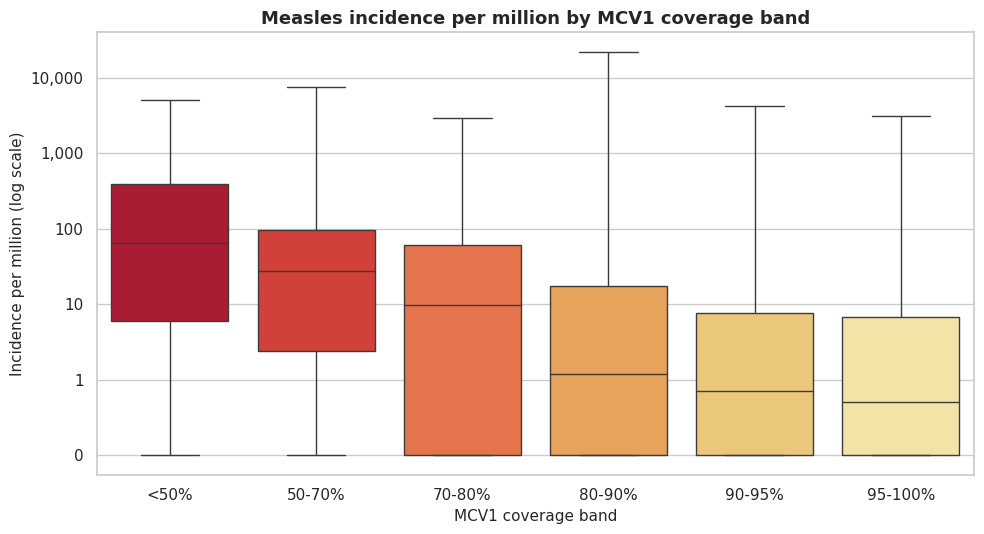

In [33]:
# Chart - 9 : Measles incidence by MCV1 coverage band
BANDS = [-1, 50, 70, 80, 90, 95, 100]
LABELS = ["<50%", "50-70%", "70-80%", "80-90%", "90-95%", "95-100%"]
d9 = d8.assign(band=pd.cut(d8.coverage_pct, BANDS, labels=LABELS))
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=d9, x="band", y="y", palette="YlOrRd_r", showfliers=False, ax=ax)
ax.set_yticks([-1, 0, 1, 2, 3, 4]); ax.set_yticklabels(["0", "1", "10", "100", "1,000", "10,000"])
ax.set(title="Measles incidence per million by MCV1 coverage band", xlabel="MCV1 coverage band", ylabel="Incidence per million (log scale)")
plt.tight_layout(); plt.show()
band_med = d9.groupby("band").incidence_reported.median()
band_n = d9.groupby("band").size()
mea_med_low, mea_med_high = band_med["<50%"], band_med["95-100%"]
c9_ratio = mea_med_low / max(mea_med_high, 0.1)
c9_mono = bool(band_med.is_monotonic_decreasing)
c9_p90 = d9[d9.band == "80-90%"].incidence_reported.quantile(.9)

##### 1. Why did you pick the specific chart?

Grouping coverage into policy-relevant bands and drawing a box plot per band shows the *typical* incidence (median) and the spread in each band - clearer than a scatter for communicating thresholds such as the 95% target.

##### 2. What is/are the insight(s) found from the chart?

Median incidence falls at every step: about **65 per million below 50% coverage, 10 at 70-80%, 1.1 at 80-90% and 0.4 at 95-100%** - a difference of roughly 163 times between the lowest and highest band.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it justifies concrete coverage thresholds for planning (target 95% for measles). **Negative:** countries in the 80-90% band (n = 919) have a median of only 1.1 per million, but the worst 10% exceed 89 per million, so big outbreaks still occur; treating 'high' coverage as safe would give false reassurance.

#### Chart - 10 : Drop-off between the first dose and later doses, by region

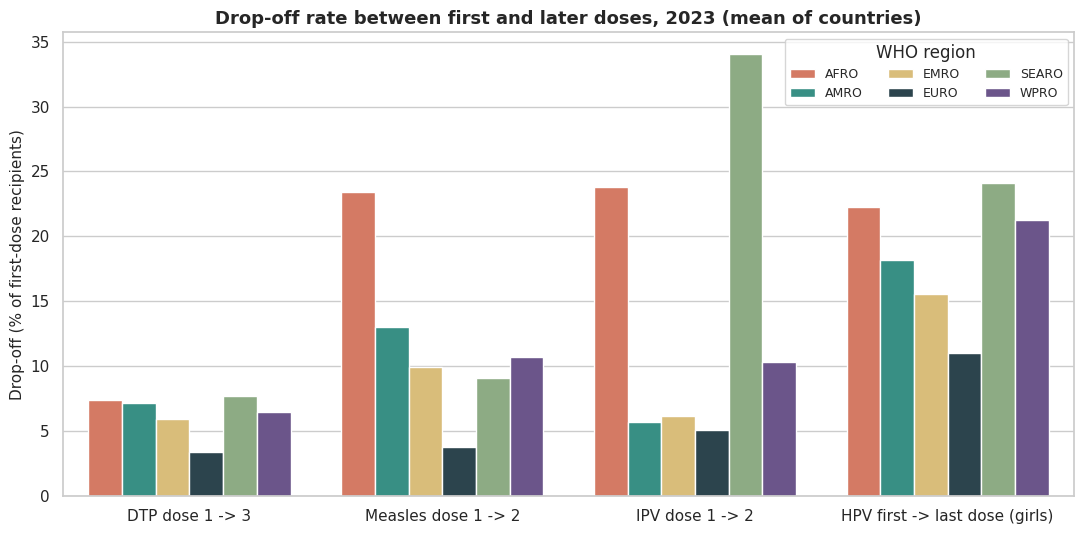

In [34]:
# Chart - 10 : Drop-off between the first dose and later doses, by region
PAIRS10 = {"DTP dose 1 -> 3": ("DTPCV1", "DTPCV3"), "Measles dose 1 -> 2": ("MCV1", "MCV2"),
           "IPV dose 1 -> 2": ("IPV1", "IPV2"), "HPV first -> last dose (girls)": ("PRHPV1_F", "PRHPVC_F")}
w10 = latest(cov_best).pivot_table(index=["country_code", "who_region"], columns="antigen_code", values="coverage_pct").reset_index()
rows10 = []
for lab, (a, b) in PAIRS10.items():
    t = w10[["who_region", a, b]].dropna()
    t = t[t[a] > 0].assign(dropout=lambda d: ((d[a] - d[b]) / d[a] * 100).clip(0, 100), pair=lab)    # drop-off = share of first-dose recipients who miss the later dose
    rows10.append(t[["who_region", "pair", "dropout"]])
t10 = pd.concat(rows10)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=t10, x="pair", y="dropout", hue="who_region", hue_order=REGION_ORDER, palette=REGION_COLORS, errorbar=None, ax=ax)
ax.set(title=f"Drop-off rate between first and later doses, {LATEST_YEAR} (mean of countries)", xlabel="", ylabel="Drop-off (% of first-dose recipients)")
ax.legend(title="WHO region", ncol=3, fontsize=9); plt.tight_layout(); plt.show()
dr10 = t10.groupby("pair").dropout.agg(["mean", "count"])
c10_dtp, c10_mcv, c10_ipv, c10_hpv = (dr10.loc[k, "mean"] for k in ["DTP dose 1 -> 3", "Measles dose 1 -> 2", "IPV dose 1 -> 2", "HPV first -> last dose (girls)"])
c10_hpv_n = int(dr10.loc["HPV first -> last dose (girls)", "count"])
c10_worst = t10.groupby(["pair", "who_region"]).dropout.mean().idxmax(); c10_worst_v = t10.groupby(["pair", "who_region"]).dropout.mean().max()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares the same measure (drop-off) across several vaccines and six regions at once. Drop-off = (first dose coverage - later dose coverage) / first dose coverage, so it isolates children who *started but did not finish* a series.

##### 2. What is/are the insight(s) found from the chart?

Drop-off is small for the infant DTP series (**6.0%**) but larger for schedules that need a return visit later: **measles second dose 11.9%, IPV second dose 10.9%, HPV completion 17.4%** (HPV based on 130 countries). The worst regional value is IPV dose 1 -> 2 in SEARO (34%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** drop-off is a cheap-to-fix problem: the child is already known to the system, so reminders, tracking and combined visits recover coverage more cheaply than reaching new children. **Negative:** the later a dose falls in the schedule, the more children are lost, so any schedule that adds boosters without follow-up systems will lower total protection.

#### Chart - 11 : HPV vaccine coverage by gender

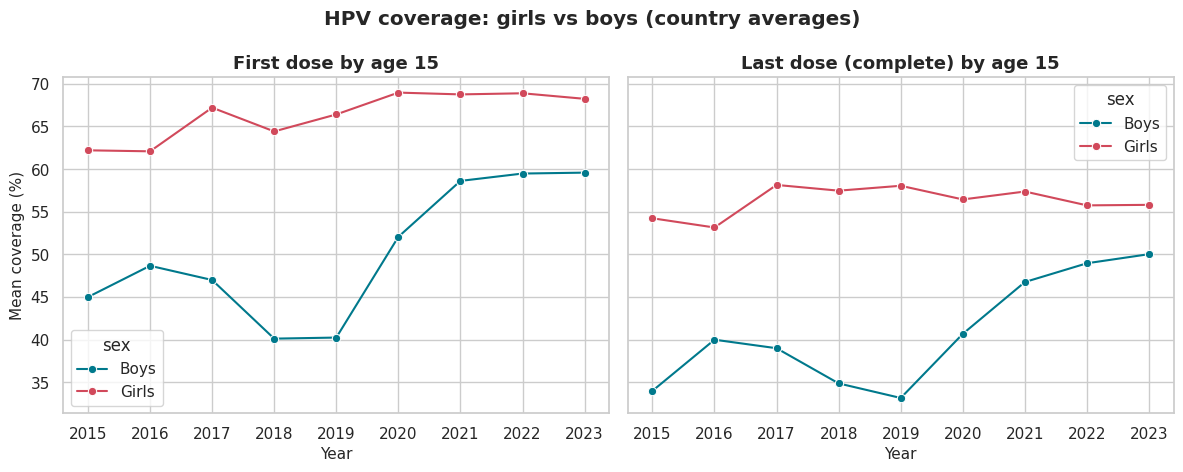

In [35]:
# Chart - 11 : HPV vaccine coverage by gender
h11 = fact_coverage[fact_coverage.antigen_code.isin(["15HPV1_F", "15HPV1_M", "15HPVC_F", "15HPVC_M"])].dropna(subset=["coverage_pct"]).copy()
h11["sex"] = h11.antigen_code.str[-1].map({"F": "Girls", "M": "Boys"})
h11["dose"] = np.where(h11.antigen_code.str.contains("HPV1"), "First dose by age 15", "Last dose (complete) by age 15")
tr11 = h11[h11.year >= 2015].groupby(["year", "sex", "dose"]).agg(cov=("coverage_pct", "mean"), n=("coverage_pct", "size")).reset_index()
fig, axs = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, (dose, g) in zip(axs, tr11.groupby("dose")):
    sns.lineplot(data=g, x="year", y="cov", hue="sex", marker="o", palette={"Girls": "#d1495b", "Boys": "#00798c"}, ax=ax)
    ax.set(title=dose, xlabel="Year", ylabel="Mean coverage (%)")
plt.suptitle("HPV coverage: girls vs boys (country averages)", fontweight="bold"); plt.tight_layout(); plt.show()
p11 = h11[(h11.year == LATEST_YEAR) & h11.dose.str.startswith("First")].pivot_table(index="country_code", columns="sex", values="coverage_pct").dropna()
c11_n, c11_f, c11_m = len(p11), p11.Girls.mean(), p11.Boys.mean()
c11_share = (p11.Girls > p11.Boys).mean()
c11_boys_first_year = int(h11[h11.sex == "Boys"].year.min())
f1 = tr11[tr11.dose.str.startswith("First")].pivot(index="year", columns="sex", values="cov")
c11_f19, c11_f23, c11_m19, c11_m23 = f1.Girls.loc[2019], f1.Girls.loc[LATEST_YEAR], f1.Boys.loc[2019], f1.Boys.loc[LATEST_YEAR]

##### 1. Why did you pick the specific chart?

Gender is only recorded for HPV, so a two-panel line chart (first dose and completed series) is the only place the data allow a male-female comparison over time.

##### 2. What is/are the insight(s) found from the chart?

In the 34 countries that report both sexes in 2023, girls' first-dose coverage averages **71% vs 60% for boys** (girls higher in 79% of countries). Across all reporting countries, girls' first-dose coverage moved from 66% (2019) to 68% (2023) while boys' moved from 40% to 60% (boys' data start in 2011, with very few countries until gender-neutral programmes spread). Country composition changes over time, so the lines are indicative.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** boys' coverage is rising (40% -> 60%), which adds protection against HPV-related cancers and helps herd effects. **Negative:** girls' first-dose coverage of 68% is well below the 90% goal for cervical cancer elimination, and the dataset has **no gender split for any other vaccine**, so gender equity in routine immunization cannot be assessed - a data gap that should be closed with sex-disaggregated reporting.

#### Chart - 12 : Booster dose uptake over time

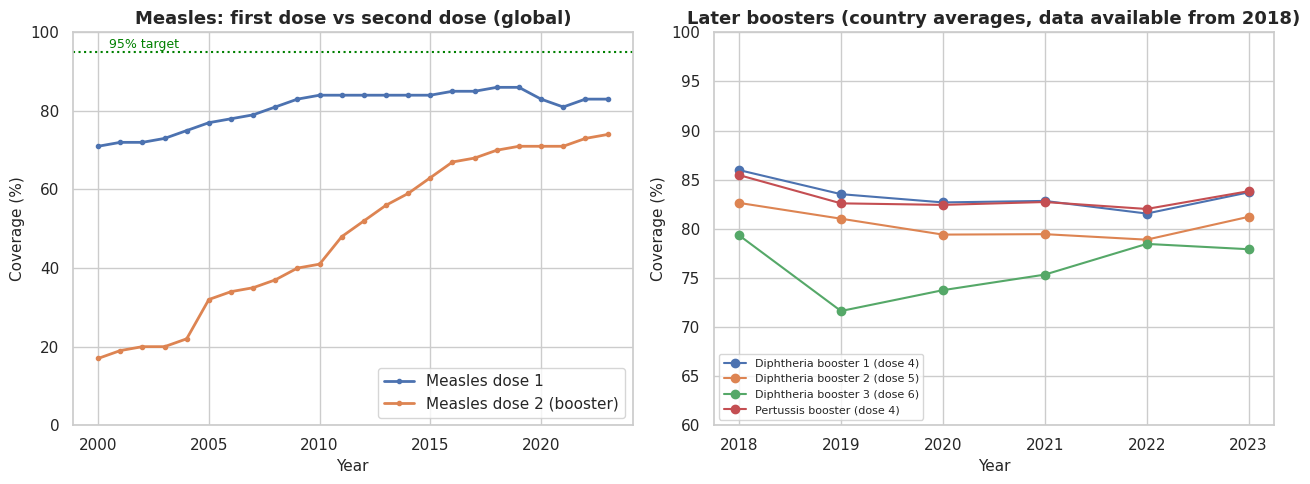

In [36]:
# Chart - 12 : Booster dose uptake over time
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for a, lab in {"MCV1": "Measles dose 1", "MCV2": "Measles dose 2 (booster)"}.items():
    s12 = gl(a).loc[2000:]
    axs[0].plot(s12.index, s12.values, marker="o", ms=3, lw=2, label=lab)
axs[0].axhline(95, color="green", ls=":"); axs[0].text(2000.5, 96, "95% target", color="green", fontsize=9)
axs[0].set(title="Measles: first dose vs second dose (global)", xlabel="Year", ylabel="Coverage (%)", ylim=(0, 100)); axs[0].legend(loc="lower right")

B12 = {"DIPHCV4": "Diphtheria booster 1 (dose 4)", "DIPHCV5": "Diphtheria booster 2 (dose 5)", "DIPHCV6": "Diphtheria booster 3 (dose 6)", "PERCV4": "Pertussis booster (dose 4)"}
t12 = cov_best[cov_best.antigen_code.isin(B12) & (cov_best.year >= 2018)].groupby(["year", "antigen_code"]).coverage_pct.mean().unstack()
for a, lab in B12.items():
    axs[1].plot(t12.index, t12[a], marker="o", label=lab)
axs[1].set(title="Later boosters (country averages, data available from 2018)", xlabel="Year", ylabel="Coverage (%)", ylim=(60, 100)); axs[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()
mcv2_2000, mcv2_2010 = gl("MCV2").loc[2000], gl("MCV2").loc[2010]
c12_b1_first, c12_b1_last = t12["DIPHCV4"].loc[2019], t12["DIPHCV4"].loc[LATEST_YEAR]
c12_b3_first, c12_b3_last = t12["DIPHCV6"].loc[2018], t12["DIPHCV6"].loc[LATEST_YEAR]
c12_b2_first, c12_b2_last = t12["DIPHCV5"].loc[2018], t12["DIPHCV5"].loc[LATEST_YEAR]

##### 1. Why did you pick the specific chart?

Two panels answer two questions: the long global history of the most important booster (measles dose 2, from 2000) and the short country-level history of the later diphtheria/pertussis boosters (recorded only from 2018).

##### 2. What is/are the insight(s) found from the chart?

**Measles second-dose uptake grew strongly:** 17% (2000) -> 41% (2010) -> 74% (2023), but growth flattened after 2019 and it is still below MCV1. The later diphtheria boosters have been roughly flat or slightly rising since 2018 (booster 1: 84% -> 84%; booster 2: 83% -> 81%; booster 3: 79% -> 78%), and each additional booster has lower coverage than the one before.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the trend for MCV2 confirms countries can add and scale a second dose. **Negative:** booster coverage declines with every extra visit, so protection wanes in older children and adolescents, a group in which pertussis and diphtheria outbreaks are commonly seen. Booster reminders and school-based delivery should be prioritised.

#### Chart - 13 : Country size (target cohort) vs DTP3 coverage

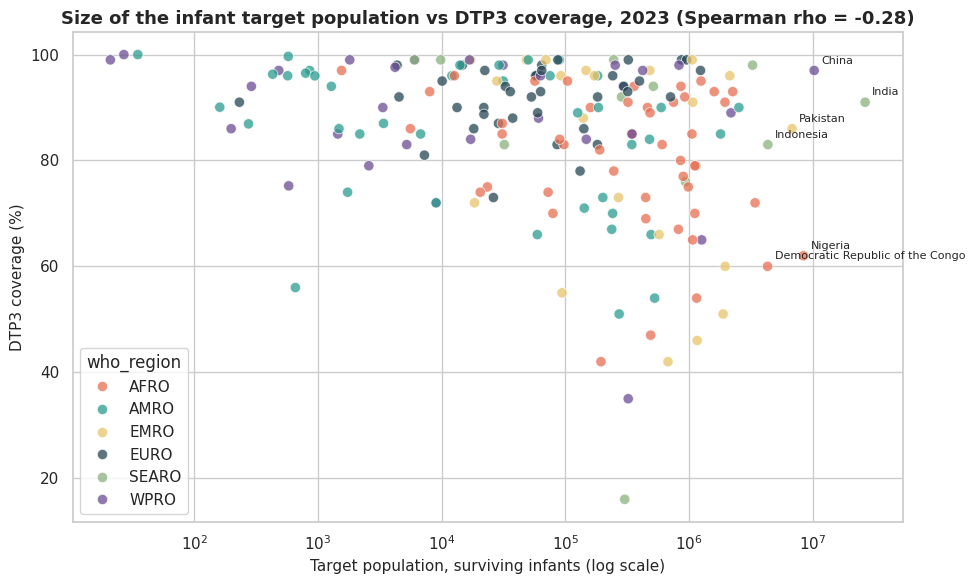

In [37]:
# Chart - 13 : Country size (target cohort) vs DTP3 coverage
d13 = latest(cov_best).query("antigen_code == 'DTPCV3'").dropna(subset=["target_any"])
d13 = d13[d13.target_any > 0]
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=d13, x="target_any", y="coverage_pct", hue="who_region", hue_order=REGION_ORDER, palette=REGION_COLORS, s=55, alpha=.75, ax=ax)
ax.set_xscale("log")
for _, r in d13.nlargest(6, "target_any").iterrows():
    ax.annotate(r.country_name.split(" (")[0], (r.target_any, r.coverage_pct), xytext=(5, 5), textcoords="offset points", fontsize=8)
rho13, p13 = stats.spearmanr(np.log10(d13.target_any), d13.coverage_pct)
ax.set(title=f"Size of the infant target population vs DTP3 coverage, {LATEST_YEAR} (Spearman rho = {rho13:.2f})", xlabel="Target population, surviving infants (log scale)", ylabel="DTP3 coverage (%)")
plt.tight_layout(); plt.show()
q_hi, q_lo = d13.target_any.quantile(.75), d13.target_any.quantile(.25)
c13_n, c13_big, c13_small = len(d13), d13[d13.target_any >= q_hi].coverage_pct.median(), d13[d13.target_any <= q_lo].coverage_pct.median()

##### 1. Why did you pick the specific chart?

Population density is **not** in the data set. The closest available proxy is the size of the target cohort, so a log-scale scatter of cohort size vs coverage shows whether larger countries do better or worse. Labelling the biggest countries makes the plot actionable.

##### 2. What is/are the insight(s) found from the chart?

There is a weak-to-moderate **negative** relationship (rho = -0.28, n = 186): the largest quartile of countries has median DTP3 coverage 85% compared with 94% for the smallest quartile. Big countries such as Nigeria, India and Indonesia sit in the range where a few percentage points equal millions of children. **This is a size proxy, not population density.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** because large countries hold most of the world's children, improving coverage in just a handful of them lifts the global figure the most. **Negative:** the relationship is weak, so size alone should not drive allocation; and true density / urban-rural effects cannot be tested here - collecting sub-national coverage would be needed to answer those questions.

#### Chart - 14 : Reduction in reported cases of vaccine-preventable diseases since 1980

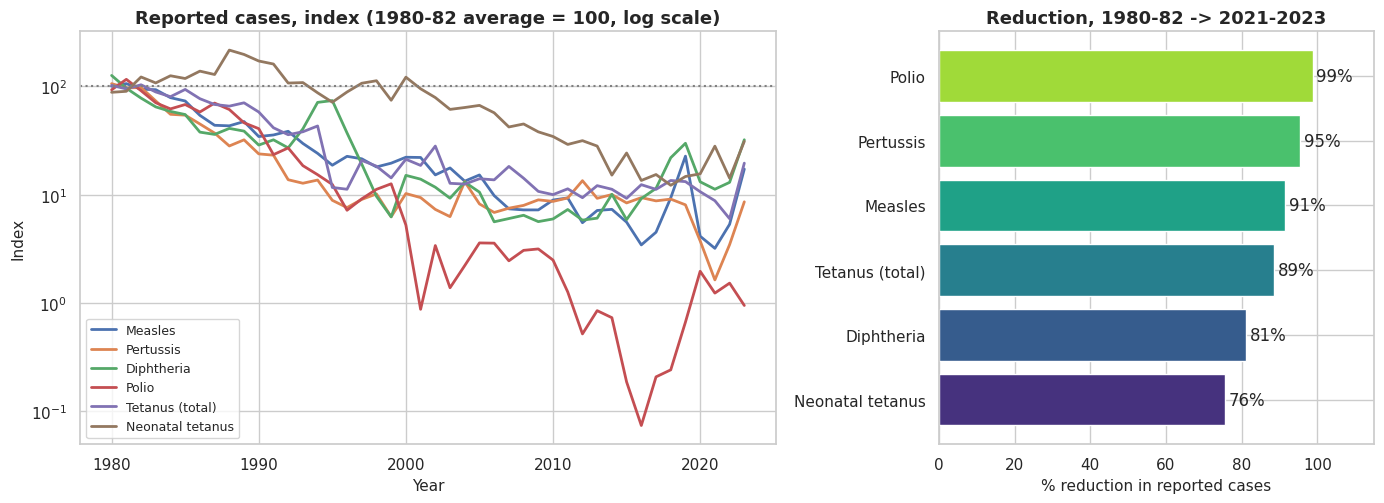

In [38]:
# Chart - 14 : Reduction in reported cases of vaccine-preventable diseases since 1980
D14 = {"MEASLES": "Measles", "PERTUSSIS": "Pertussis", "DIPHTHERIA": "Diphtheria", "POLIO": "Polio", "TTETANUS": "Tetanus (total)", "NTETANUS": "Neonatal tetanus"}
tab14 = pd.DataFrame({d: gcases(d) for d in D14}).loc[1980:]
base14 = tab14.loc[1980:1982].mean()
idx14 = tab14 / base14 * 100
red14 = (1 - tab14.loc[LATEST_YEAR - 2:LATEST_YEAR].mean() / base14) * 100
fig, axs = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.6, 1]})
for d, lab in D14.items():
    axs[0].plot(idx14.index, idx14[d], lw=2, label=lab)
axs[0].set_yscale("log"); axs[0].axhline(100, color="grey", ls=":")
axs[0].set(title="Reported cases, index (1980-82 average = 100, log scale)", xlabel="Year", ylabel="Index")
axs[0].legend(fontsize=9)
r14 = red14.rename(D14).sort_values()
axs[1].barh(r14.index, r14.values, color=sns.color_palette("viridis", len(r14)))
for i, v in enumerate(r14.values):
    axs[1].text(v + 1, i, f"{v:.0f}%", va="center")
axs[1].set(title=f"Reduction, 1980-82 -> {LATEST_YEAR - 2}-{LATEST_YEAR}", xlabel="% reduction in reported cases", xlim=(0, 115))
plt.tight_layout(); plt.show()
red_polio, red_pert, red_meas, red_dip, red_tt, red_nt = (red14[d] for d in ["POLIO", "PERTUSSIS", "MEASLES", "DIPHTHERIA", "TTETANUS", "NTETANUS"])
c14_top = D14[red14.idxmax()]; c14_low = D14[red14.idxmin()]; c14_low_v = red14.min()

##### 1. Why did you pick the specific chart?

An indexed log-scale line chart makes diseases with very different case counts (millions vs thousands) comparable, and the paired bar chart ranks them by percentage reduction. Only diseases reported by nearly all countries since 1980 are used, because global totals for newly-reported diseases would show surveillance growth, not real change.

##### 2. What is/are the insight(s) found from the chart?

All six long-running diseases fell dramatically. **Polio shows the largest fall (99%)**, followed by pertussis (95%), measles (91%), tetanus (89%) and diphtheria (81%); neonatal tetanus fell 76%. The smallest reduction is Neonatal tetanus (76%). The curves also show rebounds after 2019 (measles, diphtheria) - proof that gains are reversible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** reported cases of these six diseases are down by 76-99% since 1980-82 - the strongest evidence for sustaining budgets. **Negative:** measles and diphtheria are climbing again after the pandemic dip; polio's 99% fall still leaves a small number of cases that keep global eradication incomplete. (Reported cases understate the true burden and depend on surveillance.)

#### Chart - 15 : Coverage gap between country income groups

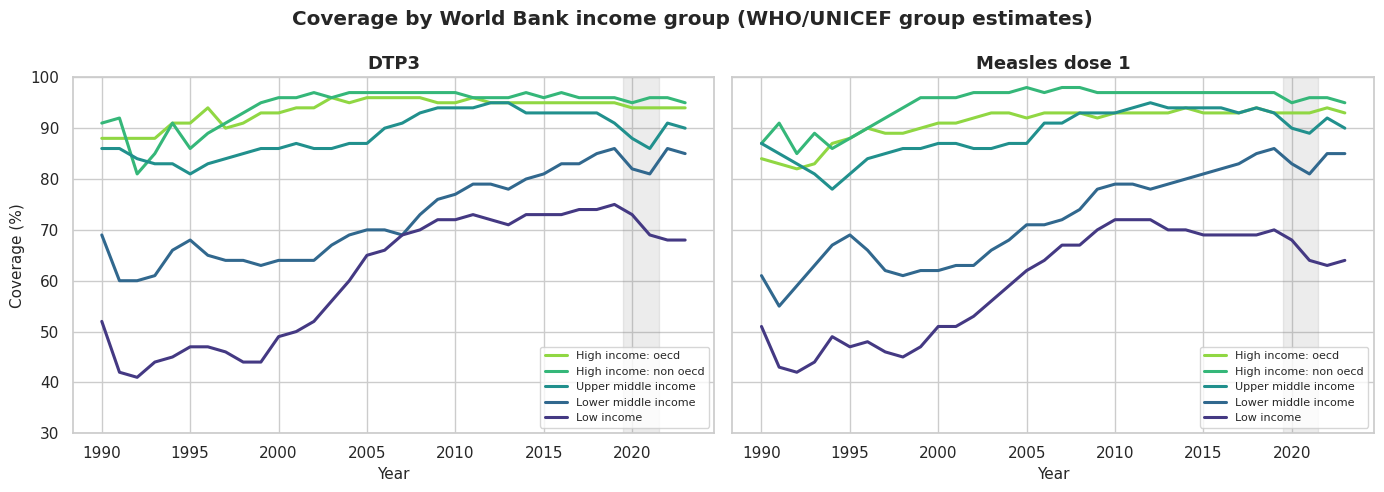

In [39]:
# Chart - 15 : Coverage gap between country income groups
g15 = fact_coverage_group.query("group_type == 'WB_LONG' and category_code == 'WUENIC' and antigen_code in ['DTPCV3', 'MCV1'] and group_name != 'Not classified' and year >= 1990")
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
order15 = ["High income: oecd", "High income: non oecd", "Upper middle income", "Lower middle income", "Low income"]
for ax, (a, lab) in zip(axs, {"DTPCV3": "DTP3", "MCV1": "Measles dose 1"}.items()):
    sns.lineplot(data=g15[g15.antigen_code == a], x="year", y="coverage_pct", hue="group_name", hue_order=order15, palette="viridis_r", lw=2.2, ax=ax)
    ax.axvspan(2019.5, 2021.5, color="grey", alpha=.15)
    ax.set(title=lab, xlabel="Year", ylabel="Coverage (%)", ylim=(30, 100)); ax.legend(title="", fontsize=8, loc="lower right")
plt.suptitle("Coverage by World Bank income group (WHO/UNICEF group estimates)", fontweight="bold"); plt.tight_layout(); plt.show()
p15 = g15[g15.antigen_code == "DTPCV3"].pivot_table(index="year", columns="group_name", values="coverage_pct")
lic_dtp3, lic_dtp3_2019, hic_dtp3 = p15.loc[LATEST_YEAR, "Low income"], p15.loc[2019, "Low income"], p15.loc[LATEST_YEAR, "High income: oecd"]
lmic_dtp3 = p15.loc[LATEST_YEAR, "Lower middle income"]
c15_gap = hic_dtp3 - lic_dtp3
c15_gap19 = p15.loc[2019, "High income: oecd"] - lic_dtp3_2019

##### 1. Why did you pick the specific chart?

Coverage is a numeric variable, income group a category, and time the third dimension - so one line per income group is the clearest way to show both the level of the gap and its evolution. This also answers the socioeconomic-disparity question at group level.

##### 2. What is/are the insight(s) found from the chart?

Coverage is ordered by income. In 2023, **low-income countries reach 68% DTP3 vs 94% in high-income OECD countries: a 26-point gap**. Lower-middle-income countries recovered to 85%, but **low-income countries fell from 75% (2019) to 68%** while rich countries stayed flat, so the pandemic set back the poorest most.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the gap is measurable, so donors (e.g. Gavi) can target support to low-income countries with a clear metric. **Negative:** the gap grew from 20 points in 2019 to 26, which means the world's poorest children are becoming *relatively* less protected, which is both an equity failure and a health-security risk. (Income groups are country-level; the data cannot show inequality *within* a country.)

#### Chart - 16 : Vaccine introduction timelines by WHO region

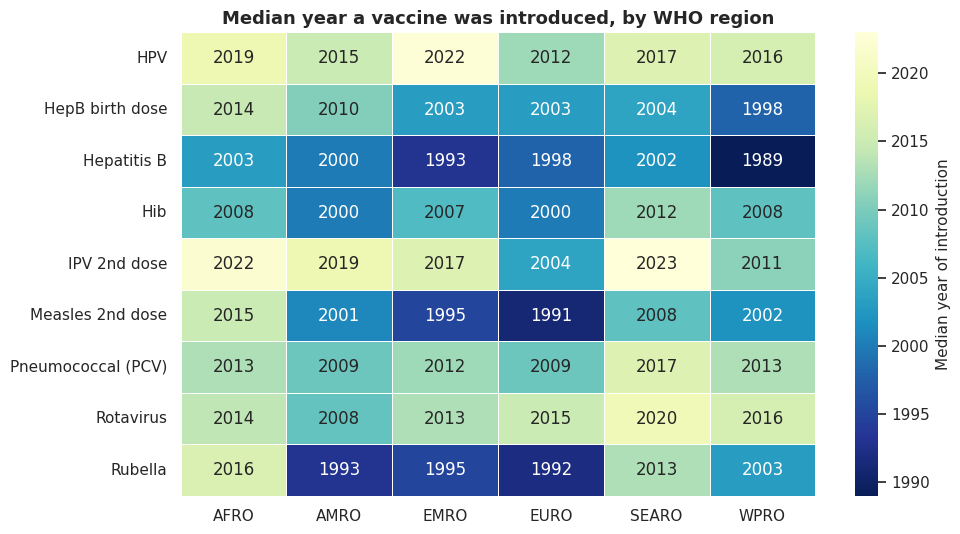

In [40]:
# Chart - 16 : Vaccine introduction timelines by WHO region
V16 = {"Hepatitis B vaccine": "Hepatitis B", "Hib (Haemophilus influenzae type B) vaccine": "Hib", "Measles-containing vaccine 2nd dose": "Measles 2nd dose",
       "Rubella vaccine": "Rubella", "PCV (Pneumococcal conjugate vaccine)": "Pneumococcal (PCV)", "Rotavirus vaccine": "Rotavirus",
       "HPV (Human Papilloma Virus) vaccine": "HPV", "IPV (Inactivated polio vaccine) 2nd dose": "IPV 2nd dose", "HepB birth dose": "HepB birth dose"}
h16 = (intro_first[intro_first.vaccine_description.isin(V16)]
       .pivot_table(index="vaccine_description", columns="who_region", values="first_year", aggfunc="median").reindex(columns=REGION_ORDER).rename(index=V16))
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(h16, annot=True, fmt=".0f", cmap="YlGnBu_r", linewidths=.5, cbar_kws={"label": "Median year of introduction"}, ax=ax)
ax.set(title="Median year a vaccine was introduced, by WHO region", xlabel="", ylabel="")
plt.tight_layout(); plt.show()
gap16 = (h16.max(axis=1) - h16.min(axis=1)).sort_values(ascending=False)
c16_v, c16_gap = gap16.index[0], gap16.iloc[0]
c16_first, c16_last = h16.loc[c16_v].idxmin(), h16.loc[c16_v].idxmax()
c16_meas_gap = gap16["Measles 2nd dose"]; c16_rub_gap = gap16["Rubella"]
c16_afro_late = int((h16.idxmax(axis=1) == "AFRO").sum())
c16_top3 = ", ".join(f"{v} ({g:.0f} years)" for v, g in gap16.head(3).items())

##### 1. Why did you pick the specific chart?

A region x vaccine heatmap of the *median introduction year* highlights timing differences at a glance; a lighter/darker cell instantly shows which regions adopted a vaccine early or late.

##### 2. What is/are the insight(s) found from the chart?

Adoption timing differs a lot. The widest regional gaps are for **Rubella (24 years), Measles 2nd dose (24 years), IPV 2nd dose (19 years)**; for Rubella the earliest region is EURO and the latest AFRO. The African Region is the latest adopter for 4 of the 9 vaccines shown, while Europe and the Americas usually lead.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** disparities are quantified, supporting the case for faster introduction support (Gavi, WHO prequalification, pooled procurement) in late-adopting regions. **Negative:** every year of delay is a birth cohort left unprotected; Africa, the latest adopter for 4 of the 9 vaccines, is also the region with the lowest MCV2 coverage (62%, Chart 7).

#### Chart - 17 : Disease incidence before and after vaccine introduction (event study)

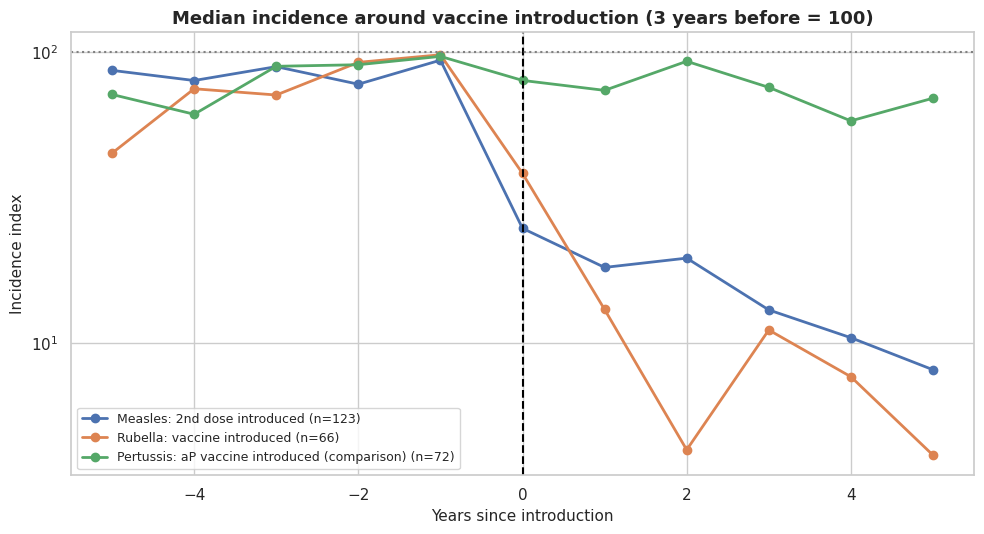

,countries,median_change_%,share_with_decline_%,wilcoxon_p
event,,,,
Measles: 2nd dose introduced,123,-69.487,65.854,0.000
Rubella: vaccine introduced,66,-83.913,81.818,0.000
Pertussis: aP vaccine introduced (comparison),69,-14.286,55.072,0.389


In [41]:
# Chart - 17 : Disease incidence before and after vaccine introduction (event study)
def event_study(vaccine, disease, window=5, y0=1985, y1=2018):
    """Incidence in the years around the first year a country introduced a vaccine (0 = introduction year), relative to the 3 years before (=100)."""
    fy = intro_first[(intro_first.vaccine_description == vaccine) & intro_first.first_year.between(y0, y1)]
    s = burden[burden.disease_code == disease].set_index(["country_code", "year"]).incidence_reported
    out = []
    for _, r in fy.iterrows():
        v = {k: s.get((r.country_code, r.first_year + k), np.nan) for k in range(-window, window + 1)}
        base = np.nanmean([v[k] for k in (-3, -2, -1)])
        if pd.notna(base) and base > 0:
            out.append({"country": r.country_code, **{k: v[k] / base * 100 for k in v}, "before": base, "after": np.nanmean([v[k] for k in (1, 2, 3)])})
    return pd.DataFrame(out)


EV = {"Measles: 2nd dose introduced": ("Measles-containing vaccine 2nd dose", "MEASLES"),
      "Rubella: vaccine introduced": ("Rubella vaccine", "RUBELLA"),
      "Pertussis: aP vaccine introduced (comparison)": ("aP (acellular pertussis) vaccine", "PERTUSSIS")}
fig, ax = plt.subplots(figsize=(10, 5.5))
ev_rows = []
for lab, (vac, dis) in EV.items():
    e = event_study(vac, dis)
    med = e[list(range(-5, 6))].median()
    ax.plot(med.index, med.values, marker="o", lw=2, label=f"{lab} (n={len(e)})")
    e = e.dropna(subset=["before", "after"]); e = e[e.before > 0]
    chg = (e.after - e.before) / e.before * 100
    ev_rows.append({"event": lab, "countries": len(e), "median_change_%": chg.median(), "share_with_decline_%": (chg < 0).mean() * 100,
                    "wilcoxon_p": stats.wilcoxon(e.before, e.after).pvalue})
ax.axvline(0, color="black", ls="--"); ax.axhline(100, color="grey", ls=":")
ax.set(title="Median incidence around vaccine introduction (3 years before = 100)", xlabel="Years since introduction", ylabel="Incidence index", yscale="log")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
fmt_p = lambda p: "< 0.001" if p < 0.001 else f"= {p:.3f}"
ev_tbl = pd.DataFrame(ev_rows).set_index("event").round(3)
ev_mcv2_chg, ev_rub_chg, ev_ap_chg = (ev_tbl["median_change_%"].iloc[i] for i in (0, 1, 2))
ev_mcv2_n, ev_rub_n, ev_ap_n = (int(ev_tbl["countries"].iloc[i]) for i in (0, 1, 2))
ev_mcv2_p, ev_rub_p, ev_ap_p = (ev_tbl["wilcoxon_p"].iloc[i] for i in (0, 1, 2))
ev_mcv2_dec, ev_rub_dec = ev_tbl["share_with_decline_%"].iloc[0], ev_tbl["share_with_decline_%"].iloc[1]
ev_tbl

##### 1. Why did you pick the specific chart?

An *event-study* line chart aligns all countries on their own introduction year, so the before/after shape of the incidence curve can be compared across many countries with different introduction dates. It answers 'what is the trend before and after campaigns/introductions?'. The pertussis aP switch is included as a comparison: it replaces an existing vaccine, so no big change is expected.

##### 2. What is/are the insight(s) found from the chart?

After **second-dose measles introduction (123 countries)** the median country's incidence is **69% lower** in the three years after than in the three years before (66% of countries fell; Wilcoxon p < 0.001). For **rubella (66 countries) the median fall is 84%** (p < 0.001). In contrast, changing to acellular pertussis (69 countries) shows only a 14% median fall (p = 0.389, not significant), as expected when a vaccine is replaced rather than newly added.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a consistent, statistically significant post-introduction decline gives evidence that *new* vaccine introductions deliver measurable disease reduction, supporting introduction proposals and Gavi co-financing. **Negative / caution:** this is an association - countries often introduce a vaccine *after* an outbreak, so part of the drop is regression to the mean (an unusually high year is naturally followed by lower ones), many introduce during a period of falling incidence, and outbreaks make single years noisy. A stronger design would compare against similar countries that had not introduced the vaccine.

### **M - Multivariate analysis**

#### Chart - 18 : Correlation heatmap: which vaccine coverage relates to which disease?

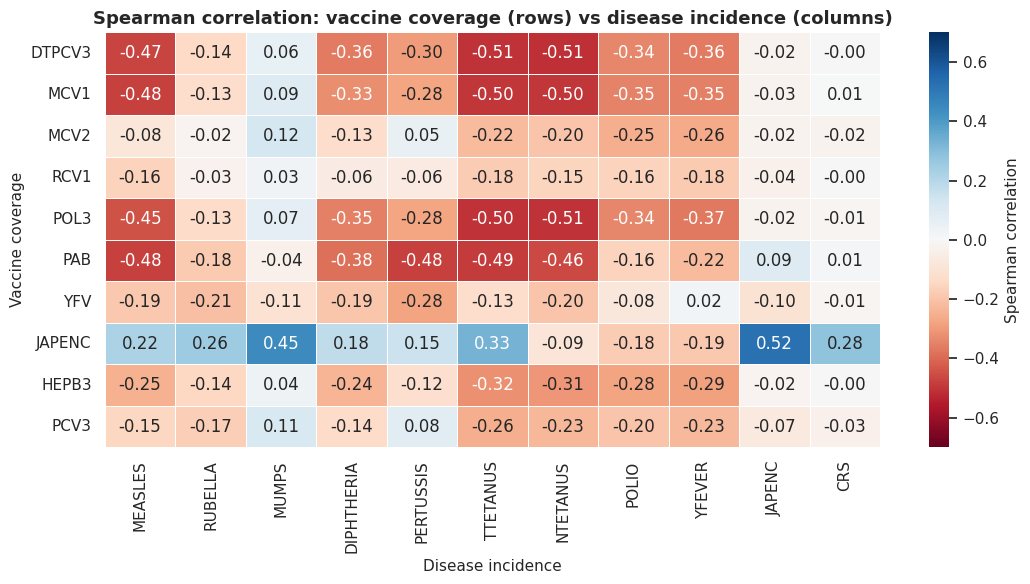

In [42]:
# Chart - 18 : Correlation heatmap: which vaccine coverage relates to which disease?
A18 = ["DTPCV3", "MCV1", "MCV2", "RCV1", "POL3", "PAB", "YFV", "JAPENC", "HEPB3", "PCV3"]
D18 = ["MEASLES", "RUBELLA", "MUMPS", "DIPHTHERIA", "PERTUSSIS", "TTETANUS", "NTETANUS", "POLIO", "YFEVER", "JAPENC", "CRS"]
cw = cov_best[cov_best.antigen_code.isin(A18)].pivot_table(index=["country_code", "year"], columns="antigen_code", values="coverage_pct")
iw = burden[burden.disease_code.isin(D18)].pivot_table(index=["country_code", "year"], columns="disease_code", values="incidence_reported")
iw.columns = ["inc_" + c for c in iw.columns]
j18 = cw.join(iw, how="inner")
mat18 = pd.DataFrame(index=A18, columns=D18, dtype=float)
for a in A18:
    for d in D18:
        t = j18[[a, "inc_" + d]].dropna()
        if len(t) >= 100:
            mat18.loc[a, d] = stats.spearmanr(t[a], t["inc_" + d])[0]          # rank correlation: robust to the skew in incidence
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(mat18.astype(float), annot=True, fmt=".2f", cmap="RdBu", center=0, vmin=-.7, vmax=.7, linewidths=.5, cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set(title="Spearman correlation: vaccine coverage (rows) vs disease incidence (columns)", xlabel="Disease incidence", ylabel="Vaccine coverage")
plt.tight_layout(); plt.show()
c18_tt, c18_mcv1, c18_dtp_dip, c18_dtp_per = mat18.loc["DTPCV3", "TTETANUS"], mat18.loc["MCV1", "MEASLES"], mat18.loc["DTPCV3", "DIPHTHERIA"], mat18.loc["DTPCV3", "PERTUSSIS"]
c18_pab, c18_pol, c18_je, c18_rcv = mat18.loc["PAB", "NTETANUS"], mat18.loc["POL3", "POLIO"], mat18.loc["JAPENC", "JAPENC"], mat18.loc["RCV1", "RUBELLA"]
c18_mcv2 = mat18.loc["MCV2", "MEASLES"]

##### 1. Why did you pick the specific chart?

A correlation matrix of *vaccines x diseases* tests many antigen-disease combinations together, showing at once where the expected protective link (negative correlation) exists and where it does not. Spearman is used because incidence is highly skewed.

##### 2. What is/are the insight(s) found from the chart?

The expected negative links are clear: **DTP3 vs tetanus -0.51, protection-at-birth vs neonatal tetanus -0.46, MCV1 vs measles -0.48**, DTP3 vs diphtheria -0.36 and pertussis -0.30, and polio -0.34. Unexpected cells: **rubella vaccine vs rubella (-0.03) and MCV2 vs measles (-0.08) are near zero, and Japanese encephalitis is positive (0.52)** - the vaccine is used only where the disease occurs (reverse causation), and the rubella/MCV2 series are probably dominated by recent introductions and changing reporting rather than by coverage levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it identifies where coverage is a good predictor of disease (tetanus, measles, diphtheria) and so where coverage monitoring is a valid early-warning tool. **Negative:** blindly using coverage to predict *every* disease would mislead - for rubella, JE and yellow fever other drivers (introduction timing, endemic geography, reporting) dominate. Analysts should use disease-specific models.

#### Chart - 19 : Pair plot: DTP3, MCV1, POL3 coverage and measles incidence

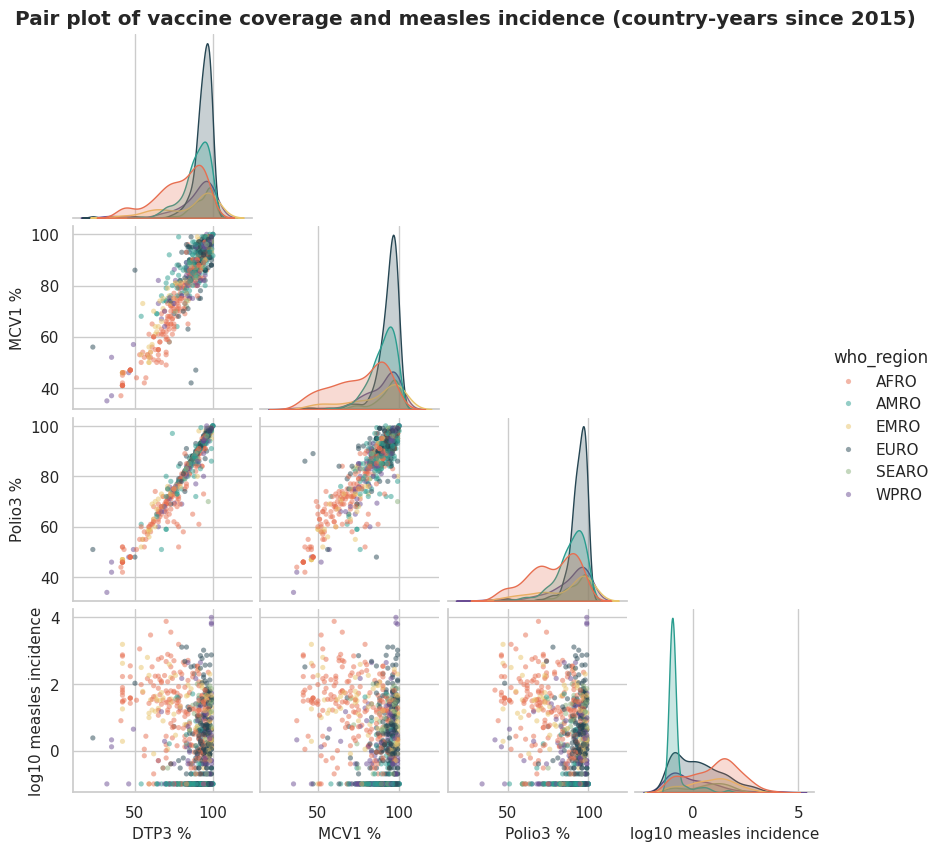

In [43]:
# Chart - 19 : Pair plot: DTP3, MCV1, POL3 coverage and measles incidence
j19 = (j18[["DTPCV3", "MCV1", "POL3", "inc_MEASLES"]].dropna().reset_index()
       .query("year >= 2015").merge(dim_country[["country_code", "who_region"]], on="country_code"))
j19["log10 measles incidence"] = np.log10(j19.inc_MEASLES + 0.1)
j19 = j19.rename(columns={"DTPCV3": "DTP3 %", "MCV1": "MCV1 %", "POL3": "Polio3 %"})
pp = sns.pairplot(j19.sample(min(len(j19), 900), random_state=3), vars=["DTP3 %", "MCV1 %", "Polio3 %", "log10 measles incidence"],
                  hue="who_region", hue_order=REGION_ORDER, palette=REGION_COLORS, corner=True, height=2.1, plot_kws=dict(alpha=.5, s=14, edgecolor="none"))
pp.fig.suptitle("Pair plot of vaccine coverage and measles incidence (country-years since 2015)", y=1.01, fontweight="bold")
plt.show()
c19_corr = j19[["DTP3 %", "MCV1 %", "Polio3 %", "log10 measles incidence"]].corr(method="spearman")
c19_dm, c19_mp, c19_dp = c19_corr.loc["DTP3 %", "MCV1 %"], c19_corr.loc["MCV1 %", "Polio3 %"], c19_corr.loc["DTP3 %", "Polio3 %"]
c19_inc = c19_corr.loc["MCV1 %", "log10 measles incidence"]; c19_n = len(j19)
c19_reg = j19.groupby("who_region")["log10 measles incidence"].median().sort_values(ascending=False)
c19_top2 = f"{c19_reg.index[0]} and {c19_reg.index[1]}"

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise relationship among four variables together with the distribution of each, coloured by region - the recommended multivariate overview for EDA.

##### 2. What is/are the insight(s) found from the chart?

DTP3, MCV1 and polio-3 coverage move almost together (rho = 0.86 for DTP3-MCV1, 0.87 for MCV1-polio, 0.97 for DTP3-polio): countries that vaccinate well against one disease do so for all. Measles incidence is negatively related to each coverage rate (MCV1: -0.23), with AFRO and EMRO country-years having the highest median incidence (1,677 country-years since 2015).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** because routine vaccines rise and fall together, one system-strengthening investment (cold chain, outreach, records) lifts all antigens - cost-effective. **Negative:** because the coverages are so highly correlated they cannot be treated as independent predictors; and it means a weak health system is weak for *every* vaccine, so a failing country needs broad rather than single-vaccine support.

#### Chart - 20 : High coverage but high incidence: measles bubble chart

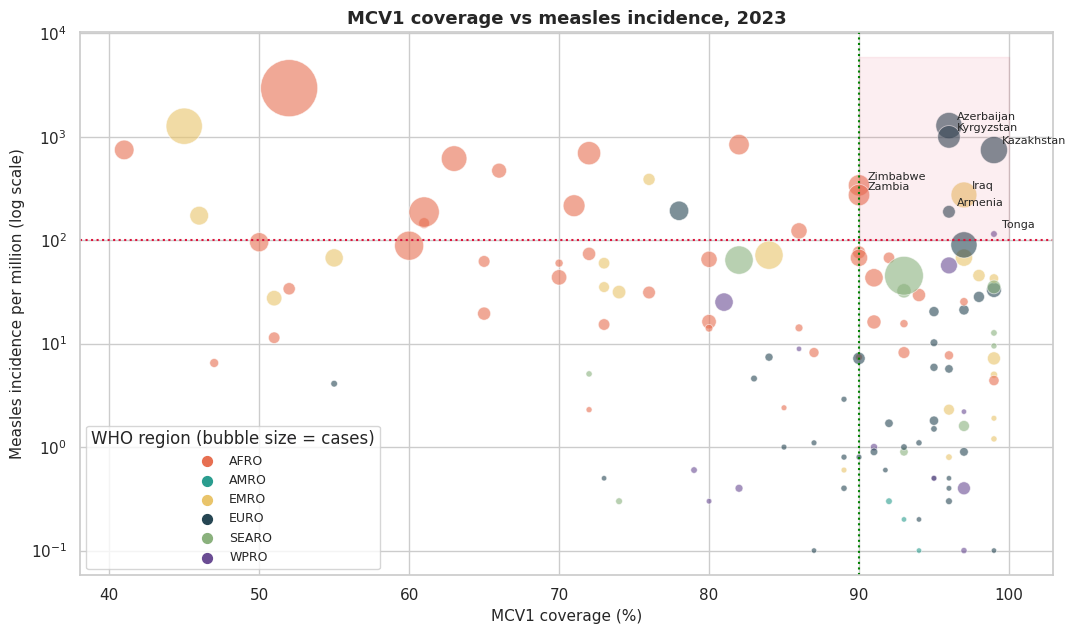

In [44]:
# Chart - 20 : High coverage but high incidence: measles bubble chart
d20 = pairs.query("antigen_code == 'MCV1' and disease_code == 'MEASLES' and year == @LATEST_YEAR").dropna(subset=["incidence_reported", "cases"])
d20 = d20[d20.incidence_reported > 0]
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(d20.coverage_pct, d20.incidence_reported, s=np.sqrt(d20.cases) * 3 + 12, c=d20.who_region.map(REGION_COLORS), alpha=.6, edgecolor="white", lw=.6)
ax.set_yscale("log"); ax.axvline(90, color="green", ls=":", lw=1.5); ax.axhline(100, color="crimson", ls=":", lw=1.5)
ax.fill_betweenx([100, d20.incidence_reported.max() * 2], 90, 100, color="crimson", alpha=.07)
hi = d20[(d20.coverage_pct >= 90) & (d20.incidence_reported > 100)].sort_values("incidence_reported", ascending=False)
for _, r in hi.head(8).iterrows():
    ax.annotate(r.country_name.split(" (")[0], (r.coverage_pct, r.incidence_reported), xytext=(6, 4), textcoords="offset points", fontsize=8)
for reg_ in REGION_ORDER:
    ax.scatter([], [], c=REGION_COLORS[reg_], label=reg_, s=50)
ax.legend(title="WHO region (bubble size = cases)", fontsize=9, loc="lower left")
ax.set(title=f"MCV1 coverage vs measles incidence, {LATEST_YEAR}", xlabel="MCV1 coverage (%)", ylabel="Measles incidence per million (log scale)")
plt.tight_layout(); plt.show()
n_high_cov_high_inc = len(hi)
c20_names = ", ".join(hi.head(5).country_name.str.split(" \\(").str[0])
c20_regions = ", ".join(f"{r} ({n})" for r, n in hi.who_region.value_counts().items())
c20_cases = int(hi.cases.sum()); c20_share = hi.cases.sum() / d20.cases.sum()

##### 1. Why did you pick the specific chart?

A bubble chart adds a third variable (number of cases as bubble size) and a fourth (region as colour) to the scatter, so we can see *where* the surprising cases lie - high coverage but high incidence - and how large those outbreaks are.

##### 2. What is/are the insight(s) found from the chart?

**8 countries report MCV1 coverage of at least 90% yet measles incidence above 100 per million** in 2023, including Azerbaijan, Kyrgyzstan, Kazakhstan, Zimbabwe, Iraq. They are concentrated in EURO (4), AFRO (2), EMRO (1), WPRO (1) and account for 59,446 cases (9% of the 2023 cases reported by countries in this chart).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** flagging these countries lets WHO target investigations at the right places. **Negative:** the pattern shows national coverage figures can hide pockets of unvaccinated communities, over-reported administrative data, waning of a single dose, or missing MCV2 - a warning against relying on a single coverage number. Possible reasons are hypotheses (data show only national averages); sub-national data are needed to confirm.

#### Chart - 21 : Disease burden by WHO region (heatmap)

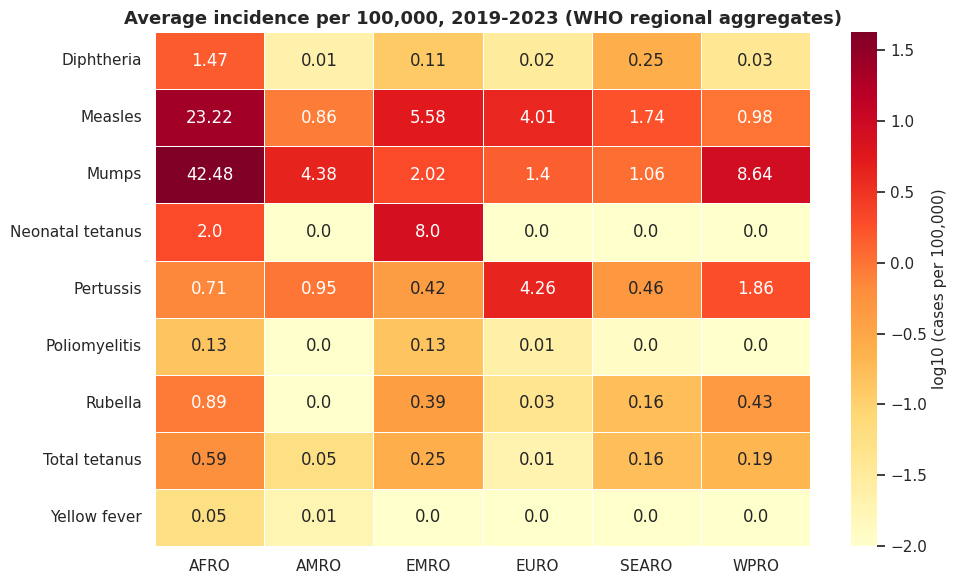

In [45]:
# Chart - 21 : Disease burden by WHO region (heatmap)
r21 = (fact_disease_burden_group.query("group_type == 'WHO_REGIONS' and year >= @LATEST_YEAR - 4")
       .merge(dim_group[["group_type", "group_code", "who_region"]], on=["group_type", "group_code"]))
t21 = (r21.pivot_table(index="disease_code", columns="who_region", values="incidence_per_100k", aggfunc="mean").reindex(columns=REGION_ORDER)
       .drop(["TYPHOID", "INVASIVE_MENING", "CRS", "JAPENC"], errors="ignore"))        # excluded: very short / patchy reporting history
t21.index = t21.index.map(dim_disease.set_index("disease_code").disease_name)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(np.log10(t21 + 0.01), annot=t21.round(2), fmt="", cmap="YlOrRd", linewidths=.5, cbar_kws={"label": "log10 (cases per 100,000)"}, ax=ax)
ax.set(title=f"Average incidence per 100,000, {LATEST_YEAR - 4}-{LATEST_YEAR} (WHO regional aggregates)", xlabel="", ylabel="")
plt.tight_layout(); plt.show()
top21 = t21.idxmax(axis=1)
c21_mea, c21_mea_v = top21["Measles"], t21.loc["Measles"].max()
c21_mumps, c21_pert, c21_nt = top21["Mumps"], top21["Pertussis"], top21["Neonatal tetanus"]
c21_amr_low = int((t21.idxmin(axis=1) == "AMRO").sum()); c21_nd = len(t21)
c21_nt_v, c21_dip, c21_dip_v = t21.loc["Neonatal tetanus"].max(), top21["Diphtheria"], t21.loc["Diphtheria"].max()

##### 1. Why did you pick the specific chart?

A region x disease heatmap answers 'are some diseases more prevalent in specific areas?' in one view. WHO regional aggregates (population-weighted) are used instead of averaging small countries, and colours are log-scaled so both rare and frequent diseases are readable. All rates are per 100,000 of each disease's own base population (see Wrangling).

##### 2. What is/are the insight(s) found from the chart?

Diseases are strongly regional. **Measles is highest in AFRO (23.2 per 100,000)**, mumps in AFRO, pertussis in EURO, **neonatal tetanus in EMRO (8.00 per 100,000 live births base)** and diphtheria in AFRO (1.47). The Americas have the lowest incidence for 5 of the 9 diseases shown, consistent with their high coverage and elimination programmes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** knowing the geography lets programmes pre-position vaccines and surveillance (e.g. tetanus protection for mothers in the highest-burden region, diphtheria antitoxin where it circulates). **Negative:** regional averages hide country hot spots, and some rates reflect better surveillance rather than more disease - so high-income regions with excellent reporting can look worse than they are.

#### Chart - 22 : Low coverage despite the vaccine being in the national programme

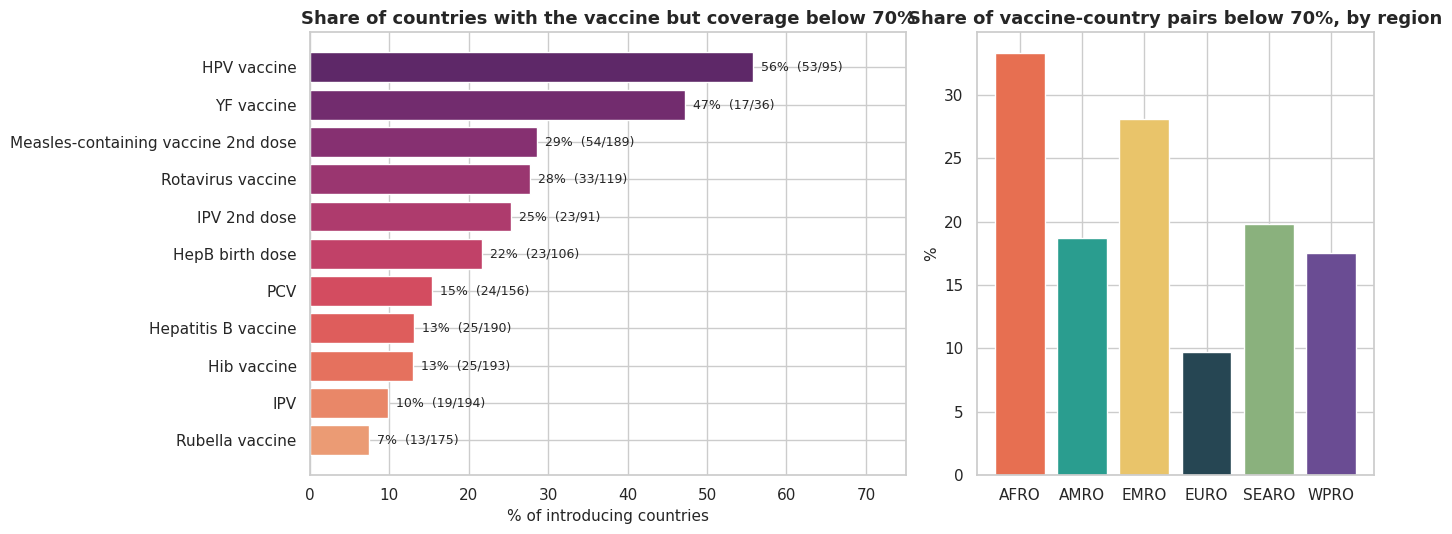

In [46]:
# Chart - 22 : Low coverage despite the vaccine being in the national programme
f22 = _intro[(_intro.year == LATEST_YEAR) & (_intro.is_nationwide == 1) & _intro.linked_antigen_code.notna()]
d22 = f22.merge(cov_best[cov_best.year == LATEST_YEAR][["country_code", "antigen_code", "coverage_pct"]],
                left_on=["country_code", "linked_antigen_code"], right_on=["country_code", "antigen_code"])
d22 = d22.merge(dim_country[["country_code", "who_region"]].rename(columns={"who_region": "region"}), on="country_code")
d22["low"] = d22.coverage_pct < 70
bv = d22.groupby("vaccine_description").agg(n=("low", "size"), n_low=("low", "sum"))
bv = bv[bv.n >= 30].assign(pct_low=lambda d: d.n_low / d.n * 100).sort_values("pct_low")
fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
axs[0].barh(bv.index.str.replace(r" \(.*?\)", "", regex=True), bv.pct_low, color=sns.color_palette("flare", len(bv)))
for i, (p, n_, nl) in enumerate(zip(bv.pct_low, bv.n, bv.n_low)):
    axs[0].text(p + 1, i, f"{p:.0f}%  ({nl}/{n_})", va="center", fontsize=9)
axs[0].set(title="Share of countries with the vaccine but coverage below 70%", xlabel="% of introducing countries", xlim=(0, 75))
rr = d22.groupby("region").low.mean().reindex(REGION_ORDER) * 100
axs[1].bar(rr.index, rr.values, color=[REGION_COLORS[r] for r in rr.index])
axs[1].set(title="Share of vaccine-country pairs below 70%, by region", ylabel="%")
plt.tight_layout(); plt.show()
c22_total, c22_low = len(d22), int(d22.low.sum())
c22_top_v, c22_top_p = bv.index[-1].split(" (")[0], bv.pct_low.iloc[-1]
c22_afro, c22_euro = rr["AFRO"], rr["EURO"]
c22_mcv2 = bv.loc["Measles-containing vaccine 2nd dose", "pct_low"]; c22_rota = bv.loc["Rotavirus vaccine", "pct_low"]
c22_afro_share = d22[d22.low].region.value_counts(normalize=True)["AFRO"]

##### 1. Why did you pick the specific chart?

This chart joins two tables (introduction status and coverage) to answer 'which countries have the vaccine available but still low coverage?' - a mismatch between policy and delivery. The bar chart ranks vaccines; the regional bars show where the problem is concentrated.

##### 2. What is/are the insight(s) found from the chart?

Of 1,574 vaccine-country pairs where the vaccine is nationally introduced, **329 (21%) have coverage below 70%**. The largest share is for HPV (56%); measles second dose (29%) and rotavirus (28%) are also high. By region, **Africa has 33% of its pairs below 70% versus 10% in Europe** and accounts for 39% of all such pairs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it separates 'not introduced' (a policy/funding problem) from 'introduced but poorly delivered' (an operational problem) so each gets the right remedy: supply-chain, staffing, demand generation and stock-out monitoring. **Negative:** an introduction that exists only on paper gives false confidence in reported programme reach; if donors count introductions rather than coverage they overstate progress.

#### Chart - 23 : Vaccination schedule design vs coverage

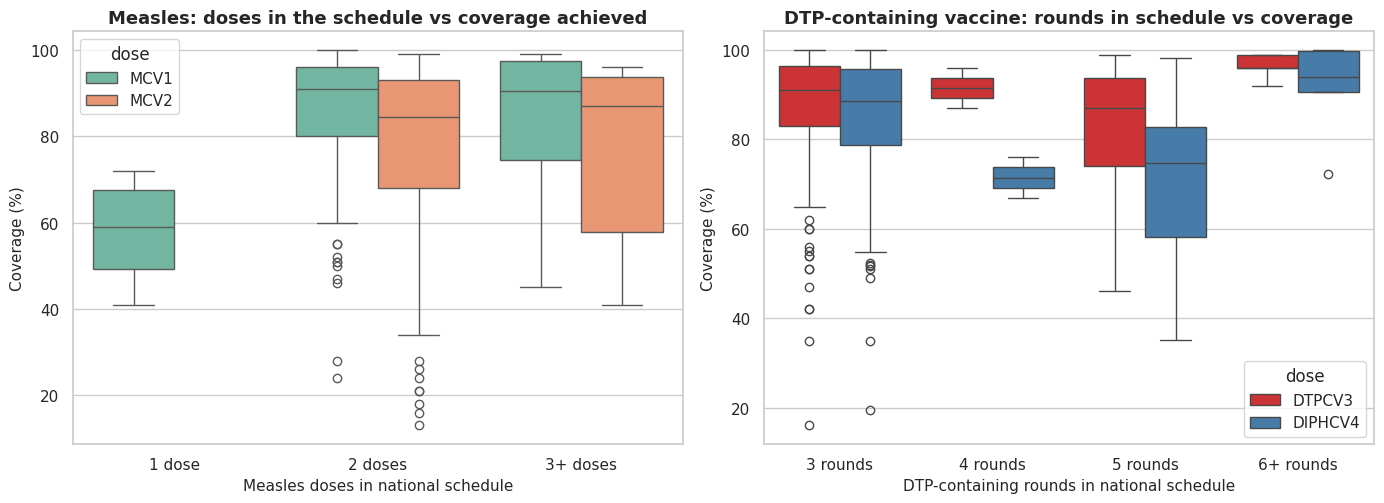

In [47]:
# Chart - 23 : Vaccination schedule design vs coverage
s23 = fact_vaccine_schedule.query("year == @LATEST_YEAR and target_pop_code == 'ROUTINE'").merge(dim_schedule_vaccine, on="vaccine_code")
r_mcv = s23[s23.vaccine_code.isin(["MEASLES", "MR", "MMR", "MMRV", "MM"])].groupby("country_code").schedule_round.max().rename("rounds")
r_dtp = s23[s23.vaccine_family == "DTP-containing"].groupby("country_code").schedule_round.max().rename("rounds")
c23 = latest(cov_best).pivot_table(index="country_code", columns="antigen_code", values="coverage_pct")

a23 = pd.concat([r_mcv.clip(upper=3).map({1: "1 dose", 2: "2 doses", 3: "3+ doses"}), c23[["MCV1", "MCV2"]]], axis=1, join="inner").melt(id_vars="rounds", var_name="dose", value_name="coverage").dropna()
b23 = pd.concat([r_dtp.clip(upper=6).map({3: "3 rounds", 4: "4 rounds", 5: "5 rounds", 6: "6+ rounds"}), c23[["DTPCV3", "DIPHCV4"]]], axis=1, join="inner").melt(id_vars="rounds", var_name="dose", value_name="coverage").dropna()
fig, axs = plt.subplots(1, 2, figsize=(14, 5.2))
sns.boxplot(data=a23, x="rounds", y="coverage", hue="dose", order=["1 dose", "2 doses", "3+ doses"], palette="Set2", ax=axs[0])
axs[0].set(title="Measles: doses in the schedule vs coverage achieved", xlabel="Measles doses in national schedule", ylabel="Coverage (%)")
sns.boxplot(data=b23, x="rounds", y="coverage", hue="dose", order=["3 rounds", "4 rounds", "5 rounds", "6+ rounds"], palette="Set1", ax=axs[1])
axs[1].set(title="DTP-containing vaccine: rounds in schedule vs coverage", xlabel="DTP-containing rounds in national schedule", ylabel="Coverage (%)")
plt.tight_layout(); plt.show()
g = lambda df, r, d: df[(df.rounds == r) & (df.dose == d)].coverage
c23_n_mcv = a23.drop_duplicates().groupby("rounds").size()
m1_one, m1_two, m2_two = g(a23, "1 dose", "MCV1").mean(), g(a23, "2 doses", "MCV1").mean(), g(a23, "2 doses", "MCV2").mean()
n_one, n_two = int(len(g(a23, "1 dose", "MCV1"))), int(len(g(a23, "2 doses", "MCV1")))
d3_3, d3_5, b4_5 = g(b23, "3 rounds", "DTPCV3").mean(), g(b23, "5 rounds", "DTPCV3").mean(), g(b23, "5 rounds", "DIPHCV4").mean()
b4_3 = g(b23, "3 rounds", "DIPHCV4").mean()
n_dtp3, n_dtp5 = int(len(g(b23, "3 rounds", "DTPCV3"))), int(len(g(b23, "5 rounds", "DTPCV3")))

##### 1. Why did you pick the specific chart?

Box plots by schedule design compare the *distribution* of coverage for countries that schedule different numbers of doses. Splitting by dose (first vs second, primary vs booster) shows how much coverage falls at each additional visit.

##### 2. What is/are the insight(s) found from the chart?

Nearly every country now schedules two measles doses (192 countries) with MCV1 averaging 86% and **MCV2 only 78%**, while the 4 countries with a single-dose schedule reach just 58% for MCV1. For DTP, countries with 5 scheduled rounds (26) have DTP3 near 84% but the first booster near **70%**, versus 86% for DTP3 in 3-round countries (171). Each added dose lowers the share of children reached.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** two-dose schedules are nearly universal, so the policy framework for measles elimination is in place. **Negative:** adding a dose to the schedule does not by itself add protection - without reminder systems, later doses reach 9 (measles) to 14 (DTP boosters) points fewer children than the first doses. Countries planning new boosters should budget for tracing and school-based delivery, not just for vaccine stock.

#### Chart - 24 : Gaps in coverage for tuberculosis (BCG) and hepatitis B vaccines

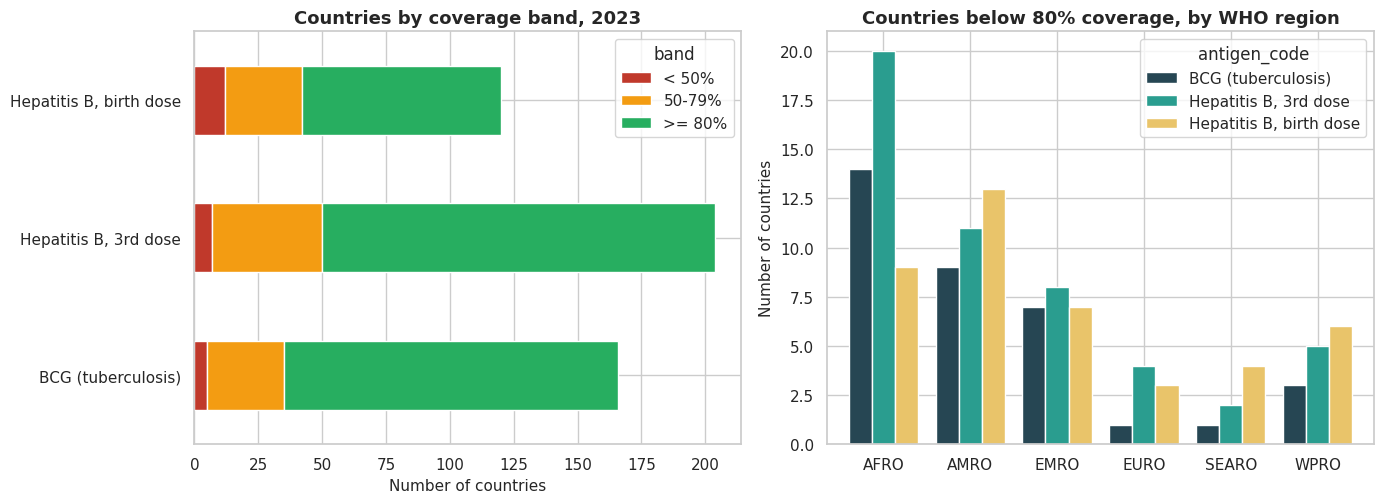

In [48]:
# Chart - 24 : Gaps in coverage for tuberculosis (BCG) and hepatitis B vaccines
A24 = {"BCG": "BCG (tuberculosis)", "HEPB3": "Hepatitis B, 3rd dose", "HEPB_BD": "Hepatitis B, birth dose"}
d24 = latest(cov_best)[latest(cov_best).antigen_code.isin(A24)].copy()
d24["band"] = pd.cut(d24.coverage_pct, [0, 50, 80, 101], labels=["< 50%", "50-79%", ">= 80%"], right=False)
ct24 = d24.groupby(["antigen_code", "band"]).size().unstack(fill_value=0).rename(index=A24)
fig, axs = plt.subplots(1, 2, figsize=(14, 5.2))
ct24[["< 50%", "50-79%", ">= 80%"]].plot(kind="barh", stacked=True, color=["#c0392b", "#f39c12", "#27ae60"], ax=axs[0])
axs[0].set(title=f"Countries by coverage band, {LATEST_YEAR}", xlabel="Number of countries", ylabel="")
lowreg = d24[d24.coverage_pct < 80].groupby(["antigen_code", "who_region"]).size().unstack(fill_value=0).reindex(columns=REGION_ORDER, fill_value=0).rename(index=A24)
lowreg.T.plot(kind="bar", ax=axs[1], color=["#264653", "#2a9d8f", "#e9c46a"], width=.8)
axs[1].set(title="Countries below 80% coverage, by WHO region", xlabel="", ylabel="Number of countries"); axs[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
n24 = d24.groupby("antigen_code").size()
lt80 = d24[d24.coverage_pct < 80].groupby("antigen_code").size()
c24_bcg, c24_hb, c24_bd = lt80.get("BCG", 0), lt80.get("HEPB3", 0), lt80.get("HEPB_BD", 0)
b24 = d24.query("antigen_code == 'BCG' and coverage_pct < 60").sort_values("coverage_pct")
c24_true = ", ".join(b24[~b24.country_name.str.startswith(("United Kingdom", "New Zealand"))].country_name.str.split(" \\(").str[0].head(4))
c24_afro_bd = lowreg.loc["Hepatitis B, birth dose", "AFRO"]; c24_bd_n = int(n24["HEPB_BD"])
c24_hb_low = d24.query("antigen_code == 'HEPB3' and coverage_pct < 50").shape[0]

##### 1. Why did you pick the specific chart?

The brief names TB and hepatitis B as high-priority diseases, so a stacked bar shows how many countries fall in each coverage band and a grouped bar shows where the below-80% countries are located.

##### 2. What is/are the insight(s) found from the chart?

In 2023, **35 of 166 countries are below 80% for BCG, 50 of 204 for hepatitis B dose 3, and 42 of 120 for the hepatitis B birth dose** (9 of these in Africa). The hepatitis B birth dose - the key step to prevent mother-to-child transmission - is the weakest. The lowest BCG values include the United Kingdom and New Zealand, which use a targeted (not universal) BCG policy - a policy choice rather than a gap; true gaps include Somalia, Papua New Guinea, Sudan, Yemen.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the list of countries below 80% is a ready prioritisation list for TB and hepatitis B programmes. **Negative:** low birth-dose coverage is commonly associated with births outside health facilities and no vaccine storage at the delivery point; without action, chronic hepatitis B infections acquired at birth will keep causing liver disease for decades. (Note: BCG coverage below 80% is not a gap in countries that intentionally target only risk groups.)

### **Scenario-based analysis**

The brief lists nine decision scenarios. Charts 25-30 answer the ones the data can support; Section 5 maps every scenario and every question to its evidence, and states clearly which ones the data cannot answer.

#### Chart - 25 : Scenario 1 - Where should a health agency send resources? Estimated unvaccinated infants by country

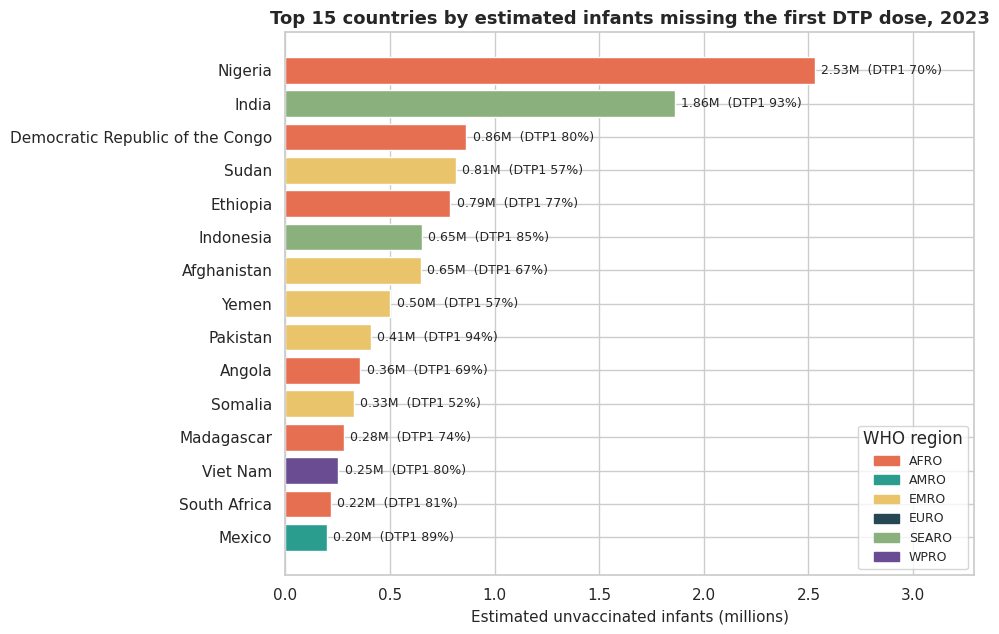

,countries,infants_targeted_m,est_unvaccinated_m,mean_DTP1,share_of_total_%
who_region,,,,,
AFRO,47,41.50,7.14,86.47,47.0
AMRO,40,8.76,1.03,91.26,7.0
EMRO,21,18.89,3.08,85.57,20.0
EURO,33,4.37,0.13,95.03,1.0
SEARO,11,36.53,2.95,88.73,19.0
WPRO,28,15.75,0.89,94.34,6.0


In [49]:
# Chart - 25 : Scenario 1 - Where should a health agency send resources? Estimated unvaccinated infants by country
tg25 = (fact_coverage[(fact_coverage.antigen_code == "DTPCV1") & (fact_coverage.year == LATEST_YEAR) & fact_coverage.target_number.notna()]
        .sort_values("category_code").drop_duplicates("country_code")[["country_code", "target_number"]])
d25 = (cov_best.query("antigen_code == 'DTPCV1' and year == @LATEST_YEAR")[["country_code", "country_name", "who_region", "coverage_pct"]]
       .merge(tg25, on="country_code"))
d25["zero_dose_est"] = d25.target_number * (1 - d25.coverage_pct / 100)        # infants who did not receive even the first DTP dose
top15 = d25.nlargest(15, "zero_dose_est").iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(top15.country_name.str.split(" \\(").str[0], top15.zero_dose_est / 1e6, color=top15.who_region.map(REGION_COLORS))
for b, v, c_ in zip(bars, top15.zero_dose_est / 1e6, top15.coverage_pct):
    ax.text(v + .03, b.get_y() + b.get_height() / 2, f"{v:.2f}M  (DTP1 {c_:.0f}%)", va="center", fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=REGION_COLORS[r], label=r) for r in REGION_ORDER], title="WHO region", loc="lower right", fontsize=9)
ax.set(title=f"Top 15 countries by estimated infants missing the first DTP dose, {LATEST_YEAR}", xlabel="Estimated unvaccinated infants (millions)", xlim=(0, top15.zero_dose_est.max() / 1e6 * 1.3))
plt.tight_layout(); plt.show()
zd_total_m = d25.zero_dose_est.sum() / 1e6
zd_top10_share = d25.nlargest(10, "zero_dose_est").zero_dose_est.sum() / d25.zero_dose_est.sum()
c25_n = len(d25); c25_top3 = ", ".join(top15.country_name.str.split(" \\(").str[0].iloc[::-1].head(3))
c25_top1_v = top15.zero_dose_est.iloc[-1] / 1e6
c25_top1_share = top15.zero_dose_est.iloc[-1] / d25.zero_dose_est.sum()
c25_afro = d25[d25.who_region == "AFRO"].zero_dose_est.sum() / d25.zero_dose_est.sum()
_ind = d25[d25.country_code == "IND"].iloc[0]; c25_ind_m, c25_ind_cov = _ind.zero_dose_est / 1e6, _ind.coverage_pct
reg25 = d25.groupby("who_region").agg(countries=("country_code", "size"), infants_targeted_m=("target_number", lambda s: s.sum() / 1e6),
                                        est_unvaccinated_m=("zero_dose_est", lambda s: s.sum() / 1e6), mean_DTP1=("coverage_pct", "mean")).reindex(REGION_ORDER).round(2)
reg25["share_of_total_%"] = (reg25.est_unvaccinated_m / reg25.est_unvaccinated_m.sum() * 100).round(0)
reg25

##### 1. Why did you pick the specific chart?

For *allocation* the number of children missed matters more than the percentage. Multiplying (1 - first-dose coverage) by the target cohort converts coverage into **children**, and a ranked bar chart gives a ready priority list; the regional table below the chart summarises where they are.

##### 2. What is/are the insight(s) found from the chart?

About **15.2 million infants** in 180 countries are estimated to have missed even their first DTP dose in 2023 - in line with the roughly 14-15 million zero-dose children reported by WHO/UNICEF, which is a useful sanity check. **The top 10 countries hold 62% of them**; the three largest are Nigeria, India, Democratic Republic of the Congo, and the single largest holds 17% (2.5 million). The African Region accounts for 47% of the total.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this is directly actionable - concentrating catch-up campaigns, outreach and funding in about ten countries would reach most unvaccinated infants. **Negative:** percentage-based rankings would send resources to small countries with low coverage but few children, while a large country with 'good' coverage such as India (93% DTP1) would be ignored despite about 1.9 million unvaccinated infants. Note: cohort sizes are the administrative targets reported by each country and may be over- or under-estimated.

#### Chart - 26 : Scenario 6 - Progress toward the 95% measles coverage target by 2030

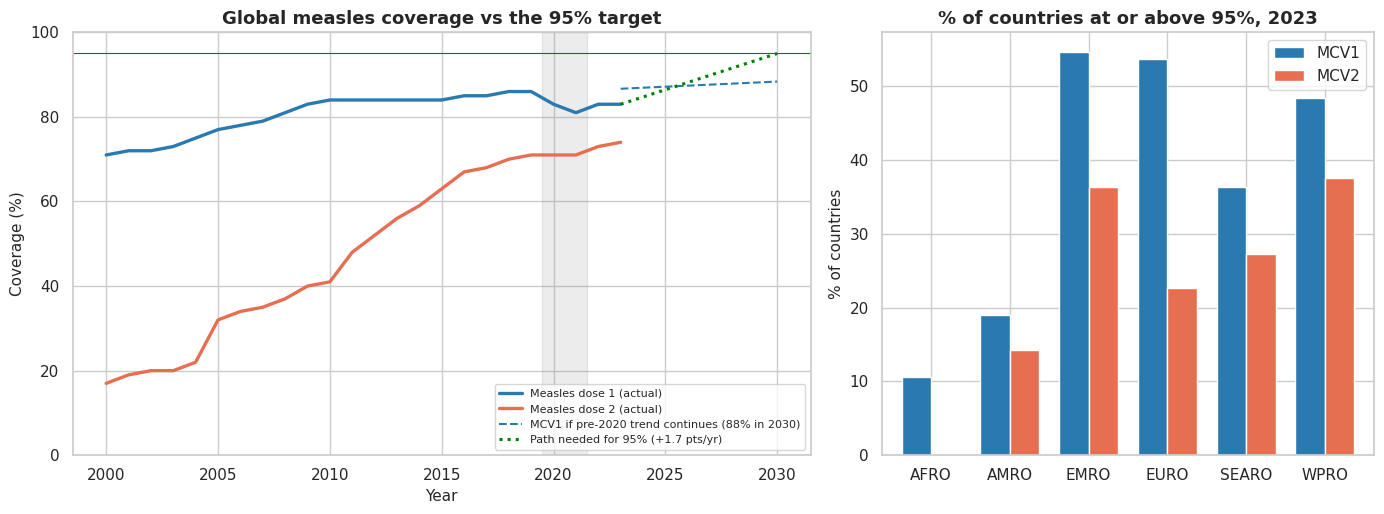

In [50]:
# Chart - 26 : Scenario 6 - Progress toward the 95% measles coverage target by 2030
m1, m2 = gl("MCV1").loc[2000:], gl("MCV2").loc[2000:]
fit = m1.loc[2010:2019]
slope26, icpt26, *_ = stats.linregress(fit.index, fit.values)                 # pre-pandemic trend (2010-2019)
YEAR_T = 2030
mcv1_trend_gain = slope26
mcv1_needed_gain = (95 - m1.loc[LATEST_YEAR]) / (YEAR_T - LATEST_YEAR)
mcv2_needed_gain = (95 - m2.loc[LATEST_YEAR]) / (YEAR_T - LATEST_YEAR)
mcv2_recent_gain = (m2.loc[LATEST_YEAR] - m2.loc[2015]) / (LATEST_YEAR - 2015)
mcv2_2010s = stats.linregress(m2.loc[2010:2019].index, m2.loc[2010:2019].values).slope
proj26 = icpt26 + slope26 * YEAR_T

fig, axs = plt.subplots(1, 2, figsize=(14, 5.3), gridspec_kw={"width_ratios": [1.5, 1]})
axs[0].plot(m1.index, m1.values, lw=2.4, label="Measles dose 1 (actual)", color="#2a7ab0")
axs[0].plot(m2.index, m2.values, lw=2.4, label="Measles dose 2 (actual)", color="#e76f51")
xs = np.arange(LATEST_YEAR, YEAR_T + 1)
axs[0].plot(xs, icpt26 + slope26 * xs, ls="--", color="#2a7ab0", label=f"MCV1 if pre-2020 trend continues ({proj26:.0f}% in {YEAR_T})")
axs[0].plot([LATEST_YEAR, YEAR_T], [m1.loc[LATEST_YEAR], 95], ls=":", color="green", lw=2.2, label=f"Path needed for 95% (+{mcv1_needed_gain:.1f} pts/yr)")
axs[0].axhline(95, color="green", lw=.8); axs[0].axvspan(2019.5, 2021.5, color="grey", alpha=.15)
axs[0].set(title="Global measles coverage vs the 95% target", xlabel="Year", ylabel="Coverage (%)", ylim=(0, 100)); axs[0].legend(fontsize=8, loc="lower right")

ct = cov_best[cov_best.year == LATEST_YEAR]
share95 = ct[ct.antigen_code.isin(["MCV1", "MCV2"])].assign(ok=lambda d: d.coverage_pct >= 95).pivot_table(index="who_region", columns="antigen_code", values="ok", aggfunc="mean").reindex(REGION_ORDER) * 100
share95.plot(kind="bar", ax=axs[1], color=["#2a7ab0", "#e76f51"], width=.75)
axs[1].set(title=f"% of countries at or above 95%, {LATEST_YEAR}", xlabel="", ylabel="% of countries"); axs[1].tick_params(axis="x", rotation=0); axs[1].legend(["MCV1", "MCV2"])
plt.tight_layout(); plt.show()
n95_1 = int((ct[ct.antigen_code == "MCV1"].coverage_pct >= 95).sum()); N1 = int((ct.antigen_code == "MCV1").sum())
n95_2 = int((ct[ct.antigen_code == "MCV2"].coverage_pct >= 95).sum()); N2 = int((ct.antigen_code == "MCV2").sum())
c26_afro95 = share95.loc["AFRO", "MCV1"]

##### 1. Why did you pick the specific chart?

A line chart of the actual series with (a) the pre-pandemic trend continued and (b) the straight line needed to hit 95% makes the *gap between trajectory and target* explicit. The bar chart shows how far each region is from the target at country level.

##### 2. What is/are the insight(s) found from the chart?

Global MCV1 is at **83%** and MCV2 at **74%**. Reaching 95% by 2030 needs **+1.7 points a year for MCV1 and +3.0 for MCV2**. Before the pandemic MCV1 grew only +0.24 per year (which would give about 88% in 2030), while MCV2 has grown about +1.4 per year since 2015. Only **73 of 207 countries reach 95% for MCV1 and 41 of 203 for MCV2**; in Africa just 11% of countries do for MCV1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** MCV2 shows the world *can* grow fast (about +3.3 points a year in the 2010s), so a second-dose push is the most achievable route. **Negative:** on the pre-pandemic MCV1 trend the 95% target will be missed by about 7 points; without a step-change (catch-up campaigns, outreach in the 134 countries below target) measles outbreaks will continue and elimination goals slip.

#### Chart - 27 : Scenario 3 - Estimating next year's measles vaccine demand

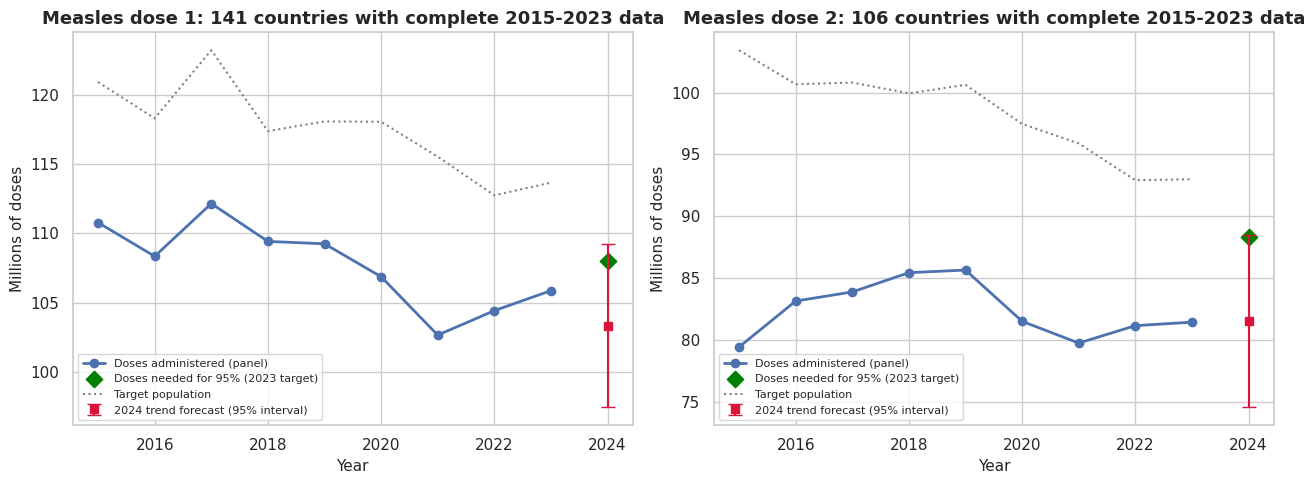

In [51]:
# Chart - 27 : Scenario 3 - Estimating next year's measles vaccine demand
def panel_series(antigen, y0=2015):
    """Doses and target population for countries that reported administrative data in every year since y0 (balanced panel, so the trend is not distorted by who reports)."""
    a = fact_coverage[(fact_coverage.category_code == "ADMIN") & (fact_coverage.antigen_code == antigen) & fact_coverage.doses.notna()
                      & fact_coverage.target_number.notna() & (fact_coverage.year >= y0)]
    pv = a.pivot_table(index="country_code", columns="year", values=["doses", "target_number"])
    ok = pv["doses"].dropna().index.intersection(pv["target_number"].dropna().index)
    return pv["doses"].loc[ok].sum(), pv["target_number"].loc[ok].sum(), len(ok)


def ols_forecast(s, year):
    """Linear trend forecast with a 95% prediction interval."""
    x, y = np.array(s.index, float), s.values.astype(float)
    r = stats.linregress(x, y); n = len(x)
    se = np.sqrt(np.sum((y - (r.intercept + r.slope * x)) ** 2) / (n - 2))
    pi = stats.t.ppf(.975, n - 2) * se * np.sqrt(1 + 1 / n + (year - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
    return r.intercept + r.slope * year, pi


FY = LATEST_YEAR + 1
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
res27 = {}
for ax, (a, lab) in zip(axs, {"MCV1": "Measles dose 1", "MCV2": "Measles dose 2"}.items()):
    doses, target, n_c = panel_series(a)
    pred, pi = ols_forecast(doses, FY)
    need = target.loc[LATEST_YEAR] * .95
    ax.plot(doses.index, doses / 1e6, marker="o", lw=2, label="Doses administered (panel)")
    ax.errorbar([FY], [pred / 1e6], yerr=[pi / 1e6], fmt="s", color="crimson", capsize=5, label=f"{FY} trend forecast (95% interval)")
    ax.scatter([FY], [need / 1e6], marker="D", s=70, color="green", label=f"Doses needed for 95% ({LATEST_YEAR} target)")
    ax.plot(target.index, target / 1e6, ls=":", color="grey", label="Target population")
    ax.set(title=f"{lab}: {n_c} countries with complete 2015-{LATEST_YEAR} data", xlabel="Year", ylabel="Millions of doses")
    ax.legend(fontsize=8, loc="lower left")
    res27[a] = dict(pred=pred, pi=pi, need=need, last=doses.loc[LATEST_YEAR], peak=doses.max(), peak_year=int(doses.idxmax()), n=n_c, target=target.loc[LATEST_YEAR])
plt.tight_layout(); plt.show()
f1, f2 = res27["MCV1"], res27["MCV2"]
tot_pred = (f1["pred"] + f2["pred"]) / 1e6; tot_need = (f1["need"] + f2["need"]) / 1e6; tot_last = (f1["last"] + f2["last"]) / 1e6

##### 1. Why did you pick the specific chart?

Demand planning needs a *forecast with uncertainty* and a comparison with the *need*. Using only countries that report every year keeps the trend from being distorted by reporting changes, and two panels handle the two doses separately because they follow different trends.

##### 2. What is/are the insight(s) found from the chart?

In the balanced panels (MCV1: 141 countries, MCV2: 106) administered doses peaked at 112.1 M (MCV1, 2017) and 85.6 M (MCV2, 2019) and have fallen since. A linear trend gives about **103 M (+/- 6 M) MCV1 and 82 M (+/- 7 M) MCV2 doses in 2024** - i.e. 185 M combined vs 187 M in 2023. Vaccinating 95% of the same target populations would need about **196 M doses**, so demand for planning purposes should follow the *need* rather than the recent decline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a manufacturer or supply agency gets a defensible planning range and a clear signal that supply should be sized for recovery (catch-up campaigns), not for the declining trend. **Negative:** if procurement simply follows the falling trend the supply chain will be short precisely when countries scale up catch-up campaigns. The panel covers only reporting countries (it is not the global total), and a 9-point linear model ignores campaigns and outbreaks - use it as an order-of-magnitude guide.

#### Chart - 28 : Scenario 5 - Polio incidence by level of polio vaccine coverage

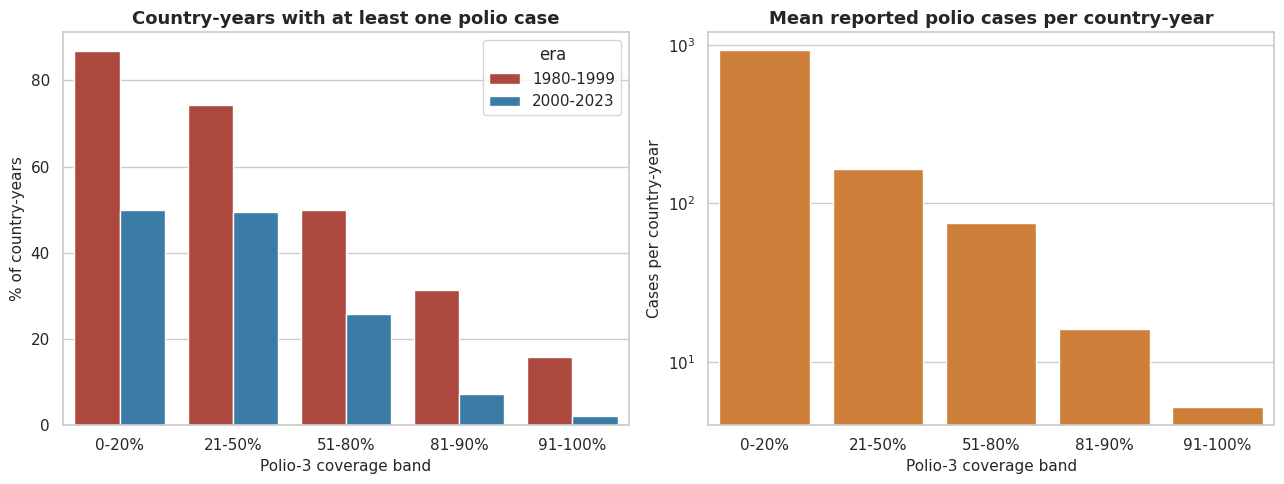

In [52]:
# Chart - 28 : Scenario 5 - Polio incidence by level of polio vaccine coverage
p28 = pairs.query("antigen_code == 'POL3' and disease_code == 'POLIO'").dropna(subset=["cases"]).copy()
p28["band"] = pd.cut(p28.coverage_pct, [-1, 20, 50, 80, 90, 100], labels=["0-20%", "21-50%", "51-80%", "81-90%", "91-100%"])
p28["era"] = np.where(p28.year < 2000, "1980-1999", f"2000-{LATEST_YEAR}")
t28 = p28.groupby(["era", "band"]).agg(country_years=("cases", "size"), pct_with_cases=("cases", lambda s: (s > 0).mean() * 100),
                                        mean_cases=("cases", "mean"), cases=("cases", "sum")).reset_index()
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=t28, x="band", y="pct_with_cases", hue="era", palette=["#c0392b", "#2980b9"], ax=axs[0])
axs[0].set(title="Country-years with at least one polio case", xlabel="Polio-3 coverage band", ylabel="% of country-years")
sns.barplot(data=p28, x="band", y="cases", errorbar=None, color="#e67e22", ax=axs[1])
axs[1].set(title="Mean reported polio cases per country-year", xlabel="Polio-3 coverage band", ylabel="Cases per country-year"); axs[1].set_yscale("log")
plt.tight_layout(); plt.show()
q28 = p28.groupby("band").agg(n=("cases", "size"), pct_with_cases=("cases", lambda s: (s > 0).mean() * 100), mean_cases=("cases", "mean"), cases=("cases", "sum"))
c28_low_n, c28_low_pct, c28_low_inc = q28.loc["0-20%", "n"], q28.loc["0-20%", "pct_with_cases"], q28.loc["0-20%", "mean_cases"]
c28_hi_n, c28_hi_pct, c28_hi_inc = q28.loc["91-100%", "n"], q28.loc["91-100%", "pct_with_cases"], q28.loc["91-100%", "mean_cases"]
c28_share_low = q28.loc[["0-20%", "21-50%"], "cases"].sum() / q28.cases.sum()
c28_modern = t28[(t28.era != "1980-1999") & (t28.band == "0-20%")].country_years.sum()

##### 1. Why did you pick the specific chart?

The scenario compares polio incidence in populations with **no or very low vaccine coverage** with well-vaccinated ones. Coverage bands on the x-axis with (a) the probability of any case and (b) the mean number of cases answer both 'how likely?' and 'how much?' (case counts are used because polio incidence rates are missing for many early years). Splitting by era checks that the result is not just the 1980s.

##### 2. What is/are the insight(s) found from the chart?

In the 247 country-years with polio-3 coverage of 20% or less, **86% reported polio cases** with an average of 925 cases per country-year, versus **7% and 5.1 cases** at 91-100% coverage (3,546 country-years). Country-years below 50% coverage account for 66% of all reported polio cases in this table. Very-low-coverage observations are almost all from before 2000 (only 4 since), showing how far coverage has improved.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it quantifies the protection - in essentially unvaccinated populations polio was the norm, while at high coverage most country-years report none. **Negative:** the middle bands do not fall smoothly (case counts are small and outbreaks cluster in specific countries), and the design is *ecological*: country-level coverage cannot say whether the individual cases were vaccinated. Also, reporting of paralytic polio depends on surveillance quality, so very low reported polio in low-coverage places could be under-detection.

#### Chart - 29 : Scenario 4 - Readiness for an influenza outbreak: programmes and coverage by group

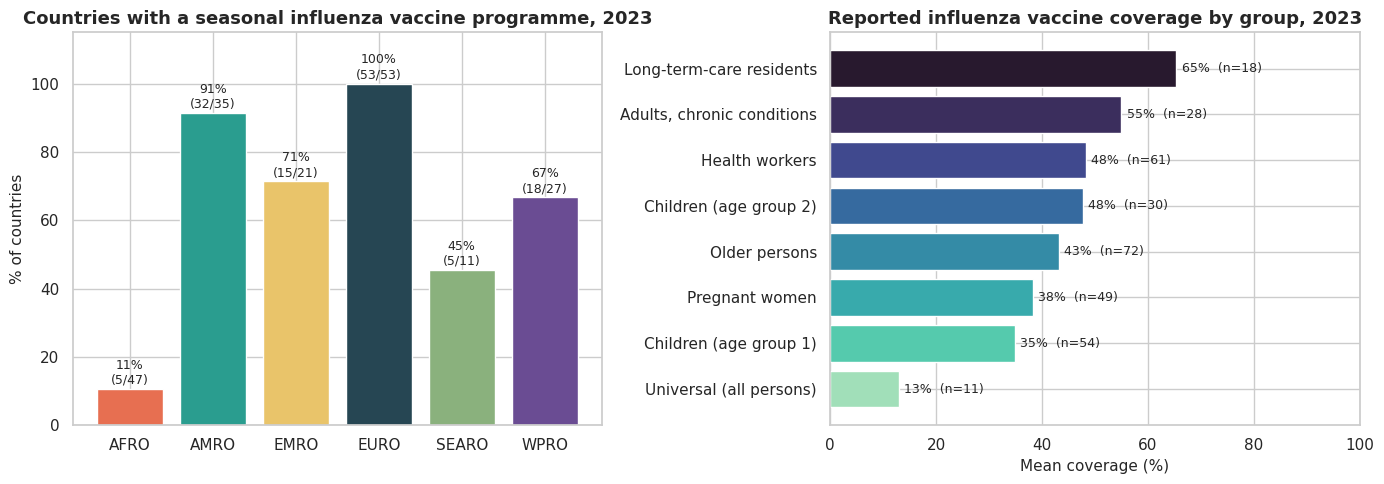

In [53]:
# Chart - 29 : Scenario 4 - Readiness for an influenza outbreak: programmes and coverage by group
fl = (_intro[(_intro.vaccine_description == "Seasonal Influenza vaccine") & (_intro.year == LATEST_YEAR)]
      .merge(dim_country[["country_code", "who_region"]].rename(columns={"who_region": "region"}), on="country_code"))
fr = fl.groupby("region").agg(n=("is_introduced", "size"), programme=("is_introduced", "sum")).reindex(REGION_ORDER)
fr["pct"] = fr.programme / fr.n * 100
FLU = {"FLU_ELDERLY": "Older persons", "FLU_HCW": "Health workers", "FLU_PW": "Pregnant women", "FLU_CHILD1": "Children (age group 1)",
       "FLU_CHILD2": "Children (age group 2)", "FLU_CHRONIC_ADULT": "Adults, chronic conditions", "FLU_RESIDENT": "Long-term-care residents", "FLU_ALL": "Universal (all persons)"}
fx = (cov_best[(cov_best.year == LATEST_YEAR) & cov_best.antigen_code.isin(FLU)].groupby("antigen_code").coverage_pct.agg(["mean", "count"])
      .rename(index=FLU).query("count >= 10").sort_values("mean"))
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].bar(fr.index, fr.pct, color=[REGION_COLORS[r] for r in fr.index])
for i, (p, pr, n_) in enumerate(zip(fr.pct, fr.programme, fr.n)):
    axs[0].text(i, p + 1.5, f"{p:.0f}%\n({pr:.0f}/{n_})", ha="center", fontsize=9)
axs[0].set(title=f"Countries with a seasonal influenza vaccine programme, {LATEST_YEAR}", ylabel="% of countries", ylim=(0, 115))
axs[1].barh(fx.index, fx["mean"], color=sns.color_palette("mako_r", len(fx)))
for i, (m_, c_) in enumerate(zip(fx["mean"], fx["count"])):
    axs[1].text(m_ + 1, i, f"{m_:.0f}%  (n={c_})", va="center", fontsize=9)
axs[1].set(title=f"Reported influenza vaccine coverage by group, {LATEST_YEAR}", xlabel="Mean coverage (%)", xlim=(0, 100))
plt.tight_layout(); plt.show()
c29_afro, c29_searo, c29_euro, c29_amro = fr.loc["AFRO", "pct"], fr.loc["SEARO", "pct"], fr.loc["EURO", "pct"], fr.loc["AMRO", "pct"]
c29_none = int(fr.n.sum() - fr.programme.sum()); c29_tot = int(fr.n.sum())
c29_eld, c29_pw, c29_hcw = fx.loc["Older persons", "mean"], fx.loc["Pregnant women", "mean"], fx.loc["Health workers", "mean"]
c29_eld_n = int(fx.loc["Older persons", "count"])

##### 1. Why did you pick the specific chart?

The scenario needs two things: *does the country have a programme at all?* (regional bar chart) and *how well are priority groups protected?* (coverage by target group). Two panels give both. Note: the data set holds no influenza case counts, so an outbreak itself cannot be detected here - only preparedness.

##### 2. What is/are the insight(s) found from the chart?

**66 of 194 countries have no seasonal influenza vaccine programme** in 2023. A programme exists in 100% of European and 91% of American countries but only **11% of African and 45% of South-East Asian countries**. Where programmes exist, reported coverage is modest: older persons 43% (n = 72), health workers 48%, pregnant women 38%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** an agency responding to an outbreak now has a shortlist: begin ramp-up where a programme and delivery channels exist (use older persons and health workers first) and where none exists, plan emergency procurement and cold-chain. **Negative:** rapid ramp-up in the regions with no programme (mostly Africa and South-East Asia) is hardest, because there is no established target list, schedule or delivery system; and influenza vaccine reporting is sparse (only a subset of countries report coverage), so real coverage may be lower.

#### Chart - 30 : Scenario 2 - Evaluating a measles campaign launched five years ago

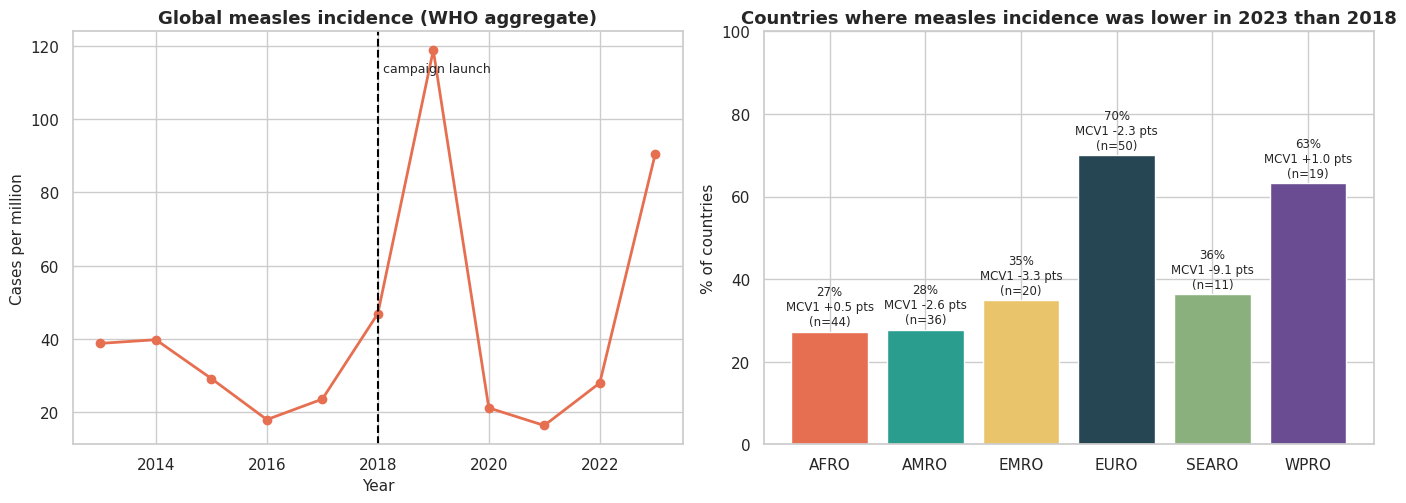

In [54]:
# Chart - 30 : Scenario 2 - Evaluating a measles campaign launched five years ago
def evaluate_campaign(disease, antigen, launch_year, horizon=5):
    """Country-level before/after comparison: incidence and coverage in the launch year vs `horizon` years later."""
    inc_ = burden[burden.disease_code == disease].pivot_table(index="country_code", columns="year", values="incidence_reported")
    cv_ = cov_best[cov_best.antigen_code == antigen].pivot_table(index="country_code", columns="year", values="coverage_pct")
    end = launch_year + horizon
    t = pd.DataFrame({"inc_before": inc_[launch_year], "inc_after": inc_[end], "cov_before": cv_[launch_year], "cov_after": cv_[end]}).dropna()
    return t.join(dim_country.set_index("country_code")[["who_region"]])


LAUNCH = LATEST_YEAR - 5
t30 = evaluate_campaign("MEASLES", "MCV1", LAUNCH)
t30["improved"] = t30.inc_after < t30.inc_before
t30["cov_change"] = t30.cov_after - t30.cov_before
gm = fact_disease_burden_group.query("group_type == 'GLOBAL' and disease_code == 'MEASLES' and year >= @LAUNCH - 5").set_index("year")

fig, axs = plt.subplots(1, 2, figsize=(14, 5.2))
axs[0].plot(gm.index, gm.incidence_reported, marker="o", color="#e76f51", lw=2)
axs[0].axvline(LAUNCH, color="black", ls="--"); axs[0].text(LAUNCH + .1, gm.incidence_reported.max() * .95, "campaign launch", fontsize=9)
axs[0].set(title="Global measles incidence (WHO aggregate)", xlabel="Year", ylabel="Cases per million")
rg = t30.groupby("who_region").agg(improved=("improved", "mean"), cov=("cov_change", "mean"), n=("improved", "size")).reindex(REGION_ORDER)
axs[1].bar(rg.index, rg.improved * 100, color=[REGION_COLORS[r] for r in rg.index])
for i, (v, c_, n_) in enumerate(zip(rg.improved * 100, rg["cov"], rg.n)):
    axs[1].text(i, v + 1.5, f"{v:.0f}%\nMCV1 {c_:+.1f} pts\n(n={n_})", ha="center", fontsize=8.5)
axs[1].set(title=f"Countries where measles incidence was lower in {LAUNCH + 5} than {LAUNCH}", ylabel="% of countries", ylim=(0, 100))
plt.tight_layout(); plt.show()
c30_n = len(t30); c30_share = t30.improved.mean(); c30_med_b, c30_med_a = t30.inc_before.median(), t30.inc_after.median()
c30_cov = t30.cov_change.mean(); c30_glob_b, c30_glob_a = gm.incidence_reported.loc[LAUNCH], gm.incidence_reported.loc[LAUNCH + 5]
c30_peak_y = int(gm.incidence_reported.idxmax()); c30_peak = gm.incidence_reported.max()

##### 1. Why did you pick the specific chart?

A campaign evaluation asks *before vs after*. The left panel shows the global time series around the launch year; the right panel asks, country by country, whether incidence fell and how much coverage changed - which avoids being fooled by a few very large outbreaks. `evaluate_campaign()` is written as a reusable function so any disease, vaccine and launch year can be assessed.

##### 2. What is/are the insight(s) found from the chart?

Comparing 2018 with 2023 across 180 countries, **44% saw lower measles incidence**, the median country's incidence fell from 4.2 to 1.9 per million and MCV1 coverage changed by -1.9 points on average. Yet **global incidence rose from 47 to 90 per million**, with a peak of 119 in 2019, because a small number of large outbreaks (and the 2020-21 disruption) dominate the total.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the typical (median) country did see lower incidence (4.2 -> 1.9 per million). **Negative:** only 44% of countries improved, MCV1 coverage slipped by 1.9 points on average, and the global figure shows the campaign was not sufficient to stop large outbreaks, and comparing two single years is noisy. A rigorous evaluation should use a control group of similar countries without the campaign (difference-in-differences), sub-national data, and outbreak-adjusted metrics. Association is not proof the campaign caused the change.

In [55]:
n_charts = 30                       # total number of charts in this notebook

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

In [56]:
# Coverage snapshot: "What percentage of the target population is covered by each vaccine?" (global WUENIC estimate, latest year)
LAB = {"BCG": "BCG (TB)", "DTPCV1": "DTP dose 1", "DTPCV3": "DTP dose 3", "POL3": "Polio dose 3", "IPV1": "IPV dose 1", "IPV2": "IPV dose 2", "HEPB3": "Hepatitis B dose 3",
       "HEPB_BD": "Hepatitis B birth dose", "HIB3": "Hib dose 3", "MCV1": "Measles dose 1", "MCV2": "Measles dose 2", "RCV1": "Rubella dose 1",
       "PCV3": "Pneumococcal dose 3", "ROTAC": "Rotavirus (last dose)", "YFV": "Yellow fever", "MENA_C": "Meningococcal A"}
cov_summary = pd.DataFrame({"global coverage %": {LAB[a]: gl(a).loc[LATEST_YEAR] for a in LAB}})
_c = latest(cov_best)
cov_summary["countries reporting"] = [int((_c.antigen_code == a).sum()) for a in LAB]
cov_summary["countries >= 90%"] = [int(((_c.antigen_code == a) & (_c.coverage_pct >= 90)).sum()) for a in LAB]
cov_summary["countries < 70%"] = [int(((_c.antigen_code == a) & (_c.coverage_pct < 70)).sum()) for a in LAB]
cov_summary.sort_values("global coverage %", ascending=False)

,global coverage %,countries reporting,countries >= 90%,countries < 70%
DTP dose 1,89.0,207,151,10
BCG (TB),87.0,166,106,14
DTP dose 3,84.0,207,116,23
Polio dose 3,83.0,208,113,29
IPV dose 1,83.0,207,129,19
Hepatitis B dose 3,83.0,204,109,25
Measles dose 1,83.0,207,113,25
Hib dose 3,77.0,205,113,25
Measles dose 2,74.0,203,78,54
Rubella dose 1,71.0,188,113,14


**Recommendations**

1. **Prioritise the zero-dose hot spots (Chart 25).** About 15.2 million infants missed their first DTP dose in 2023, and ten countries hold 62% of them. Direct catch-up campaigns, outreach and funding to these countries first; rank by *number of children*, not by percentage.
2. **Close the measles gap with a second-dose push (Charts 7, 9, 12, 26).** MCV1 83% and MCV2 74% are below the 95% target; the pre-pandemic trend would reach only about 88% by 2030. Focus on Africa (MCV2 62%), tie doses to reminder systems (drop-off 12% between doses) and plan vaccine supply on need, not on the recent decline (Chart 27).
3. **Support low-income countries (Chart 15).** The DTP3 gap to high-income OECD countries is 26 points and widened after 2019; use income-group coverage as a Gavi/donor allocation metric.
4. **Investigate high-coverage, high-incidence pockets (Chart 20).** 8 countries report MCV1 of at least 90% but measles incidence above 100 per million. Commission sub-national coverage surveys and check administrative denominators.
5. **Fix delivery where the vaccine is already in the programme (Chart 22).** 21% of introduced vaccine-country pairs are below 70% coverage; invest in stock-out monitoring, health-worker training and demand generation rather than new introductions.
6. **Accelerate new-vaccine introduction (Charts 4, 16).** HPV, rotavirus and pneumococcal vaccines are absent in dozens of countries and were introduced up to 24 years later in some regions; use pooled procurement and co-financing.
7. **Close specific gaps: hepatitis B birth dose and BCG (Chart 24)** - 42 of 120 reporting countries are below 80% for the hepatitis B birth dose.
8. **Strengthen surveillance and data quality.** 23% of case counts are missing, coverage above 100% appears in 2.4% of records, and key equity dimensions (sex, education, urban/rural, sub-national, monthly) are not collected. Sex- and district-disaggregated reporting would unlock the questions this data set cannot answer.
9. **Prepare for outbreaks (Chart 29).** 66 of 194 countries have no seasonal influenza programme; build contingency stock and a priority list (older persons, health workers, pregnant women) before an outbreak.

#### Every question and scenario in the brief - answer, evidence, and what the data cannot say

| # | Question / scenario | Answer from the data | Evidence |
|---|---|---|---|
| E1 | How do vaccination rates correlate with a decrease in incidence? | Negative and clear for measles (rho -0.31), tetanus (-0.51), diphtheria (-0.36); weak/none for rubella, JE, yellow fever | Ch 8, 9, 18 |
| E2 | Drop-off between 1st and later doses? | DTP 6.0%, measles 11.9%, IPV 10.9%, HPV 17.4% | Ch 10 |
| E3 | Vaccination rates by gender? | **Only HPV has a gender split:** girls 71% vs boys 60% (first dose, 2023). Not available for any other vaccine | Ch 11 |
| E4 | Education level vs vaccination? | **Cannot be answered - no education variable** | - |
| E5 | Urban vs rural? | **Cannot be answered - no urban/rural variable** (the schedule field `GEOAREA` only says national / sub-national) | - |
| E6 | Has booster uptake increased over time? | MCV2 rose from 41% (2010) to 74%; DTP boosters roughly flat since 2018 and lower with each extra dose | Ch 12 |
| E7 | Seasonal pattern in uptake? | **Cannot be answered - data are annual, not monthly** | - |
| E8 | Population density vs coverage? | Density is not in the data; proxy (size of target cohort) shows rho = -0.28 | Ch 13 |
| E10 | Regions with high incidence despite high coverage? | 8 countries in 2023, concentrated in EURO (4), AFRO (2), EMRO (1), WPRO (1) | Ch 20 |
| M1 | Vaccine introduction and decline in cases? | Yes: median -69% (measles MCV2) and -84% (rubella) change in the 3 years after introduction | Ch 17 |
| M2 | Trend before/after campaigns? | See event-study curves and the reusable `evaluate_campaign()` | Ch 17, 30 |
| M3 | Diseases with the most reduction? | Polio 99%, pertussis 95%, measles 91%, tetanus 89%, diphtheria 81% | Ch 14 |
| M4 | % of target population covered by each vaccine? | Table above (e.g. DTP3 84%, MCV1 83%, PCV3 65%, rotavirus 55%) | Ch 6 + table |
| M5 | Impact of schedule (boosters) on coverage? | Each extra scheduled dose gets lower coverage (5-round DTP: DTP3 84% vs booster 70%) | Ch 23 |
| M6 | Disparities in introduction timelines by WHO region? | Up to 24 years (largest: Rubella); Africa latest for 4 of 9 vaccines | Ch 16 |
| M7 | Coverage vs disease reduction per antigen? | Correlation matrix by antigen and disease | Ch 18 |
| M8 | Low coverage despite availability? | 329 of 1,574 vaccine-country pairs below 70%; Africa highest | Ch 22 |
| M9 | Coverage gaps for TB and hepatitis B? | 35 countries < 80% BCG; 50 < 80% HepB3; 42 < 80% HepB birth dose | Ch 24 |
| M10 | Diseases more prevalent in specific geographies? | Yes - strongly regional (measles in AFRO, neonatal tetanus in EMRO) | Ch 21 |
| S1 | Agency: regions with low coverage for allocation | Top-10 countries hold 62% of 15.2 M unvaccinated infants | Ch 25, 7, 15 |
| S2 | Evaluate a measles campaign launched five years ago | 44% of countries improved; global incidence still higher because of large outbreaks | Ch 30 |
| S3 | Vaccine manufacturer: demand forecast | Trend 185 M doses vs 196 M needed for 95% (measles, panel countries) | Ch 27 |
| S4 | Influenza outbreak - ramp up | 66 of 194 countries have no programme; **no influenza case data in the set** | Ch 29 |
| S5 | Polio incidence with no coverage | 86% of country-years with coverage <= 20% report polio vs 7% at 91-100% | Ch 28 |
| S6 | 95% measles by 2030 | Need +1.7 pts/yr (MCV1) vs +0.24 before 2020; 73 of 207 countries at 95% | Ch 26 |
| S7 | High-risk groups: under-fives and elderly | Under-fives: zero-dose list (Ch 25). Elderly: influenza coverage 43%; only 142 countries have risk-group schedules | Ch 5, 25, 29 |
| S8 | Socioeconomic disparities | Low-income DTP3 68% vs 94% (high-income OECD). **Within-country disparities cannot be measured** | Ch 15 |
| S9 | Variation through the year | **Cannot be answered - annual data** | - |
| S10 | Door-to-door vs centralised clinics | **Cannot be answered - no delivery-strategy variable.** Would need a comparison of districts by strategy with sub-national coverage | - |

# **Conclusion**

Global immunization has delivered enormous gains: reported cases of polio, pertussis, measles, tetanus and diphtheria are down by roughly 76-99% since 1980, coverage and disease incidence are clearly linked (measles median incidence about 65 per million below 50% coverage vs 0.4 at 95% or more), and the introduction of measles second-dose and rubella vaccines was followed by significant declines. But progress has stalled: DTP3 is 84% against a pre-pandemic peak of 86%, measles coverage is short of the 95% needed, the coverage gap between low- and high-income countries is 26 points, and 15.2 million infants missed even a first DTP dose. The problem is concentrated: ten countries hold 62% of the unvaccinated infants and the African Region trails in almost every measure.

The strongest recommendations are to target the highest-burden zero-dose countries, finish the measles second-dose and booster follow-up systems, investigate the high-coverage/high-incidence pockets, and improve data collection (sex, sub-national, monthly, delivery strategy) so that the equity and seasonality questions that this data set cannot answer can be tackled next. All cleaned tables, the SQL model and the Power BI dashboard delivered with this notebook are built from the same star schema so the numbers here can be reproduced there.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***